In [1]:
import pandas as pd
import numpy as np
#import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.tsa.stattools import ccf, grangercausalitytests
import matplotlib.cm as cm
import matplotlib.colors as mcolors
#import networkx as nx
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib.colors import TwoSlopeNorm

In [2]:
def seasonal_average(da):
    da2=da.groupby('time.year').mean('time')
    return(da2)

def stdize_ssavg(da):
    da2=(da-da.mean())/da.std()
    return da2

def extract_seasonal_data(array, seasons):
    """
    Extract data from the array for specific seasons (months).
    - A subset of the original array with only the data for the specified months.
    """
    # Make sure the 'time' dimension has a 'month' coordinate
    if 'time' in array.coords:
        # Extract month from the 'time' dimension
        months = array['time'].dt.month
        
        # Filter based on the provided seasons (months)
        seasonal_data = array.sel(time=months.isin(seasons))
        
        return seasonal_data
    else:
        raise ValueError("The input array does not contain a 'time' dimension.")
        
def compute_anomaly(array):
    anomaly=array.groupby('time.month')-array.groupby('time.month').mean('time')
    return(anomaly)

def shift_december(da):
    time_df = pd.to_datetime(da['time'])
    # Create a boolean mask for times in December
    time_series=pd.Series(time_df)
    mask = time_series.dt.month == 12
    time_series.loc[mask] = time_series.loc[mask] + pd.DateOffset(years=1)
    # Convert to numpy datetime64[D]
    time_df_upd = time_series.values.astype('datetime64[D]')
    #display(time_df_upd)
    d={'time':time_df_upd}
    da_new=da.assign_coords(d)
    return da_new

def weight_by_latitude(da):
    """Weight data array by cosine of latitude."""
    weights = np.cos(np.deg2rad(da['lat']))
    weighted_da = da * weights
    return weighted_da

def sea_mask(da):
    landsea_mask=xr.open_dataset('~/work/landseamask.nc') # mask values 0 (sea) or 1 (land)
    landsea_mask_interp = landsea_mask['mask'].interp(
    lat=da.lat,
    lon=da.lon,
    method='nearest') ##map my mask 0.5° on my 0.25° grid
    #print(landsea_mask.sel(lat=-32.25,lon=-50.25)['mask'].values)
    
    masked_da=da.where(landsea_mask_interp==1)
    return masked_da

def weight_by_latitude(da):
    """Weight data array by cosine of latitude."""
    weights = np.cos(np.deg2rad(da['lat']))
    weighted_da = da * weights
    return weighted_da


def reshape_to_2d(da):
    """Reshape (lat, lon, time) data into 2D matrix (space x time)."""
    space_dim = da['lat'].size * da['lon'].size
    reshaped = da.stack(space=('lat', 'lon')).transpose('time', 'space')
    return reshaped


def compute_covariance_matrix(reshaped_da):
    """Compute the covariance matrix of the data."""
    data = reshaped_da.values
    data = data - np.nanmean(data, axis=0)  # Centering the data
    covariance_matrix = np.cov(data.T)
    return covariance_matrix


def perform_svd(cov_matrix):
    """Perform SVD on the covariance matrix."""
    U, S, Vt = np.linalg.svd(cov_matrix)
    return U, S, Vt


def plot_first_principal_component(reshaped_da, Vt):
    """Plot the first principal component as a map."""
    first_pc = Vt[0, :] #first eigenvector with largest eigenvalue
    pc_map = reshaped_da.isel(time=0).copy() #.isel selects the i you give, make a copy of given array at i
    pc_map.values = first_pc #change the values from before to the first_pc values
    pc_map_unstacked = pc_map.unstack('space')

    plt.figure(figsize=(8, 5))
    pc_map_unstacked.plot(cmap='RdBu')
    plt.title("First Principal Component (Spatial Pattern)")
    plt.show()

    return pc_map_unstacked


def compute_zonal_mean(pc_map_unstacked):
    """Compute the zonal mean of the first principal component map."""
    zonal_mean = pc_map_unstacked.mean(dim='lon')
    return zonal_mean


def make_zonal_mean_map(zonal_mean, da):
    """Create a zonal mean map, assigning each longitude the same value."""
    zonal_map = xr.zeros_like(da.isel(time=0)) #blank map with same dimensions as da
    for lon in zonal_map['lon']:
        zonal_map.loc[{'lon': lon}] = zonal_mean #assign zonal mean value to each longitude
    return zonal_map


def regress_onto_zonal_mean_map(da, zonal_map):
    """Regress original data onto the zonal mean map (time series of coefficients)."""
#flattening data
    zonal_map_flat = zonal_map.stack(space=('lat', 'lon')).values
    data_flat = da.stack(space=('lat', 'lon')).transpose('time', 'space').values
#detrending by removing mean
    zonal_map_flat = zonal_map_flat - np.nanmean(zonal_map_flat)
    data_flat = data_flat - np.nanmean(data_flat, axis=0)

    regression_coefficients = np.dot(data_flat, zonal_map_flat) / np.dot(zonal_map_flat, zonal_map_flat)

    return regression_coefficients


def plot_regression_coefficients(time, regression_coefficients):
    """Plot regression coefficients over time."""
    plt.figure(figsize=(8, 5))
    plt.plot(time, regression_coefficients, label='Regression Coefficients')
    plt.xlabel('Time')
    plt.ylabel('Coefficient')
    plt.title('Regression Coefficients Over Time')
    plt.grid()
    plt.show()
    

In [3]:
def df_xr_prep(df):
    da=df.to_xarray()
    da=da.rename({'index':'year'})
    return da

##La Plata
#SON
era_SON_LaPlata_df=pd.read_csv('~/work/data_ready/7_with_VB.csv',index_col='Unnamed: 0')

#era_SON_LaPlata_df=era_SON_LaPlata_df.rename(index_col='year')
era_SON_LaPlata_array=era_SON_LaPlata_df.to_xarray()
era_SON_LaPlata_array=era_SON_LaPlata_array.rename({'index':'year'})

#DJF
era_DJF_LaPlata_df=pd.read_csv('~/work/data_ready/6_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_LaPlata_array=df_xr_prep(era_DJF_LaPlata_df)

##Andes
#SON
era_SON_Andes_df=pd.read_csv('~/work/data_ready/5_with_VB.csv',index_col='Unnamed: 0')
era_SON_Andes_array=df_xr_prep(era_SON_Andes_df)

#DJF
era_DJF_Andes_df=pd.read_csv('~/work/data_ready/4_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_Andes_array=df_xr_prep(era_DJF_Andes_df)
display(era_DJF_Andes_array)

<xarray.Dataset> Size: 8kB
Dimensions:        (year: 73)
Coordinates:
  * year           (year) int64 584B 1951 1952 1953 1954 ... 2022 2023 2024 1950
Data variables: (12/13)
    t_Andes        (year) float64 584B -1.791 0.5614 -0.2617 ... 0.6017 nan
    precip_Andes   (year) float64 584B 0.129 0.4549 -1.375 ... -0.2223 -1.51 nan
    ENSO           (year) float64 584B -0.6866 0.5838 0.3068 ... 1.632 nan
    IOD            (year) float64 584B 0.2555 0.6281 1.26 ... 0.9651 4.209 nan
    EDJ            (year) float64 584B 1.783 0.6677 -0.5056 ... 0.1875 nan
    EDJ_lat        (year) float64 584B -0.6985 1.359 -0.9556 ... -2.241 nan
    ...             ...
    SPV            (year) float64 584B 0.2633 -0.6312 1.451 ... 1.702 1.85 nan
    A_SAM          (year) float64 584B 0.233 -1.135 -2.197 ... 1.774 0.05365 nan
    S_SAM          (year) float64 584B 0.6038 -1.058 0.1437 ... 1.93 1.88 nan
    IOBW           (year) float64 584B -1.546 0.8591 -0.3374 ... 2.389 nan
    VB             (year) float64 584B -0.0653 -0.101 0.2247 ... 0.7241 nan
    VB_class       (year) object 584B 'Early' 'Early' 'Late' ... 'Late' 'Early'

Compute A-SAM separately for VB regime

<xarray.Dataset> Size: 33MB
Dimensions:         (valid_time: 1021, lon: 144, lat: 28, pressure_level: 2)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-01-01
  * lon             (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
  * lat             (lat) float64 224B -86.79 -80.36 -73.93 ... 80.36 86.79
  * pressure_level  (pressure_level) float64 16B 500.0 50.0
Data variables:
    z               (valid_time, pressure_level, lat, lon) float32 33MB ...
Attributes:
    CDI:                     Climate Data Interface version 2.5.0 (https://mp...
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    history:                 Thu Feb 13 16:17:09 2025: cdo remapbil,r144x28 d...
    CDO:                     Climate Data Operators version 2.5.0 (https://mp...

/tmp/ipykernel_2610792/2093332194.py:4: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  zg_ren = zg_ren.sel(pressure_level=500).z.drop('pressure_level').sel(time=slice('1950','2024'),lat=slice(-90,-20))


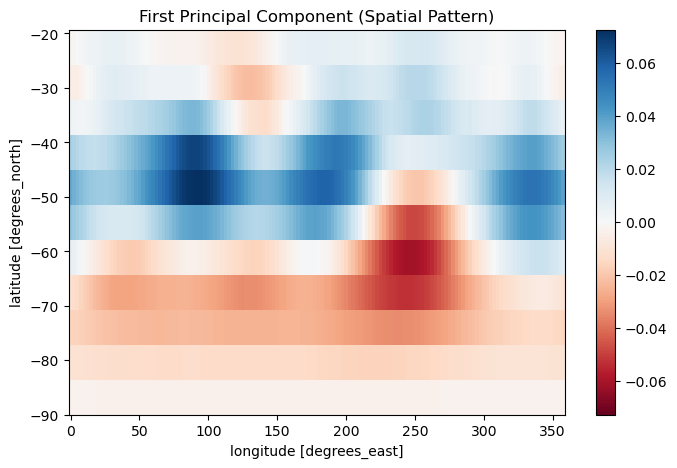

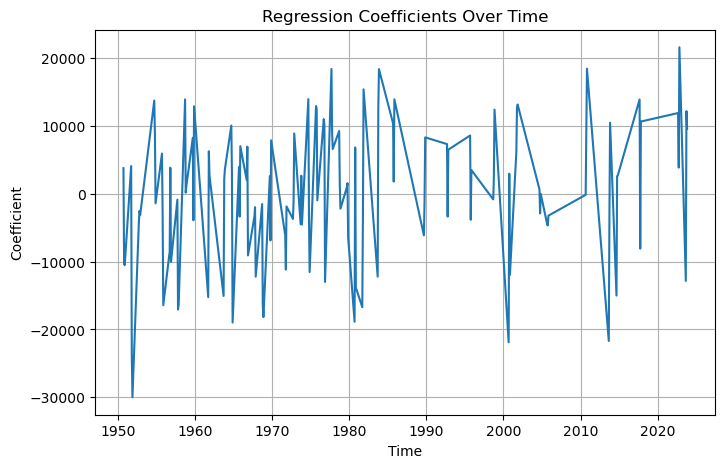

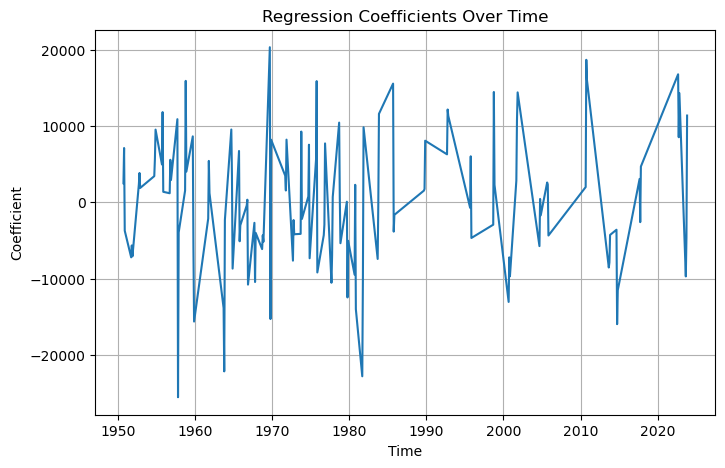

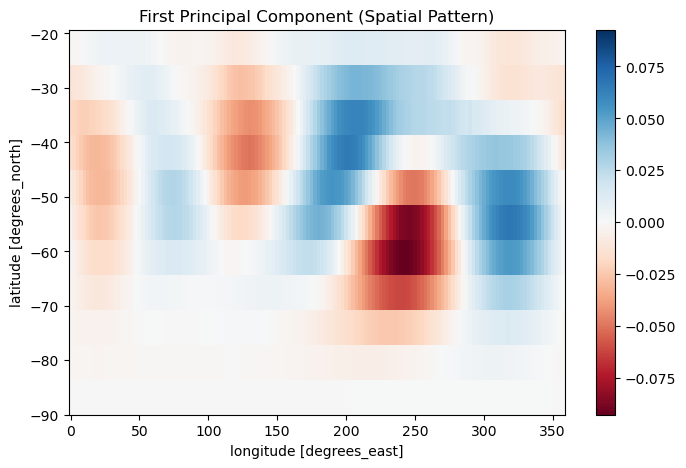

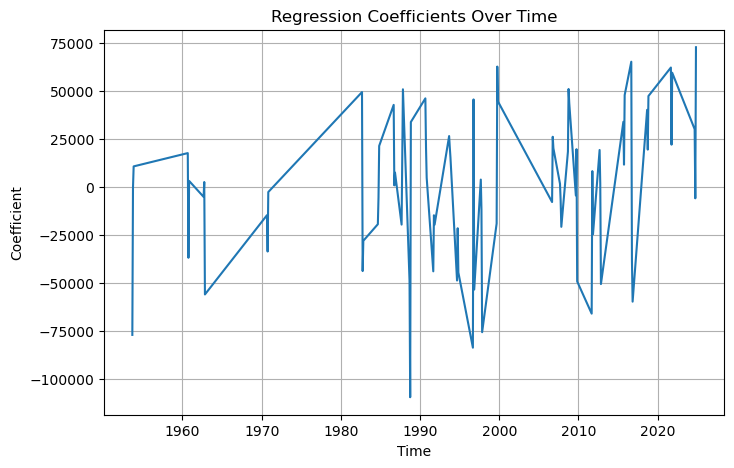

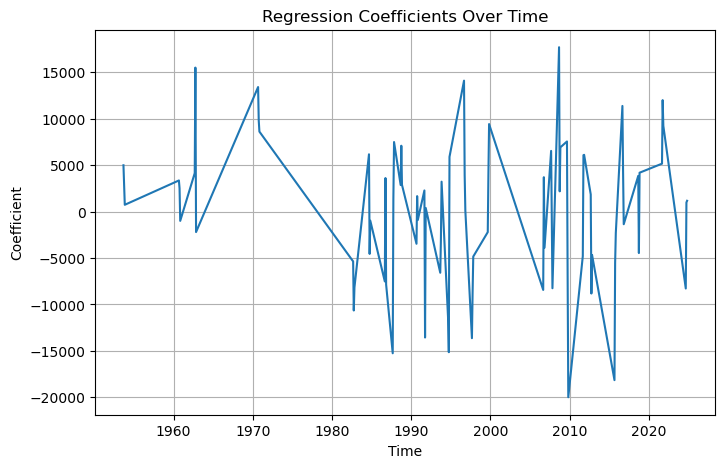

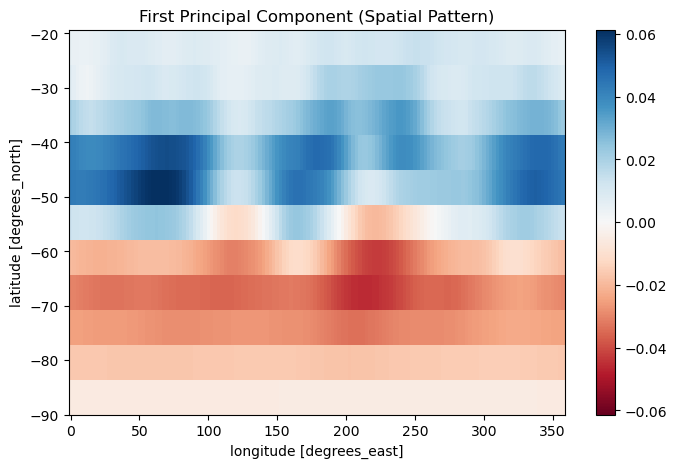

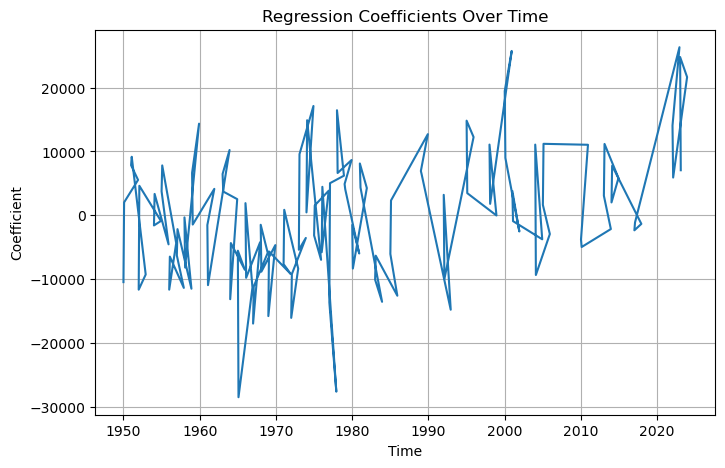

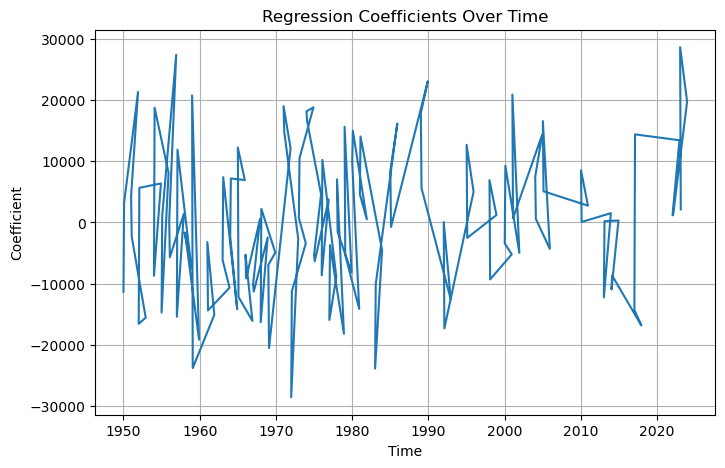

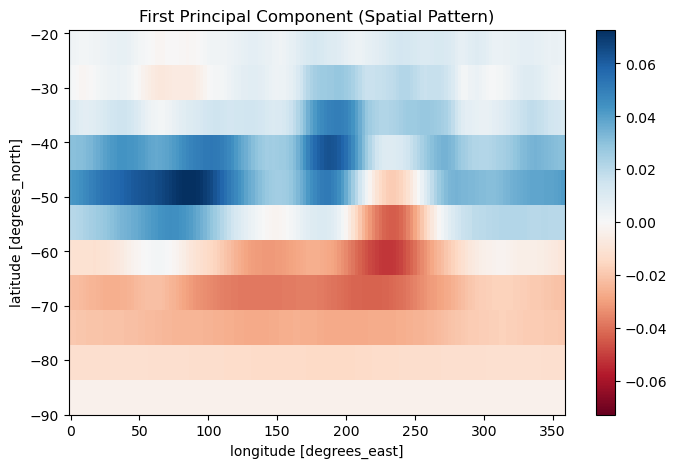

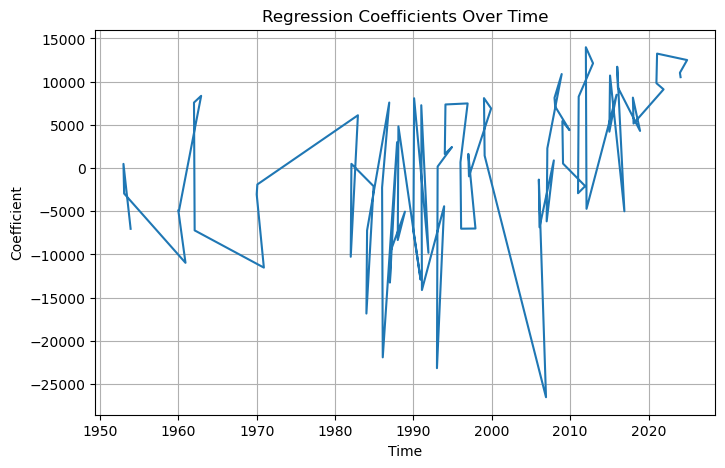

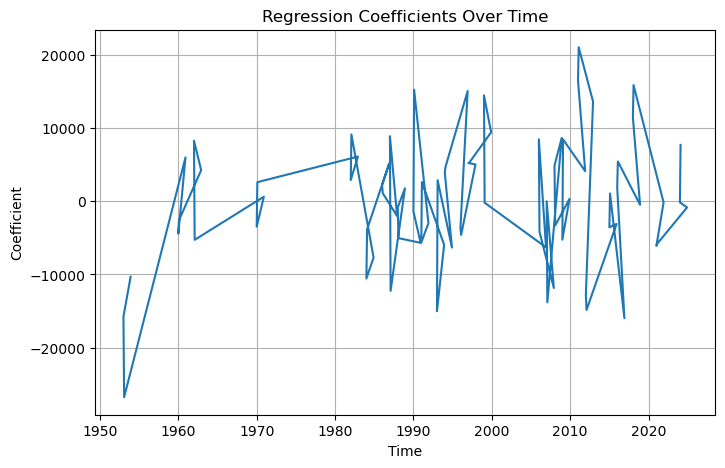

In [32]:
zg = xr.open_dataset('~/work/data/era5_zg_2.5x2.5.nc')
display(zg)
zg_ren = zg.rename({'valid_time': 'time'})
zg_ren = zg_ren.sel(pressure_level=500).z.drop('pressure_level').sel(time=slice('1950','2024'),lat=slice(-90,-20))
#display(zg['lat'])

# if one wants to look at it seasonally:
zg_DJF=shift_december(extract_seasonal_data(zg_ren,[12,1,2]))

early_years = era_DJF_LaPlata_df.loc[
    era_DJF_LaPlata_df['VB_class'] == 'Early'
].index.values
late_years = era_DJF_LaPlata_df.loc[
    era_DJF_LaPlata_df['VB_class'] == 'Late'
].index.values

zg_DJF_early = zg_DJF.where(
    zg_DJF['time.year'].isin(early_years),
    drop=True
)

zg_DJF_late = zg_DJF.where(
    zg_DJF['time.year'].isin(late_years),
    drop=True
)
zg_SON=extract_seasonal_data(zg_ren,[9,10,11])


early_years_SON = era_SON_LaPlata_df.loc[
    era_SON_LaPlata_df['VB_class'] == 'Early'
].index.values
late_years_SON = era_SON_LaPlata_df.loc[
    era_SON_LaPlata_df['VB_class'] == 'Late'
].index.values

zg_SON_early = zg_SON.where(
    zg_SON['time.year'].isin(early_years_SON),
    drop=True
)

zg_SON_late = zg_SON.where(
    zg_SON['time.year'].isin(late_years_SON),
    drop=True
)

def SAM_comp(zg):
    # Compute monthly climatology --> each month has one average
    zg_climatology = zg.groupby('time.month').mean('time')
    # Compute monthly anomalies
    zg_anomalies = zg.groupby('time.month') - zg_climatology

    # Compute PCs
    zg_weighted = weight_by_latitude(zg_anomalies)
    reshaped_zg = reshape_to_2d(zg_weighted)

    SAM_total=SAM_procedure(reshaped_zg, zg_anomalies)
    SAM=SAM_total['SAM']
    A_SAM_index=SAM_total['SAM_asym_coefficient']
    S_SAM_index=SAM_total['SAM_sym_coefficient']

    #weight by lat again? --> no
    #detrend? --> no
    A_SAM_detr=A_SAM_index
    S_SAM_detr=S_SAM_index
    #normalise
    A_SAM_avg=(A_SAM_detr-A_SAM_detr.mean())/A_SAM_detr.std()
    S_SAM_avg=(S_SAM_detr-S_SAM_detr.mean())/S_SAM_detr.std()

    return A_SAM_avg, S_SAM_avg

def SAM_procedure(reshaped_zg, zg_anomalies):
    cov_matrix = compute_covariance_matrix(reshaped_zg)
    U, S, Vt = perform_svd(cov_matrix) # all have shape 1584 in every dim, 
    #S has singular/eigenvalues and Vt has eigenvectors

    # Define SAM as first principal component
    SAM = plot_first_principal_component(reshaped_zg, Vt)

    # Decompose SAM in symmetric and asymmetric
    SAM_zonal_mean = compute_zonal_mean(SAM) #avg over all lon
    SAM_sym = make_zonal_mean_map(SAM_zonal_mean, zg_anomalies) #map the avg from above onto the whole field
    SAM_asym = SAM - SAM_sym #difference between map and first PCA gives 'anomaly'

    SAM_sym_coefficient = regress_onto_zonal_mean_map(zg_anomalies, SAM_sym)
    plot_regression_coefficients(zg_anomalies['time'], SAM_sym_coefficient)

    SAM_asym_coefficient = regress_onto_zonal_mean_map(zg_anomalies, SAM_asym)
    plot_regression_coefficients(zg_anomalies['time'], SAM_asym_coefficient)
    d={'SAM':SAM, 'SAM_zonal_mean':SAM_zonal_mean, 'SAM_sym':SAM_sym, 'SAM_asym':SAM_asym, \
       'SAM_sym_coefficient':SAM_sym_coefficient, 'SAM_asym_coefficient':SAM_asym_coefficient}
    return (d)

A_SAM_avg_early_SON, S_SAM_avg_early_SON=SAM_comp(zg_SON_early)
A_SAM_avg_late_SON, S_SAM_avg_late_SON=SAM_comp(zg_SON_late)
A_SAM_avg_early_DJF, S_SAM_avg_early_DJF=SAM_comp(zg_DJF_early)
A_SAM_avg_late_DJF, S_SAM_avg_late_DJF=SAM_comp(zg_DJF_late)



In [39]:
print((A_SAM_avg_early_SON).shape, A_SAM_avg_late_SON.shape)
print((A_SAM_avg_early_DJF).shape, A_SAM_avg_late_DJF.shape)

print(zg_ren.time)
print(zg_DJF.time)

(132,) (81,)
(131,) (81,)
<xarray.DataArray 'time' (time: 900)> Size: 7kB
array(['1950-01-01T00:00:00.000000000', '1950-02-01T00:00:00.000000000',
       '1950-03-01T00:00:00.000000000', ..., '2024-10-01T00:00:00.000000000',
       '2024-11-01T00:00:00.000000000', '2024-12-01T00:00:00.000000000'],
      shape=(900,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 7kB 1950-01-01 1950-02-01 ... 2024-12-01
Attributes:
    standard_name:  time
    long_name:      time
    axis:           T
<xarray.DataArray 'time' (time: 225)> Size: 2kB
array(['1950-01-01T00:00:00', '1950-02-01T00:00:00', '1951-12-01T00:00:00',
       ..., '2024-01-01T00:00:00', '2024-02-01T00:00:00',
       '2025-12-01T00:00:00'], shape=(225,), dtype='datetime64[s]')
Coordinates:
  * time     (time) datetime64[s] 2kB 1950-01-01 1950-02-01 ... 2025-12-01


(132, 11, 144)
(44,)


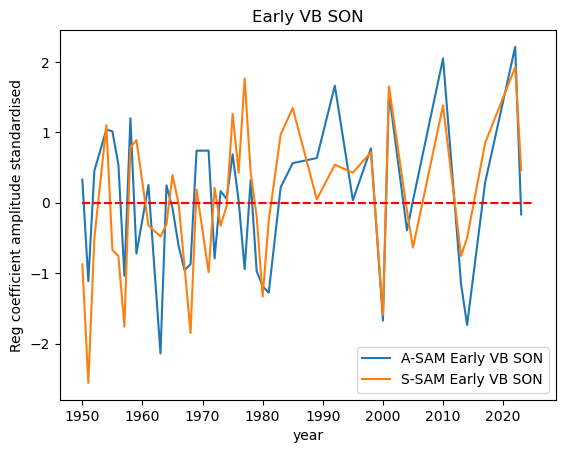

(81, 11, 144)
(27,)


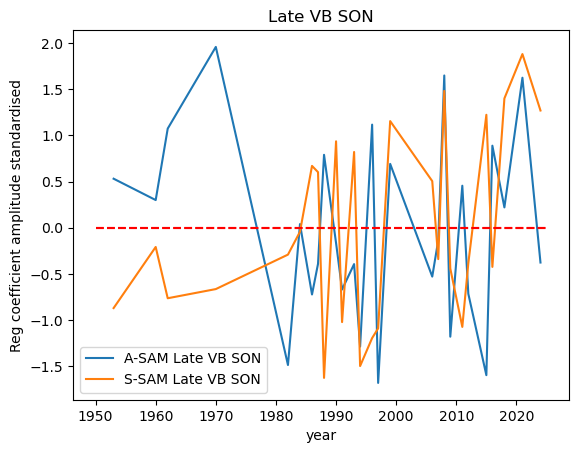

(131, 11, 144)
(44,)


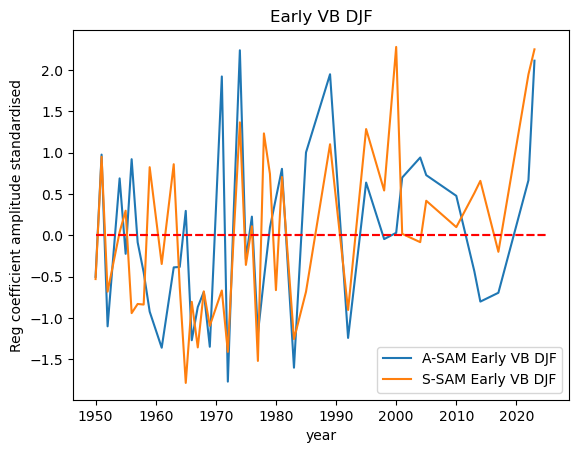

(81, 11, 144)
(27,)


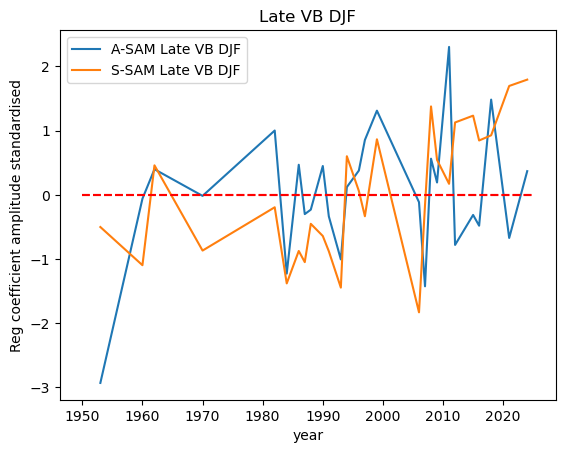

In [35]:
def make_xarray_again(array, zg_anomalies_DJF, xname):
    A_SAM_DJF_da = xr.DataArray(
        array, 
        coords={'time': zg_anomalies_DJF['time'].values}, 
        dims=['time'],
        name=xname
            )
    return A_SAM_DJF_da

A_SAM_list=[A_SAM_avg_early_SON, A_SAM_avg_late_SON, A_SAM_avg_early_DJF, A_SAM_avg_late_DJF]
S_SAM_list=[S_SAM_avg_early_SON, S_SAM_avg_late_SON, S_SAM_avg_early_DJF, S_SAM_avg_late_DJF]
zg_list=[zg_SON_early, zg_SON_late, zg_DJF_early, zg_DJF_late]
labels=['Early VB SON', 'Late VB SON', 'Early VB DJF', 'Late VB DJF']

A_SAM_indices=[]
S_SAM_indices=[]
for i in range(len(A_SAM_list)):
    print(zg_list[i].shape)
    a=make_xarray_again(A_SAM_list[i], zg_list[i], 'A_SAM')
    b=make_xarray_again(S_SAM_list[i], zg_list[i], 'S_SAM')
    if i<=1:
        a_ssavg=stdize_ssavg(seasonal_average(a))
        b_ssavg=stdize_ssavg(seasonal_average((b)))
    else:
        a_ssavg=stdize_ssavg(seasonal_average((a)))
        b_ssavg=stdize_ssavg(seasonal_average((b)))

    print(a_ssavg.shape)
    A_SAM_indices.append(a_ssavg)
    S_SAM_indices.append(b_ssavg)

    a_ssavg.plot(label='A-SAM '+labels[i])
    plt.hlines(np.mean(a_ssavg),xmin=1950, xmax=2025, color='red', linestyle='dashed')
    b_ssavg.plot(label='S-SAM '+labels[i])
    plt.hlines(np.mean(b_ssavg),xmin=1950, xmax=2025, color='red', linestyle='dashed')
    plt.title(labels[i])
    plt.ylabel('Reg coefficient amplitude standardised')
    plt.legend()
    plt.show()

In [18]:
def var_prepper(da, months_list, wghts_bool=True):
    ##1 Anomalies
    da_an=compute_anomaly(da)
    #print(da_an)
    ##2 detrending
    p = da_an.polyfit(dim='time', deg=1, skipna=False)
    coeffs = p[list(p.data_vars)[0]]   # or p.t2m_polyfit_coefficients
    t_fit = xr.polyval(da_an['time'], coeffs)
    da_detr=da_an - t_fit
    #print(da_detr)
    ##3 weight by latitude (if necessary)
    if wghts_bool==True:
        da_wght=weight_by_latitude(da_detr)
    else:
        da_wght=da_detr
    ##4 extract seasonal data and standardise it again
    da_season=extract_seasonal_data(da_wght,months_list)
    #print(da_season)
    if 12 in months_list:
        da_season_mean=stdize_ssavg(seasonal_average(shift_december(da_season)))
    else: 
        da_season_mean=stdize_ssavg(seasonal_average((da_season)))
        
    ##5 mask the ocean
    da_masked=sea_mask(da_season_mean)
    print(da_masked)
    return da_masked

In [19]:
#load temperature era5 data
t_era=xr.open_dataset('~/work/data/era5_t2m.nc') #variable name is t2m
t_era=t_era.rename({'valid_time':'time','latitude':'lat','longitude':'lon'})
t_total=t_era.sel(time=slice('1950','2024'),lat=slice(-20,-55),lon=slice(-76,-49)) 

t_whole_SON=var_prepper(t_total, [9,10,11], wghts_bool=False)
t_whole_DJF=var_prepper(t_total, [12,1,2], wghts_bool=False)

<xarray.Dataset> Size: 9MB
Dimensions:  (year: 75, lat: 141, lon: 105)
Coordinates:
  * lat      (lat) float64 1kB -20.0 -20.25 -20.5 -20.75 ... -54.5 -54.75 -55.0
  * lon      (lon) float64 840B -76.0 -75.75 -75.5 -75.25 ... -50.5 -50.25 -50.0
  * year     (year) int64 600B 1950 1951 1952 1953 1954 ... 2021 2022 2023 2024
Data variables:
    t2m      (year, lat, lon) float64 9MB nan nan nan nan ... nan nan nan nan
<xarray.Dataset> Size: 9MB
Dimensions:  (year: 76, lat: 141, lon: 105)
Coordinates:
  * lat      (lat) float64 1kB -20.0 -20.25 -20.5 -20.75 ... -54.5 -54.75 -55.0
  * lon      (lon) float64 840B -76.0 -75.75 -75.5 -75.25 ... -50.5 -50.25 -50.0
  * year     (year) int64 608B 1950 1951 1952 1953 1954 ... 2022 2023 2024 2025
Data variables:
    t2m      (year, lat, lon) float64 9MB nan nan nan nan ... nan nan nan nan


In [20]:
##Era 5 precip data
pr_era=xr.open_dataset('~/work/data/era5_tp.nc')
pr_era=pr_era.rename({'valid_time':'time','latitude':'lat','longitude':'lon'})
pr_total=pr_era.sel(time=slice('1950','2024'),lat=slice(-20,-55),lon=slice(-76,-49)) 

pr_whole_SON=var_prepper(pr_total, [9,10,11], wghts_bool=False)
pr_whole_DJF=var_prepper(pr_total, [12,1,2], wghts_bool=False)

<xarray.Dataset> Size: 9MB
Dimensions:  (year: 75, lat: 141, lon: 105)
Coordinates:
  * lat      (lat) float64 1kB -20.0 -20.25 -20.5 -20.75 ... -54.5 -54.75 -55.0
  * lon      (lon) float64 840B -76.0 -75.75 -75.5 -75.25 ... -50.5 -50.25 -50.0
  * year     (year) int64 600B 1950 1951 1952 1953 1954 ... 2021 2022 2023 2024
Data variables:
    tp       (year, lat, lon) float64 9MB nan nan nan nan ... nan nan nan nan
<xarray.Dataset> Size: 9MB
Dimensions:  (year: 76, lat: 141, lon: 105)
Coordinates:
  * lat      (lat) float64 1kB -20.0 -20.25 -20.5 -20.75 ... -54.5 -54.75 -55.0
  * lon      (lon) float64 840B -76.0 -75.75 -75.5 -75.25 ... -50.5 -50.25 -50.0
  * year     (year) int64 608B 1950 1951 1952 1953 1954 ... 2022 2023 2024 2025
Data variables:
    tp       (year, lat, lon) float64 9MB nan nan nan nan ... nan nan nan nan


In [42]:
A_SAM_indices[1].year

<xarray.DataArray 'year' (year: 27)> Size: 216B
array([1953, 1960, 1962, 1970, 1982, 1984, 1986, 1987, 1988, 1990, 1991, 1993,
       1994, 1996, 1997, 1999, 2006, 2007, 2008, 2009, 2011, 2012, 2015, 2016,
       2018, 2021, 2024])
Coordinates:
  * year     (year) int64 216B 1953 1960 1962 1970 1982 ... 2016 2018 2021 2024

In [49]:
#display(t_LaPlata_ssavg_SON)

years_to_drop = [1950, 2002, 2019, 2025]

def exclude_years_xr(xr_obj, years):
    return xr_obj.sel(year=~xr_obj.year.isin(years))

##SON
t_whole_SON_ex=exclude_years_xr(t_whole_SON, years_to_drop)
pr_whole_SON_ex=exclude_years_xr(pr_whole_SON, years_to_drop)
A_SAM_early_SON=exclude_years_xr(A_SAM_indices[0], years_to_drop)
A_SAM_late_SON=exclude_years_xr(A_SAM_indices[1], years_to_drop)
S_SAM_early_SON=exclude_years_xr(S_SAM_indices[0], years_to_drop)
S_SAM_late_SON=exclude_years_xr(S_SAM_indices[1], years_to_drop)

##DJF
cut_years=[1950,2003,2020,2025]
t_whole_DJF_ex=exclude_years_xr(t_whole_DJF, cut_years)
pr_whole_DJF_ex=exclude_years_xr(pr_whole_DJF, cut_years)
A_SAM_early_DJF=exclude_years_xr(A_SAM_indices[2], cut_years)
A_SAM_late_DJF=exclude_years_xr(A_SAM_indices[3], cut_years)
S_SAM_early_DJF=exclude_years_xr(S_SAM_indices[2], cut_years)
S_SAM_late_DJF=exclude_years_xr(S_SAM_indices[3], cut_years)

In [50]:
##SON data
ds_SON = xr.merge([t_whole_SON_ex,pr_whole_SON_ex, era_SON_LaPlata_array])

##DJF data
ds_DJF=xr.merge([t_whole_DJF_ex,pr_whole_DJF_ex, era_DJF_LaPlata_array])
display(ds_SON)

<xarray.Dataset> Size: 17MB
Dimensions:         (lat: 141, lon: 105, year: 73)
Coordinates:
  * lat             (lat) float64 1kB -20.0 -20.25 -20.5 ... -54.5 -54.75 -55.0
  * lon             (lon) float64 840B -76.0 -75.75 -75.5 ... -50.5 -50.25 -50.0
  * year            (year) int64 584B 1950 1951 1952 1953 ... 2022 2023 2024
Data variables: (12/13)
    t2m             (year, lat, lon) float64 9MB nan nan nan nan ... nan nan nan
    tp              (year, lat, lon) float64 9MB nan nan nan nan ... nan nan nan
    t_LaPlata       (year) float64 584B nan 1.008 -0.3405 ... -2.234 1.707 1.963
    precip_LaPlata  (year) float64 584B nan 1.251 -1.636 ... 1.411 -0.9275
    ENSO            (year) float64 584B nan 0.8577 -0.08958 ... 1.719 -0.33
    IOD             (year) float64 584B nan 0.1126 -0.4963 ... 3.25 0.8168
    ...              ...
    EDJ_lat         (year) float64 584B nan 1.568 -1.369 ... -0.1452 1.446
    EDJ_lat_nostd   (year) float64 584B nan -48.64 -53.79 ... -51.64 -48.86
    SPV             (year) float64 584B nan -1.639 0.7289 ... 0.9296 -0.05547
    A_SAM           (year) float64 584B nan -0.6832 0.7533 ... -0.6919 -0.4684
    S_SAM           (year) float64 584B nan -2.402 -0.386 ... 0.5597 0.9627
    VB_class        (year) object 584B 'Early' 'Early' ... 'Early' 'Late'

In [51]:
def construct_da_x_year_fix(ds, size=30):
    ##this is a very confusing method, but I trust that it works...
    ds_roll=ds.rolling(year=size, center=False).construct("window")
    ds_roll_full=ds_roll.isel(year=slice(size-1, None))  # drop incomplete windows
    ds_chunked=ds_roll_full.chunk(lat=int(len(ds.lat)/4),lon=int(len(ds.lon)/4),year=-1)
    return ds_chunked

def lin_model_fast(y, x_main, *x_controls):
    """
    y         : (window,)
    x_main    : (window,)
    x_controls: (window,)

    Returns
    -------
    coef_main : float
    """

    # stack predictors
    X_list = [x_main] + list(x_controls)
    X = np.stack(X_list, axis=1)  # shape (window, n_predictors)

    mask = ~np.isnan(y) & ~np.any(np.isnan(X), axis=1)
    #print(mask.sum())

    X = X[mask]
    y = y[mask]

    try:
        return np.linalg.lstsq(X, y, rcond=None)[0][0]
    except:
        return np.nan
    
    
def sensitivity_analysis_fast(ds_rolled, target, driver, controls=None):
    """
    Perform regression for each grid point and rolling window.

    Parameters
    ----------
    ds_rolled : Dataset (year, window, lat, lon)
    target    : str (e.g. 't2m')
    driver    : str (main predictor, e.g. 'ENSO')
    controls  : list of str (optional)

    Returns
    -------
    coef_da : DataArray (year, lat, lon)
    """

    y = ds_rolled[target]
    x_main = ds_rolled[driver]

    if controls is not None:
        x_controls = [ds_rolled[var] for var in controls]
    else:
        x_controls = []

    coef = xr.apply_ufunc(
        lin_model_fast,
        y,
        x_main,
        *x_controls,
        input_core_dims=[["window"]] * (2 + len(x_controls)),
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )

    return coef


def conditioning_everything_fast(ds, driver_list, target, total_eff=False, whole_period=True):
    """
    Compute regression maps for multiple drivers.

    Returns
    -------
    list of DataArrays (one per driver)
    """

    results = []

    # create rolling windows once
    ds_rolled = ds #construct_da_x_year_fix(ds)

    for driver in driver_list:

        # determine controls
        if not total_eff:
            controls = [d for d in driver_list if d != driver]

            if 'A_SAM' in driver_list and driver in ['SPV', 'VB', 'S_SAM']:
                if 'A_SAM' in controls:
                    controls.remove('A_SAM')

            elif ('SPV' in driver_list or 'VB' in driver_list) and driver == 'A_SAM':
                controls = [c for c in controls if c not in ['SPV', 'VB', 'S_SAM']]

        else:
            if driver == 'IOD' or driver=='IOBW':
                controls = ['ENSO']
            elif driver == 'SPV':
                controls = ['ENSO', 'IOD']
            elif driver == 'VB':
                controls = ['ENSO', 'IOBW']
            else:
                controls = None
        if whole_period==True:

            if controls is not None:
                x_controls = [ds_rolled[var] for var in controls]
            else:
                x_controls = []
            
            coef = xr.apply_ufunc(
                lin_model_fast,
                ds_rolled[target],
                ds_rolled[driver],
                *x_controls,
                input_core_dims=[["year"], ["year"]] + [["year"]] * len(x_controls),
                #input_core_dims=[["year"]] * (2 + len(x_controls)),
                output_core_dims=[[]],
                vectorize=True,
                dask="parallelized",
                output_dtypes=[float],
            )
            mean_coef=coef
        else:
            coef = sensitivity_analysis_fast(
            ds_rolled,
            target=target,
            driver=driver,
            controls=controls
            )

            mean_coef = coef.mean(dim="year")

        results.append(mean_coef)

        print(f"{driver} done")

    return results

Whole Area Spring ERA5 data

In [63]:
##separate data into two regimes
ds_early_SON=ds_SON.where(ds_SON.VB_class=='Early')
ds_late_SON=ds_SON.where(ds_SON.VB_class=='Late')

ds_early_SONsep=ds_early_SON.drop_vars(['A_SAM', 'S_SAM'])
ds_early_SON_sep=xr.merge([ds_early_SONsep, A_SAM_early_SON, S_SAM_early_SON])

ds_late_SONsep=ds_late_SON.drop_vars(['A_SAM', 'S_SAM'])
ds_late_SON_sep=xr.merge([ds_late_SONsep, A_SAM_late_SON, S_SAM_late_SON])
display(ds_early_SON_sep)

<xarray.Dataset> Size: 17MB
Dimensions:         (lat: 141, lon: 105, year: 73)
Coordinates:
  * lat             (lat) float64 1kB -20.0 -20.25 -20.5 ... -54.5 -54.75 -55.0
  * lon             (lon) float64 840B -76.0 -75.75 -75.5 ... -50.5 -50.25 -50.0
  * year            (year) int64 584B 1950 1951 1952 1953 ... 2022 2023 2024
Data variables: (12/13)
    t2m             (year, lat, lon) float64 9MB nan nan nan nan ... nan nan nan
    tp              (year, lat, lon) float64 9MB nan nan nan nan ... nan nan nan
    t_LaPlata       (year) float64 584B nan 1.008 -0.3405 ... -2.234 1.707 nan
    precip_LaPlata  (year) float64 584B nan 1.251 -1.636 ... -1.187 1.411 nan
    ENSO            (year) float64 584B nan 0.8577 -0.08958 ... -1.065 1.719 nan
    IOD             (year) float64 584B nan 0.1126 -0.4963 ... -0.9812 3.25 nan
    ...              ...
    EDJ_lat         (year) float64 584B nan 1.568 -1.369 ... -1.859 -0.1452 nan
    EDJ_lat_nostd   (year) float64 584B nan -48.64 -53.79 ... -54.64 -51.64 nan
    SPV             (year) float64 584B nan -1.639 0.7289 ... 1.558 0.9296 nan
    VB_class        (year) object 584B 'Early' 'Early' 'Early' ... 'Early' nan
    A_SAM           (year) float64 584B nan -1.114 0.4521 ... 2.211 -0.1672 nan
    S_SAM           (year) float32 292B nan -2.558 -0.5048 ... 1.924 0.4608 nan

In [64]:
result_early=conditioning_everything_fast(ds_early_SON_sep, ['ENSO', 'IOD', 'SPV', 'A_SAM', 'S_SAM'], 't2m')
print(result_early)

result_late=conditioning_everything_fast(ds_late_SON_sep, ['ENSO', 'IOD', 'SPV', 'A_SAM', 'S_SAM'], 't2m')
print(result_late)

ENSO done
IOD done
SPV done
A_SAM done
S_SAM done
[<xarray.DataArray (lat: 141, lon: 105)> Size: 118kB
array([[ 0.        ,  0.        ,  0.        , ..., -0.13818242,
        -0.16491714, -0.16758889],
       [ 0.        ,  0.        ,  0.        , ..., -0.16661987,
        -0.1915261 , -0.18437427],
       [ 0.        ,  0.        ,  0.        , ..., -0.19347017,
        -0.20480649, -0.19552719],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]], shape=(141, 105))
Coordinates:
  * lat      (lat) float64 1kB -20.0 -20.25 -20.5 -20.75 ... -54.5 -54.75 -55.0
  * lon      (lon) float64 840B -76.0 -75.75 -75.5 -75.25 ... -50.5 -50.25 -50.0, <xarray.DataArray (lat: 141, lon: 105)> Size: 118kB
array([[0.        , 0.        , 0.     

In [65]:
pr_reg_LP_SON_early=conditioning_everything_fast(ds_early_SON_sep, \
                                                 ['ENSO', 'IOD', 'SPV', 'A_SAM', 'S_SAM'], 'tp')
pr_reg_LP_SON_late=conditioning_everything_fast(ds_late_SON_sep, \
                                                 ['ENSO', 'IOD', 'SPV', 'A_SAM', 'S_SAM'], 'tp')

ENSO done
IOD done
SPV done
A_SAM done
S_SAM done
ENSO done
IOD done
SPV done
A_SAM done
S_SAM done


In [66]:
import cartopy.feature as cfeature
def modified_colorbar(cmap, levels, center_zero=True):
    n = len(levels) - 1
    colors = cmap(np.linspace(0, 1, n))
    
    if center_zero:
        mid = n // 2
        if n % 2 == 0: ##for even number of levels, set the two middle colors to white
            colors[mid-1:mid+1] = [1, 1, 1, 1]
        else:
            colors[mid] = np.array([1, 1, 1, 1])  # white
    
    return mcolors.ListedColormap(colors)

def plot_map(
    i,
    da,
    title,
    units,
    fig,
    subplts_num,
    cmap=plt.cm.viridis,
    cbar_each=None,
    levels=None,
    pval=None,
    fontsize=14,
    smooth=False,
):
    """
    Plot a regional map using only the spatial extent of da with PlateCarree.

    Parameters
    ----------
    da : xarray.DataArray
        DataArray with dimensions (lat, lon)
    pval : xarray.DataArray, optional
        p-values on same grid as da
    """
    # Extract coordinates
    lat = da.lat.values
    lon = da.lon.values
    arr = da.values

    # Create axis with PlateCarree projection
    ax = fig.add_subplot(1, subplts_num, i, projection=ccrs.PlateCarree())

    # Set extent to data region only
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

    # Colormap normalization
    # ---- FIX: always center at zero ----
    if cbar_each is None:
        vmax = np.nanmax(np.abs(arr))
    else:
        vmax=cbar_each
    if levels is None:
        levels = np.arange(-3, 3.01, 0.5)  # include +3
    cmap_mod=modified_colorbar(cmap, levels, center_zero=True)
    norm = BoundaryNorm(levels, ncolors=cmap_mod.N, clip=True)

    
    # Plot the field
    if smooth:
        cs = ax.contourf(lon, lat, arr, norm=norm, transform=ccrs.PlateCarree(), cmap=cmap_mod)
    else:
        cs = ax.pcolormesh(lon, lat, arr, norm=norm, transform=ccrs.PlateCarree(),
                           cmap=cmap_mod, shading="auto")
        

    ax.coastlines(resolution="50m")        # still keep coastlines
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)  # add country borders

    # Title
    ax.text(0.01, 1.02, title, transform=ax.transAxes, fontsize=fontsize)
    ax.set_adjustable('box')

    # Colorbar
    # ---- individual colorbars ----
    if cbar_each is None:
        cbar_ax = ax.inset_axes([0.05, -0.12, 0.9, 0.07])
        cbar = plt.colorbar(cs, orientation="horizontal", cax=cbar_ax,fraction=0.046,
                pad=0.08)
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_ticks(levels)
        cbar.set_label(units, fontsize=fontsize)

    # Significance overlay
    if pval is not None:
        inds = np.argwhere(pval.values > 0.05)
        ax.plot(
            lon[inds[:, 1]],
            lat[inds[:, 0]],
            markersize=5.0,
            color="grey",
            marker=".",
            linestyle="None",
            transform=ccrs.PlateCarree(),
        )
    return cs

        
def subplots_map(ds, title_list, cmap=plt.cm.RdBu.reversed(), unit='K', steps=0.1, \
                 cbar_each=None, heading=None, global_max_val=0.0):
    cs_list=[]
    fontsize=16
    
    global_max=0
    for da in ds:
        local_max = np.nanmax(np.abs(da.values))
        global_max = max(global_max, local_max)
    if global_max<global_max_val: #if the global max is lower than the provided levels, we need to adjust them
        global_max=global_max_val
        
    #Define levels for colorbar later
    step = steps # or 0.25 if you prefer
    max_abs = np.ceil(global_max / step) * step
    #print(max_abs)
    #levels = np.round(np.arange(-max_abs, max_abs + step, step), decimals=2)  
    levels = np.linspace(
    -max_abs,
    max_abs,
    int(2 * max_abs / step) + 1
    )
    
    ##Find optimal figsize
    width_per_plot = 4
    height = 5 

    fig = plt.figure(figsize=(len(ds) * width_per_plot, height))
    fig.subplots_adjust(top=0.8)
    
    for j, da in enumerate(ds):
        
        cs=plot_map( #get the colorbar for each subplot
        i=j+1,
        da=da,
        pval=None,
        title=title_list[j],
        units=unit,
        cbar_each=global_max,
        fig=fig,
        subplts_num=len(ds),
        cmap=cmap,
        levels=levels,
        smooth=False,
        fontsize=fontsize)
        
        cs_list.append(cs)
    
    plt.tight_layout(rect=[0, 0.12, 1, 0.92])
    
    #if global_max>levels[-1]: #if the global max exceeds the provided levels, we need to adjust them
    
    
    if not cbar_each:
        #modify colorbar
        cmap_mod = modified_colorbar(cmap, levels, center_zero=True)

        # create independent global norm
        global_norm = BoundaryNorm(levels, ncolors=cmap_mod.N, clip=True)

        sm = cm.ScalarMappable(norm=global_norm, cmap=cmap_mod)
        sm.set_array([])
        
        cbar_ax = fig.add_axes([0.2, 0.08, 0.6, 0.03])
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
        ticks = np.arange(-max_abs, max_abs + step, step*2)  
        cbar.set_ticks(ticks)
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_label(unit, fontsize=fontsize)
                
    ##Heading
    if heading:
        fig.suptitle(heading, y=1.1, fontweight='bold', fontsize=18)
        fig.savefig('target_maps_whole/'+heading+'.jpg', dpi=300, bbox_inches='tight')
    
    plt.show()

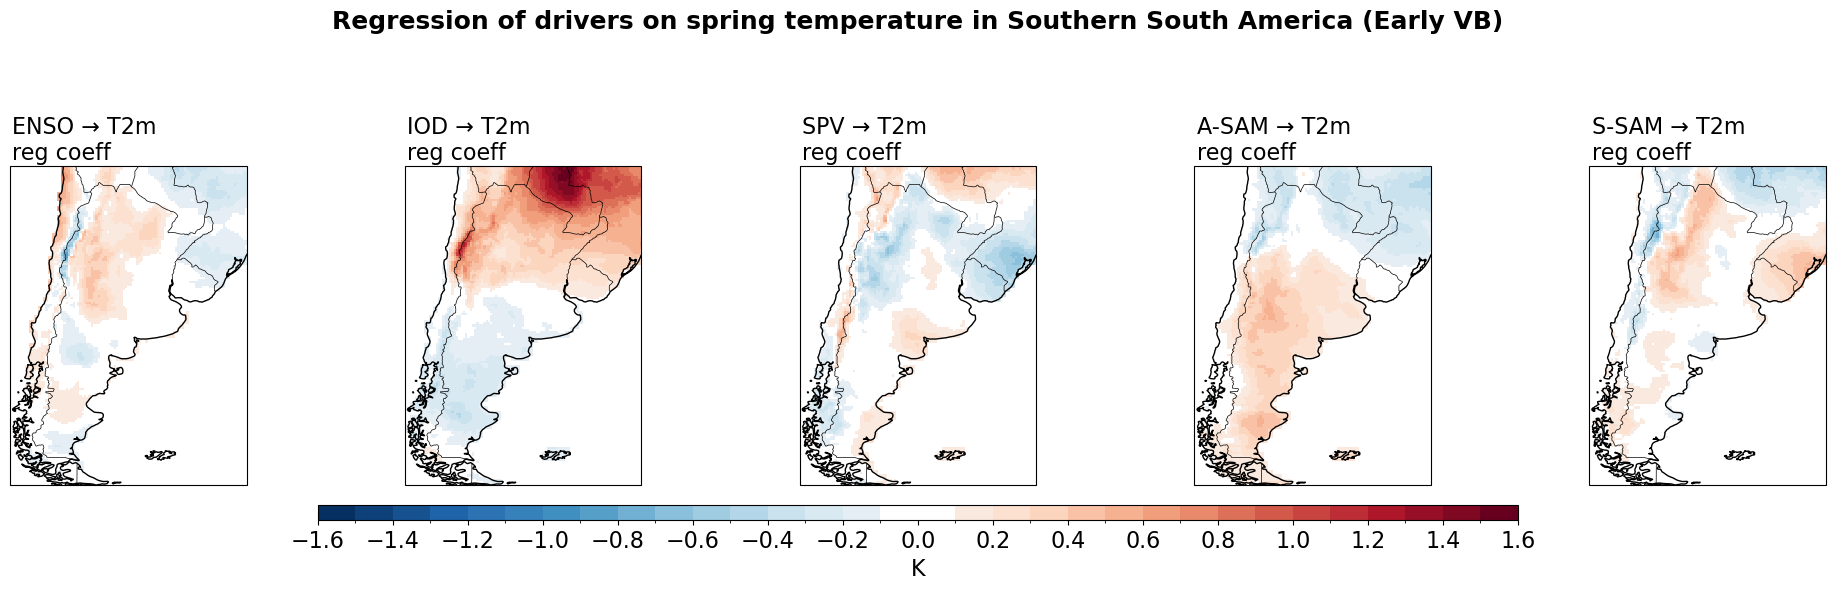

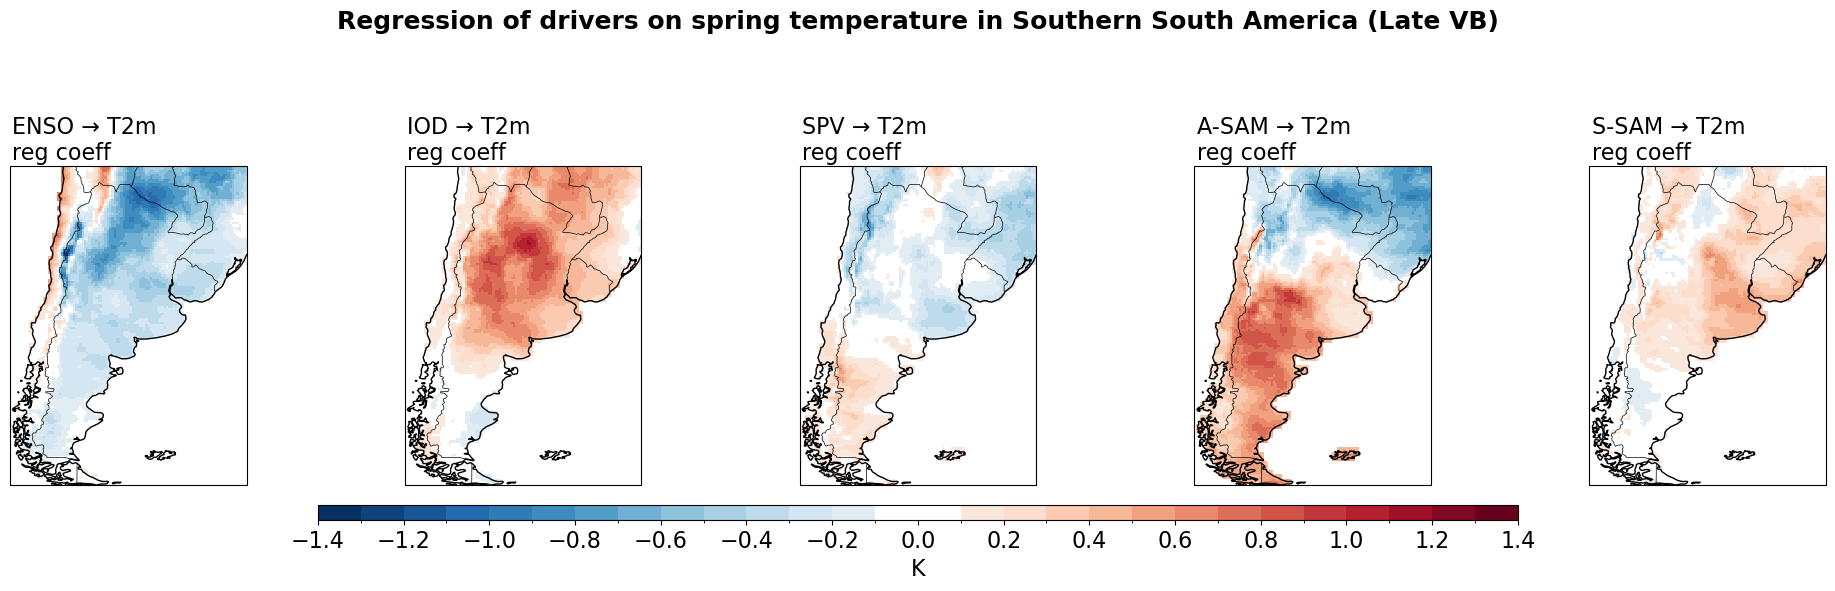

In [67]:
subplots_map(result_early, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", f"SPV → T2m \nreg coeff", \
                      f"A-SAM → T2m \nreg coeff", f"S-SAM → T2m \nreg coeff"],steps=.1,\
                          heading='Regression of drivers on spring temperature in Southern South America (Early VB)')
subplots_map(result_late, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", f"SPV → T2m \nreg coeff", \
                      f"A-SAM → T2m \nreg coeff", f"S-SAM → T2m \nreg coeff"],steps=.1,\
                          heading='Regression of drivers on spring temperature in Southern South America (Late VB)')
#levels=np.arange(-1., 1., 0.05)

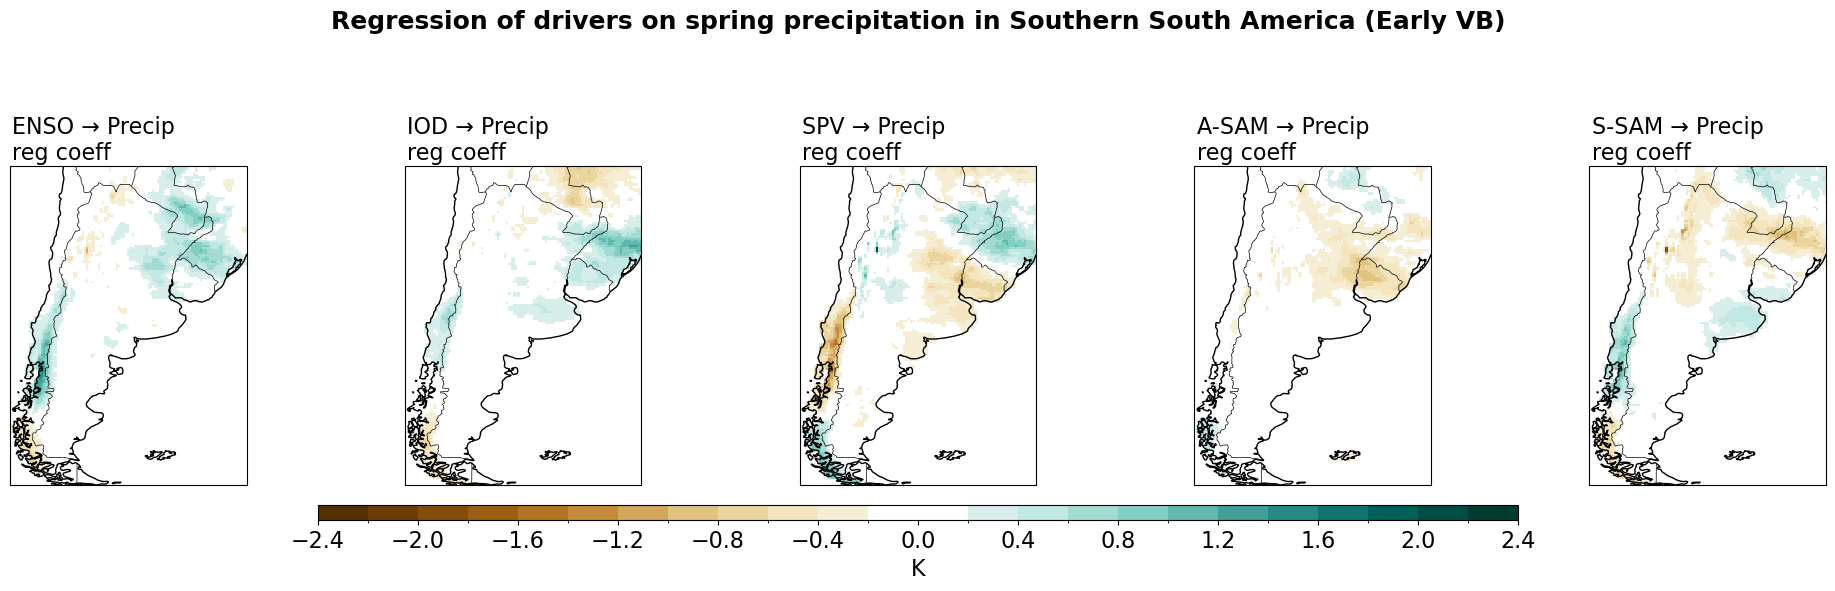

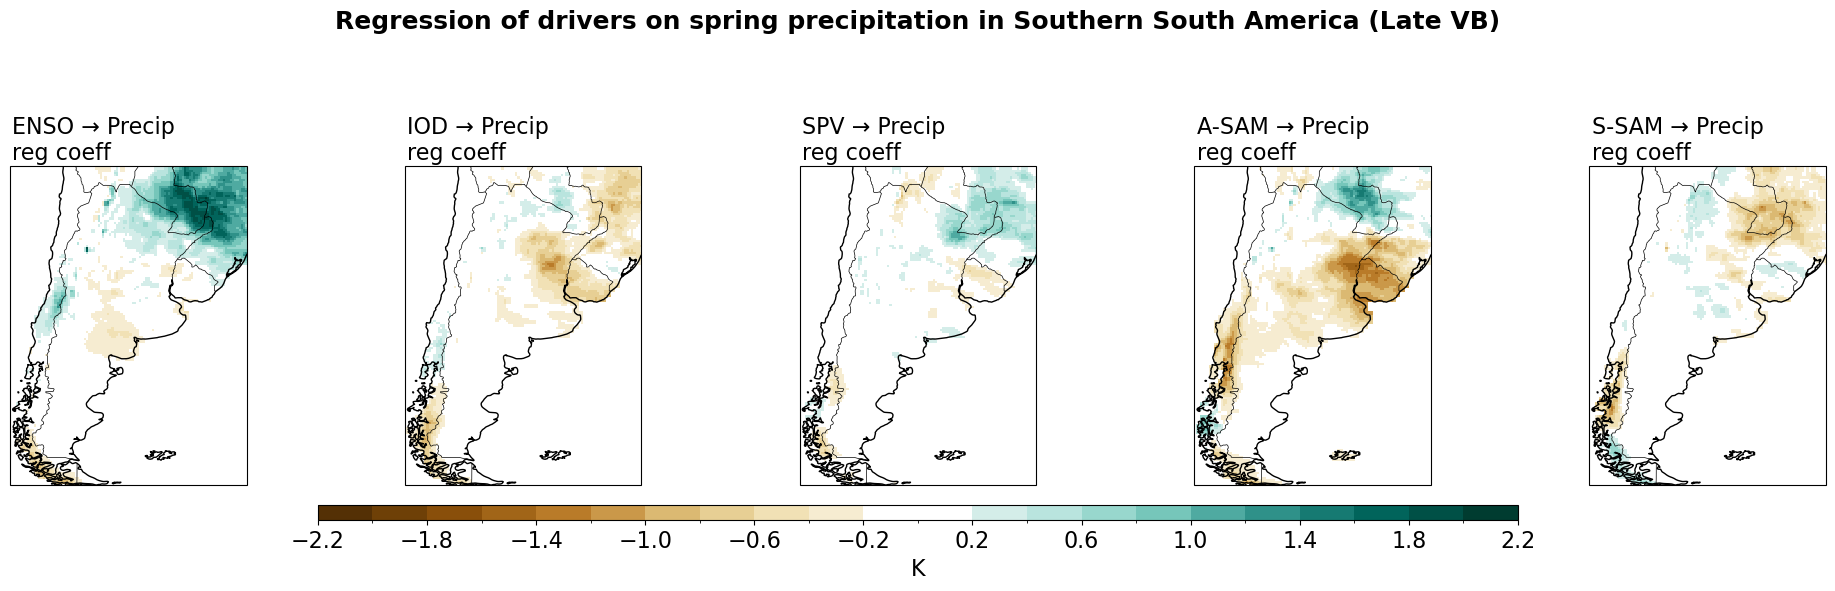

In [68]:
subplots_map(pr_reg_LP_SON_early, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", f"SPV → Precip \nreg coeff", \
                      f"A-SAM → Precip \nreg coeff", f"S-SAM → Precip \nreg coeff"], steps=.2,\
             cmap=plt.cm.BrBG ,heading='Regression of drivers on spring precipitation in Southern South America (Early VB)')
subplots_map(pr_reg_LP_SON_late, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", f"SPV → Precip \nreg coeff", \
                      f"A-SAM → Precip \nreg coeff", f"S-SAM → Precip \nreg coeff"], steps=.2,\
             cmap=plt.cm.BrBG ,heading='Regression of drivers on spring precipitation in Southern South America (Late VB)') 

In [69]:
##total effect of temp and precip in LP
t_reg_LP_SON_early_tot=conditioning_everything_fast(ds_early_SON_sep, ['ENSO', 'IOD', 'SPV'], 't2m',total_eff=True)
pr_reg_LP_SON_early_tot=conditioning_everything_fast(ds_early_SON_sep, ['ENSO', 'IOD', 'SPV'], 'tp',total_eff=True)

t_reg_LP_SON_late_tot=conditioning_everything_fast(ds_late_SON_sep, ['ENSO', 'IOD', 'SPV'], 't2m',total_eff=True)
pr_reg_LP_SON_late_tot=conditioning_everything_fast(ds_late_SON_sep, ['ENSO', 'IOD', 'SPV'], 'tp',total_eff=True)

ENSO done
IOD done
SPV done
ENSO done
IOD done
SPV done
ENSO done
IOD done
SPV done
ENSO done
IOD done
SPV done


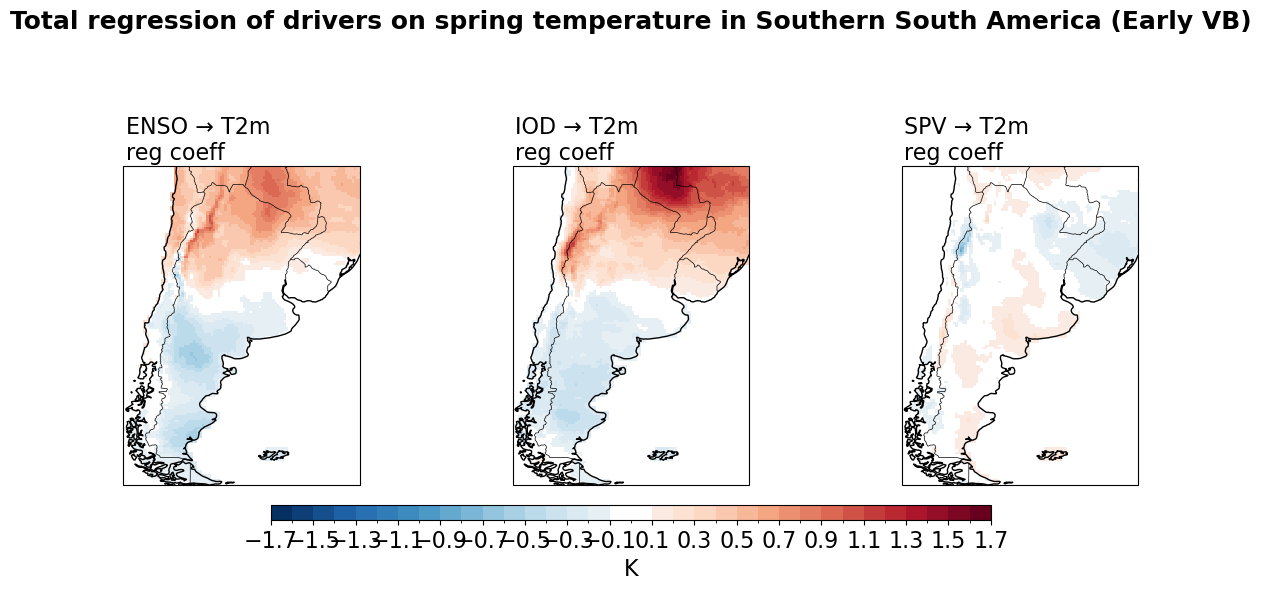

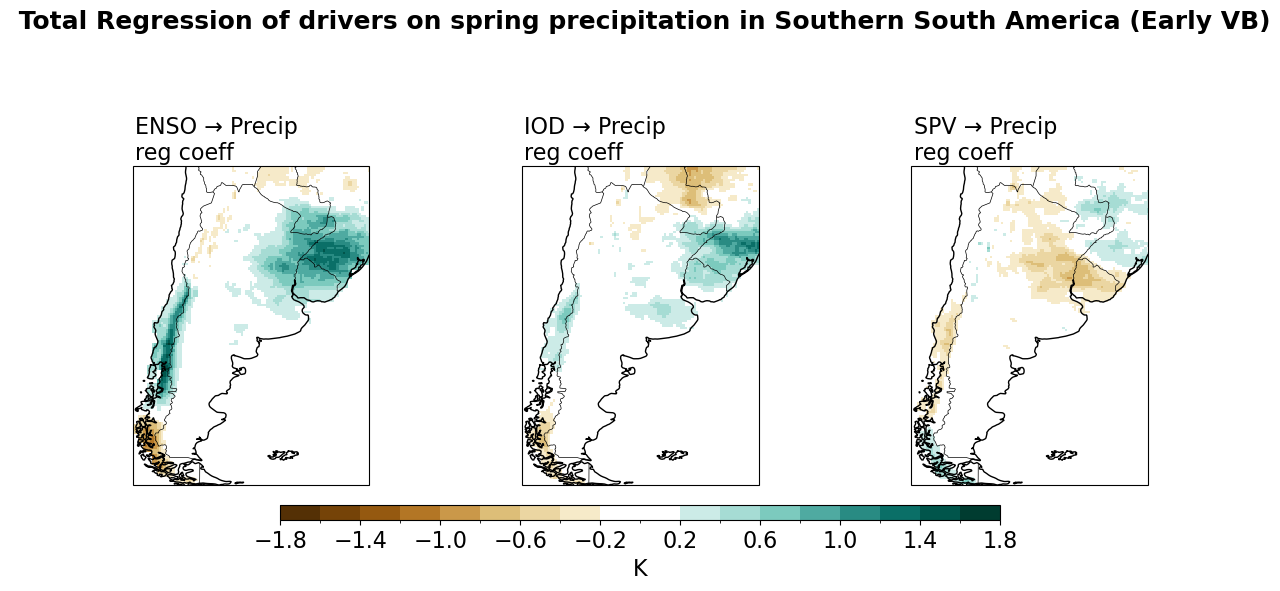

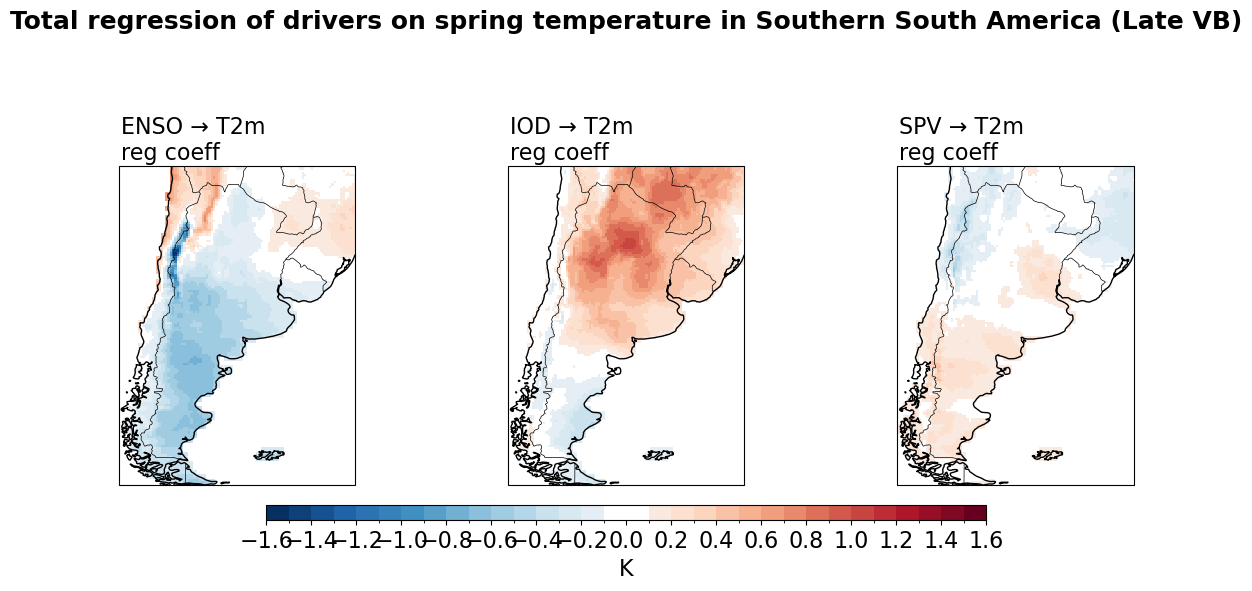

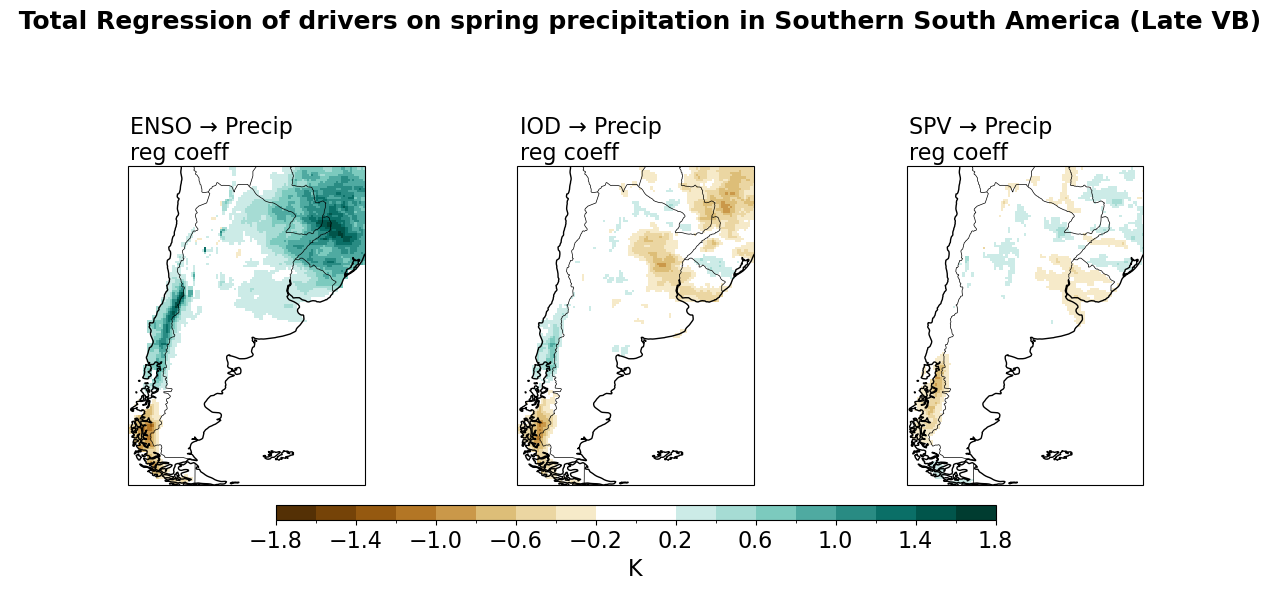

In [70]:
subplots_map(t_reg_LP_SON_early_tot, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", f"SPV → T2m \nreg coeff", \
                      ], steps=.1, heading='Total regression of drivers on spring temperature in Southern South America (Early VB)')
subplots_map(pr_reg_LP_SON_early_tot, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", f"SPV → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG, steps=.2 ,heading=' Total Regression of drivers on spring precipitation in Southern South America (Early VB)')
subplots_map(t_reg_LP_SON_late_tot, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", f"SPV → T2m \nreg coeff", \
                      ], steps=.1, heading='Total regression of drivers on spring temperature in Southern South America (Late VB)')
subplots_map(pr_reg_LP_SON_late_tot, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", f"SPV → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG, steps=.2 ,heading=' Total Regression of drivers on spring precipitation in Southern South America (Late VB)')

Whole Area Summer ERA5 data

In [72]:
##use regime transition variable: Vortex breakdown
ds_DJF_early=ds_DJF.where(ds_DJF.VB_class=='Early').dropna(dim='year', how='all')
ds_DJF_late=ds_DJF.where(ds_DJF.VB_class=='Late').dropna(dim='year', how='all')

ds_early_DJFsep=ds_DJF_early.drop_vars(['A_SAM', 'S_SAM'])
ds_early_DJF_sep=xr.merge([ds_early_DJFsep, A_SAM_early_DJF, S_SAM_early_DJF])

ds_late_DJFsep=ds_DJF_late.drop_vars(['A_SAM', 'S_SAM'])
ds_late_DJF_sep=xr.merge([ds_late_DJFsep, A_SAM_late_DJF, S_SAM_late_DJF])
display(ds_early_DJF_sep)

<xarray.Dataset> Size: 10MB
Dimensions:         (lat: 141, lon: 105, year: 44)
Coordinates:
  * lat             (lat) float64 1kB -20.0 -20.25 -20.5 ... -54.5 -54.75 -55.0
  * lon             (lon) float64 840B -76.0 -75.75 -75.5 ... -50.5 -50.25 -50.0
  * year            (year) int64 352B 1950 1951 1952 1954 ... 2017 2022 2023
Data variables: (12/15)
    t2m             (year, lat, lon) float64 5MB nan nan nan nan ... nan nan nan
    tp              (year, lat, lon) float64 5MB nan nan nan nan ... nan nan nan
    t_LaPlata       (year) float64 352B nan -1.181 -0.6489 ... 2.419 0.1107
    precip_LaPlata  (year) float64 352B nan 1.303 1.122 ... -3.097 -1.524
    ENSO            (year) float64 352B nan -0.6866 0.5838 ... -1.14 -0.7546
    IOD             (year) float64 352B nan 0.2555 0.6281 ... -0.8422 0.9651
    ...              ...
    SPV             (year) float64 352B nan 0.2633 -0.6312 ... 2.242 1.702
    IOBW            (year) float64 352B nan -1.546 0.8591 ... 0.2964 -1.495
    VB              (year) float64 352B nan -0.0653 -0.101 ... -3.942 -3.952
    VB_class        (year) object 352B 'Early' 'Early' ... 'Early' 'Early'
    A_SAM           (year) float64 352B nan 0.9758 -1.101 ... 0.6657 2.112
    S_SAM           (year) float32 176B nan 0.9493 -0.6823 ... 1.946 2.249

In [73]:
##these are all NaN (likely because of the small sample size) -->eliminated this condition here in lin_model_fast

LP_summer_t_reg_old_early=conditioning_everything_fast(ds_early_DJF_sep, ['ENSO', 'IOD', 'A_SAM', 'S_SAM'], 't2m')
LP_summer_pr_reg_old_early=conditioning_everything_fast(ds_early_DJF_sep, ['ENSO', 'IOD', 'A_SAM', 'S_SAM'], 'tp')
LP_summer_t_reg_early=conditioning_everything_fast(ds_early_DJF_sep, ['ENSO', 'IOBW', 'A_SAM', 'S_SAM'], 't2m')
LP_summer_pr_reg_early=conditioning_everything_fast(ds_early_DJF_sep, ['ENSO', 'IOBW', 'A_SAM', 'S_SAM'], 'tp')

ENSO done
IOD done
A_SAM done
S_SAM done
ENSO done
IOD done
A_SAM done
S_SAM done
ENSO done
IOBW done
A_SAM done
S_SAM done
ENSO done
IOBW done
A_SAM done
S_SAM done


In [74]:
print((~np.isnan(LP_summer_t_reg_early[3])).sum())

<xarray.DataArray ()> Size: 8B
array(14805)


In [75]:
LP_summer_t_reg_old_late=conditioning_everything_fast(ds_late_DJF_sep, ['ENSO', 'IOD', 'A_SAM', 'S_SAM'], 't2m')
LP_summer_pr_reg_old_late=conditioning_everything_fast(ds_late_DJF_sep, ['ENSO', 'IOD', 'A_SAM', 'S_SAM'], 'tp')
LP_summer_t_reg_late=conditioning_everything_fast(ds_late_DJF_sep, ['ENSO', 'IOBW', 'A_SAM', 'S_SAM'], 't2m')
LP_summer_pr_reg_late=conditioning_everything_fast(ds_late_DJF_sep, ['ENSO', 'IOBW', 'A_SAM', 'S_SAM'], 'tp')

ENSO done
IOD done
A_SAM done
S_SAM done
ENSO done
IOD done
A_SAM done
S_SAM done
ENSO done
IOBW done
A_SAM done
S_SAM done
ENSO done
IOBW done
A_SAM done
S_SAM done


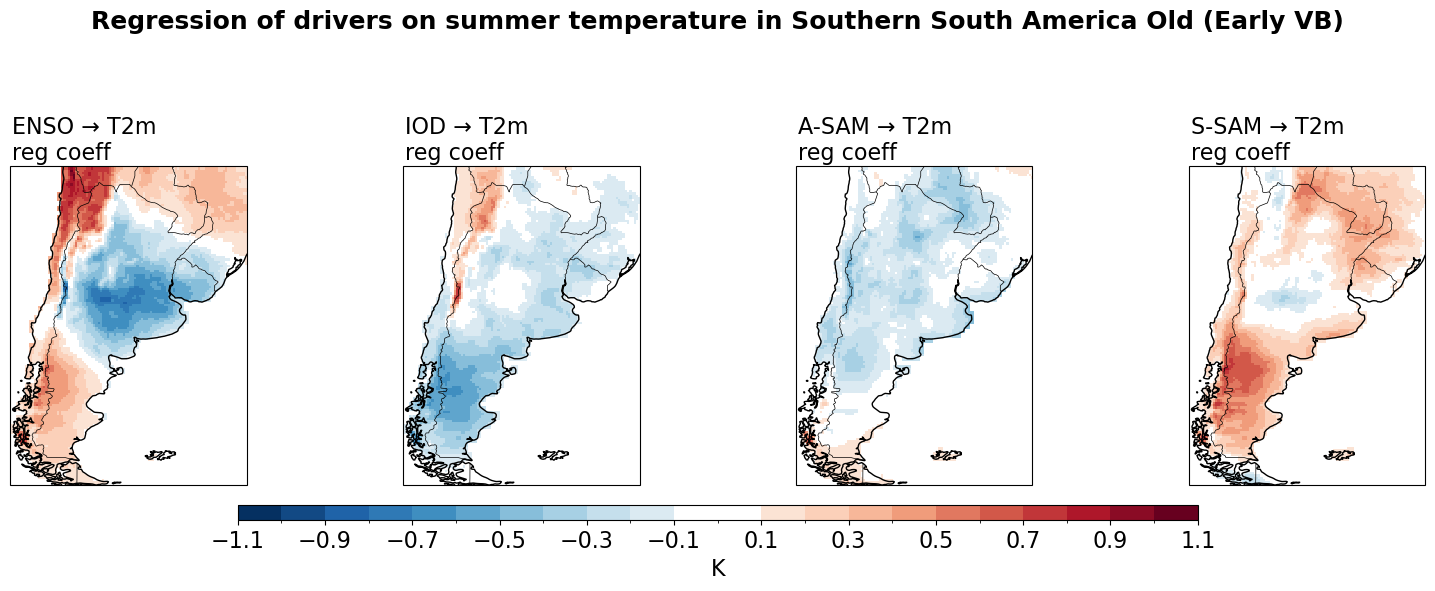

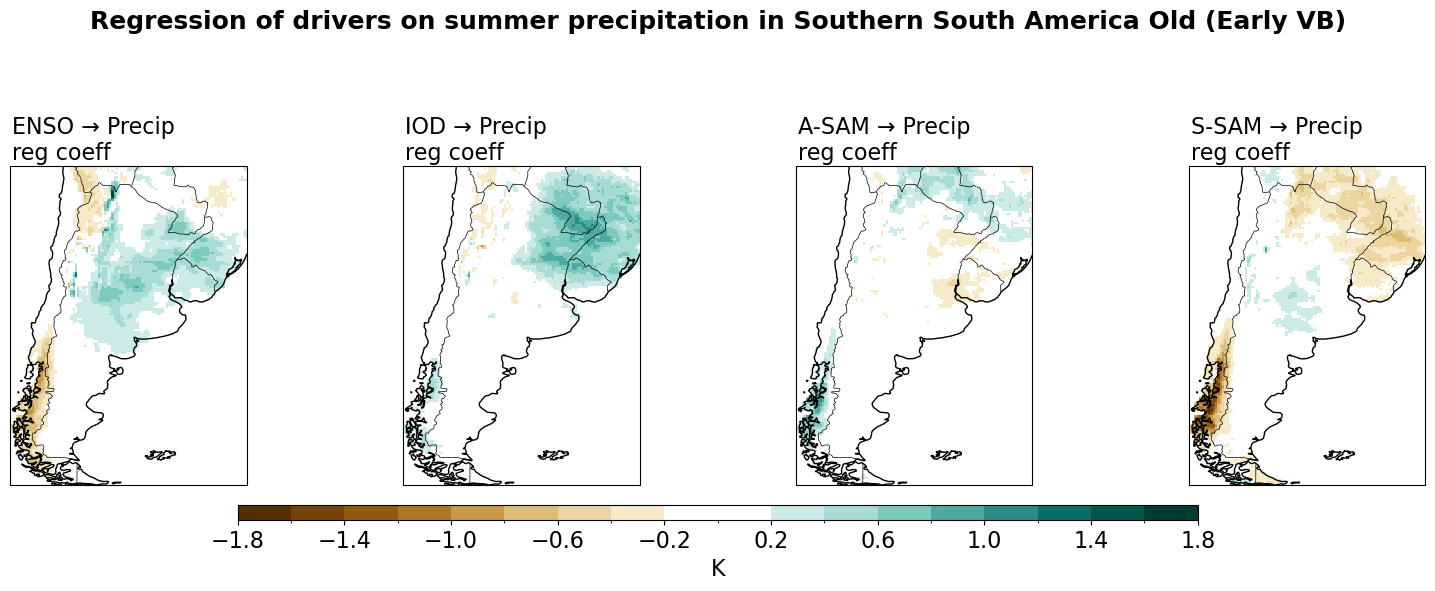

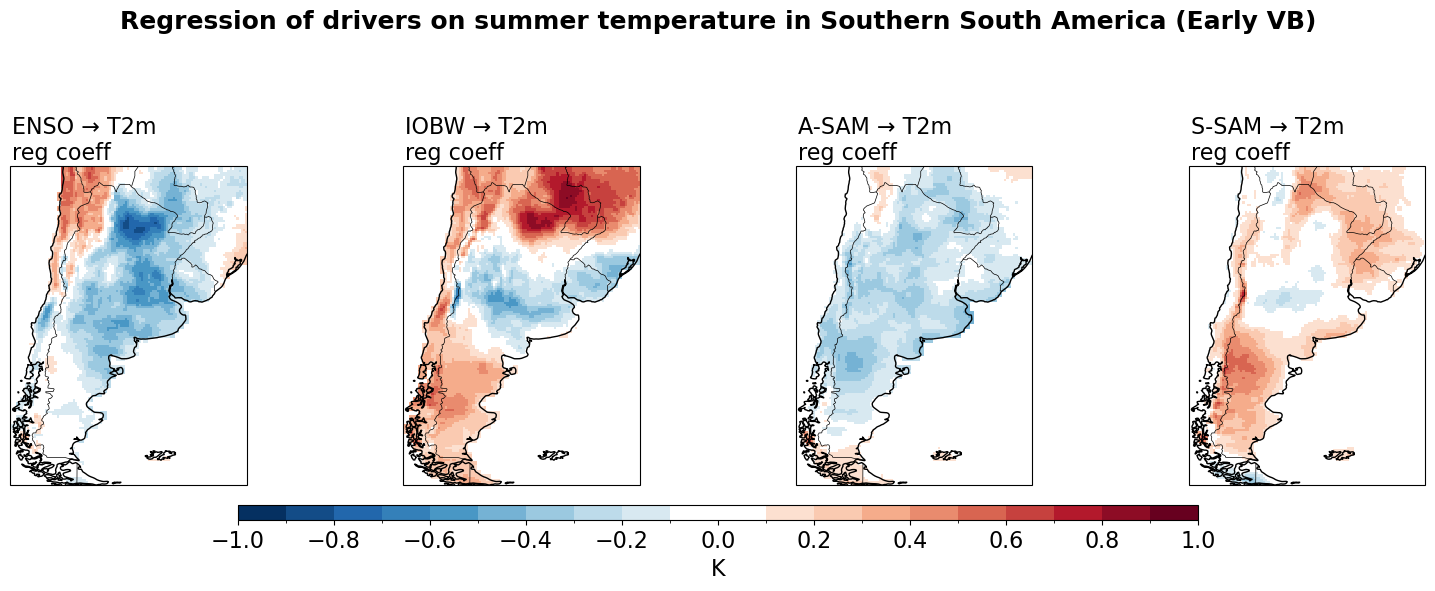

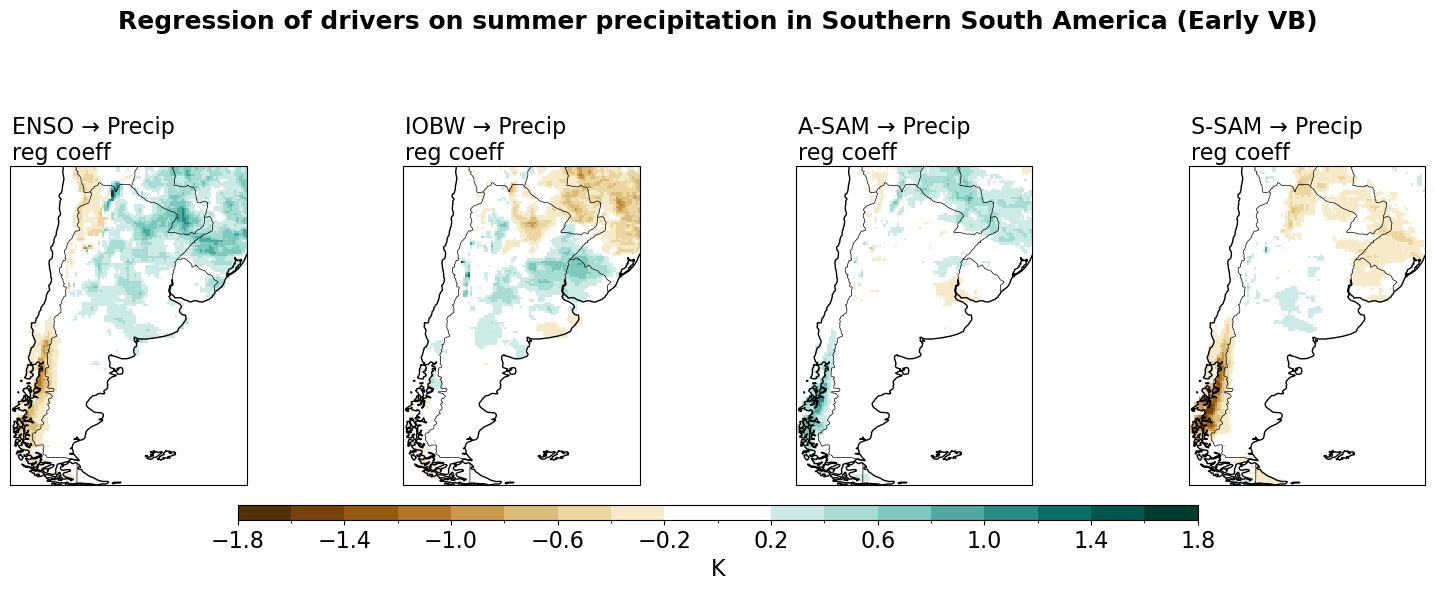

In [76]:
#print(result)
subplots_map(LP_summer_t_reg_old_early, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", \
                      f"A-SAM → T2m \nreg coeff", f"S-SAM → T2m \nreg coeff"], steps=.1,\
             heading='Regression of drivers on summer temperature in Southern South America Old (Early VB)')

subplots_map(LP_summer_pr_reg_old_early, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", \
                      f"A-SAM → Precip \nreg coeff", f"S-SAM → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG, steps=.2 ,heading='Regression of drivers on summer precipitation in Southern South America Old (Early VB)')
subplots_map(LP_summer_t_reg_early , [f"ENSO → T2m \nreg coeff", f"IOBW → T2m \nreg coeff", \
                      f"A-SAM → T2m \nreg coeff", f"S-SAM → T2m \nreg coeff"], steps=.1,\
             heading='Regression of drivers on summer temperature in Southern South America (Early VB)')

subplots_map(LP_summer_pr_reg_early, [f"ENSO → Precip \nreg coeff", f"IOBW → Precip \nreg coeff",  
                      f"A-SAM → Precip \nreg coeff", f"S-SAM → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG, steps=.2 ,heading='Regression of drivers on summer precipitation in Southern South America (Early VB)')

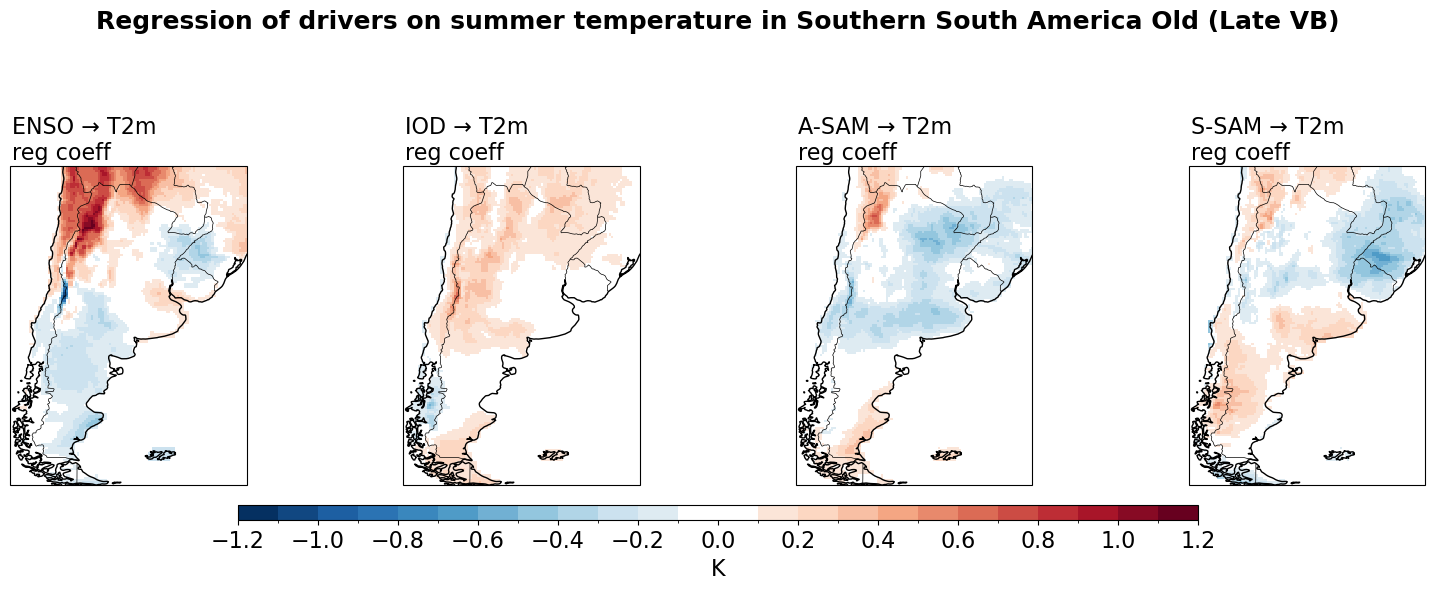

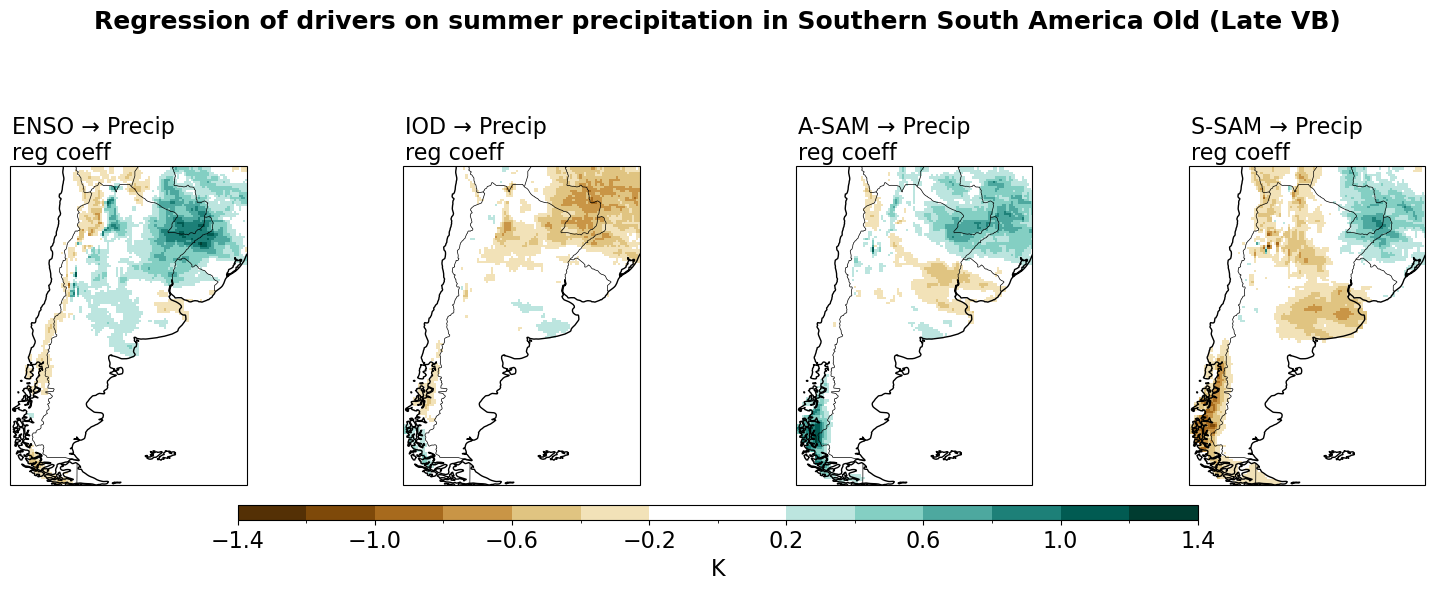

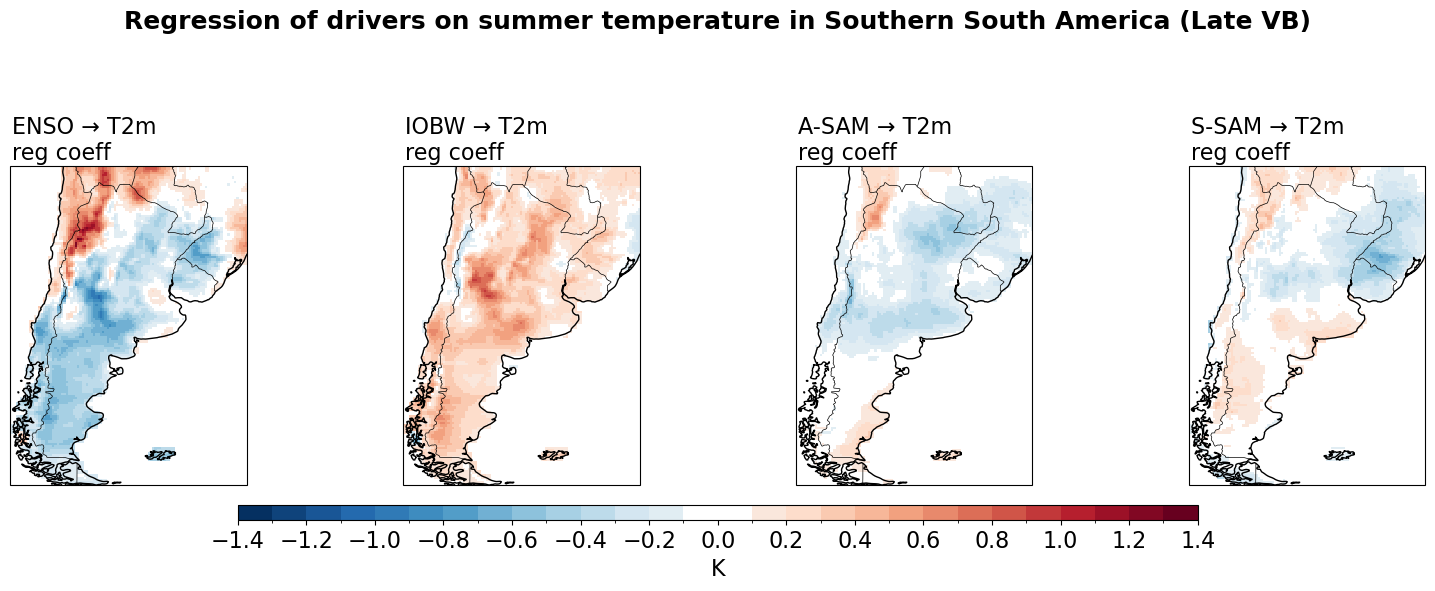

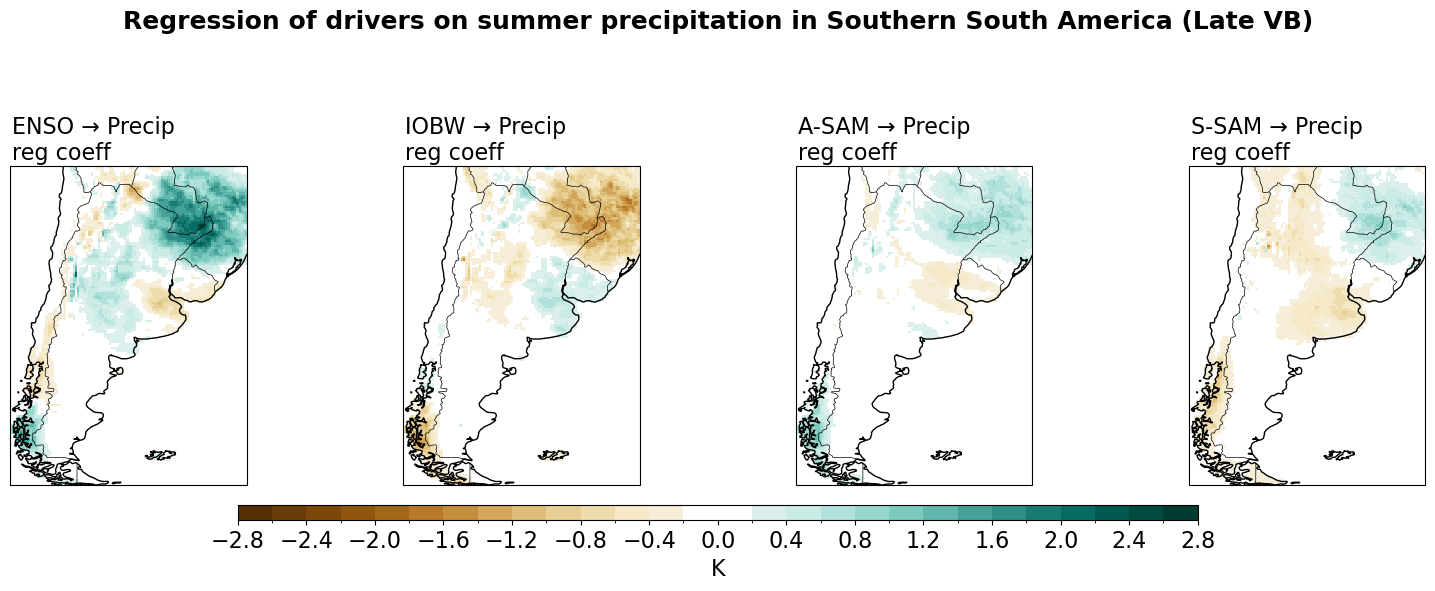

In [77]:
#print(result)
subplots_map(LP_summer_t_reg_old_late, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", \
                      f"A-SAM → T2m \nreg coeff", f"S-SAM → T2m \nreg coeff"], steps=.1,\
             heading='Regression of drivers on summer temperature in Southern South America Old (Late VB)')

subplots_map(LP_summer_pr_reg_old_late, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", \
                      f"A-SAM → Precip \nreg coeff", f"S-SAM → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG, steps=.2 ,heading='Regression of drivers on summer precipitation in Southern South America Old (Late VB)')
subplots_map(LP_summer_t_reg_late , [f"ENSO → T2m \nreg coeff", f"IOBW → T2m \nreg coeff", \
                      f"A-SAM → T2m \nreg coeff", f"S-SAM → T2m \nreg coeff"], steps=.1,\
             heading='Regression of drivers on summer temperature in Southern South America (Late VB)')

subplots_map(LP_summer_pr_reg_late, [f"ENSO → Precip \nreg coeff", f"IOBW → Precip \nreg coeff",  
                      f"A-SAM → Precip \nreg coeff", f"S-SAM → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG, steps=.2 ,heading='Regression of drivers on summer precipitation in Southern South America (Late VB)')

In [78]:
##total effect of temp and precip in LP
t_reg_LP_DJF_early_tot=conditioning_everything_fast(ds_DJF_early, ['ENSO', 'IOBW'], 't2m',total_eff=True)
pr_reg_LP_DJF_early_tot=conditioning_everything_fast(ds_DJF_early, ['ENSO', 'IOBW'], 'tp',total_eff=True)

t_reg_LP_DJF_early_tot_old=conditioning_everything_fast(ds_DJF_early, ['ENSO', 'IOD', 'SPV'], 't2m',total_eff=True)
pr_reg_LP_DJF_early_tot_old=conditioning_everything_fast(ds_DJF_early, ['ENSO', 'IOD', 'SPV'], 'tp',total_eff=True)

##total effect of temp and precip in LP
t_reg_LP_DJF_late_tot=conditioning_everything_fast(ds_DJF_late, ['ENSO', 'IOBW'], 't2m',total_eff=True)
pr_reg_LP_DJF_late_tot=conditioning_everything_fast(ds_DJF_late, ['ENSO', 'IOBW'], 'tp',total_eff=True)

t_reg_LP_DJF_late_tot_old=conditioning_everything_fast(ds_DJF_late, ['ENSO', 'IOD', 'SPV'], 't2m',total_eff=True)
pr_reg_LP_DJF_late_tot_old=conditioning_everything_fast(ds_DJF_late, ['ENSO', 'IOD', 'SPV'], 'tp',total_eff=True)

ENSO done
IOBW done
ENSO done
IOBW done
ENSO done
IOD done
SPV done
ENSO done
IOD done
SPV done
ENSO done
IOBW done
ENSO done
IOBW done
ENSO done
IOD done
SPV done
ENSO done
IOD done
SPV done


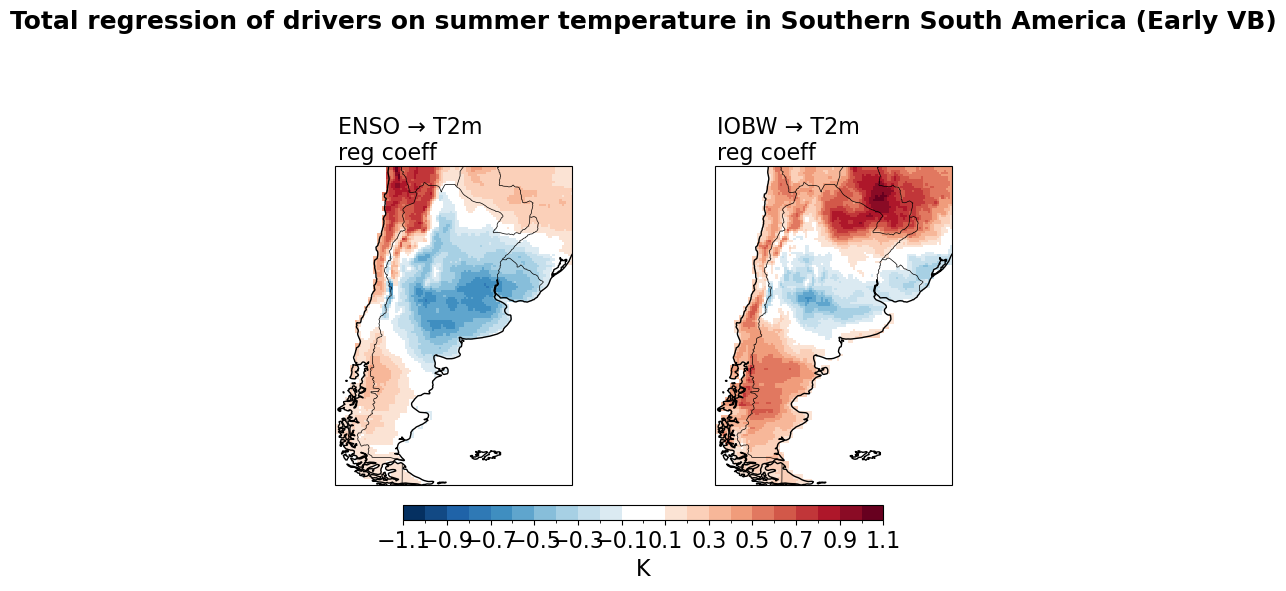

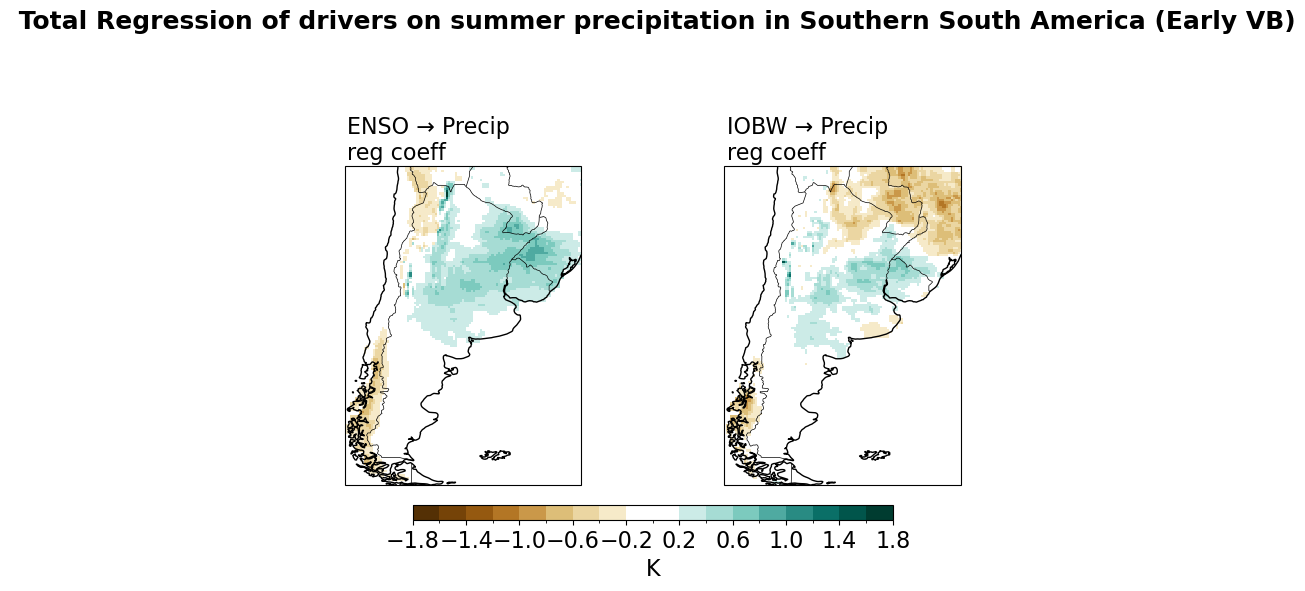

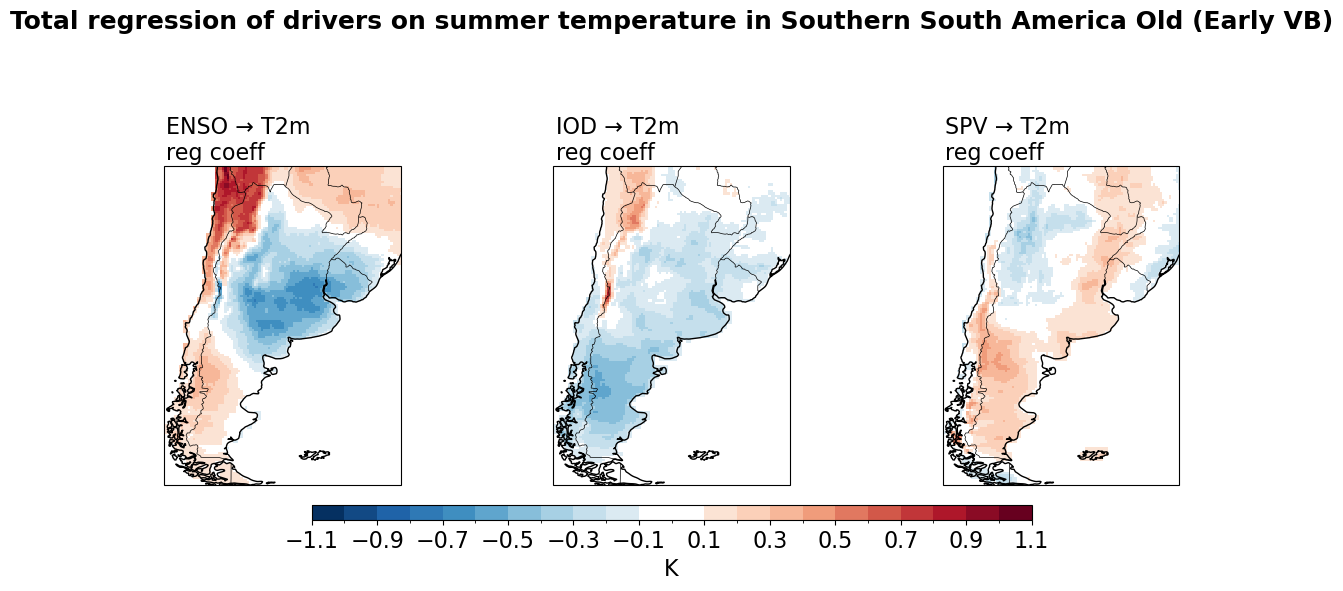

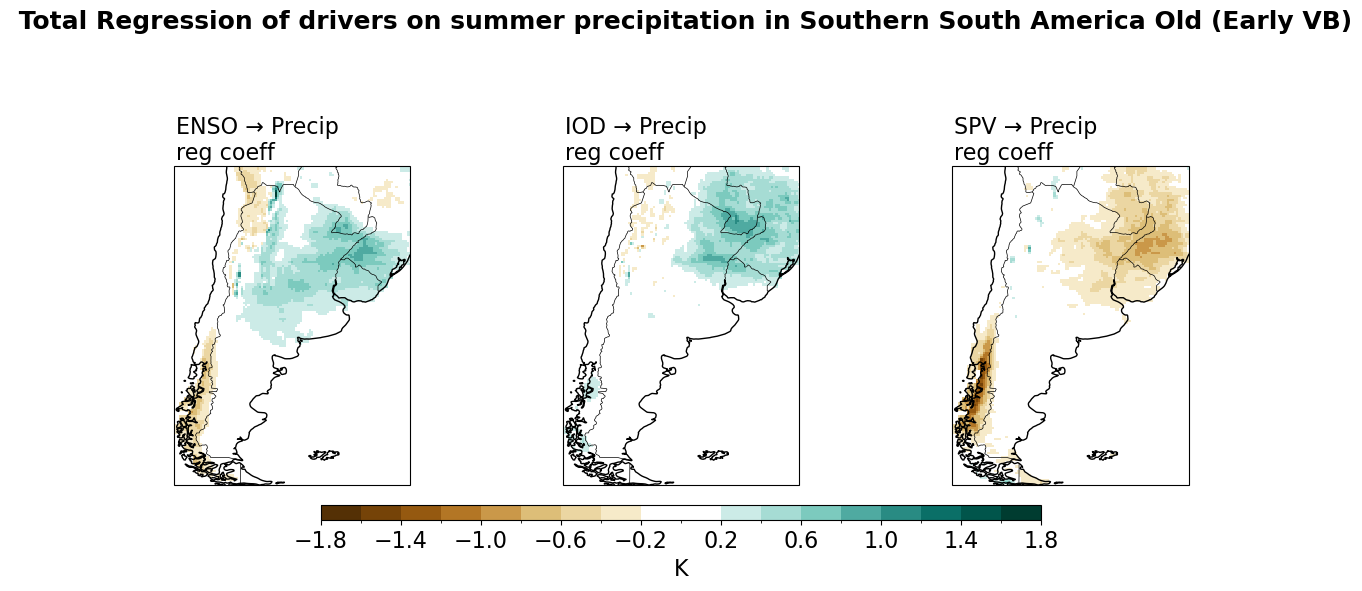

In [79]:
subplots_map(t_reg_LP_DJF_early_tot, [f"ENSO → T2m \nreg coeff", f"IOBW → T2m \nreg coeff" \
                      ], steps=.1,\
            heading='Total regression of drivers on summer temperature in Southern South America (Early VB)')
subplots_map(pr_reg_LP_DJF_early_tot, [f"ENSO → Precip \nreg coeff", f"IOBW → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG, steps=.2 ,heading=' Total Regression of drivers on summer precipitation in Southern South America (Early VB)')
subplots_map(t_reg_LP_DJF_early_tot_old, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", f"SPV → T2m \nreg coeff", \
                      ], steps=.1,\
            heading='Total regression of drivers on summer temperature in Southern South America Old (Early VB)')
subplots_map(pr_reg_LP_DJF_early_tot_old, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", f"SPV → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG, steps=.2 ,heading=' Total Regression of drivers on summer precipitation in Southern South America Old (Early VB)')

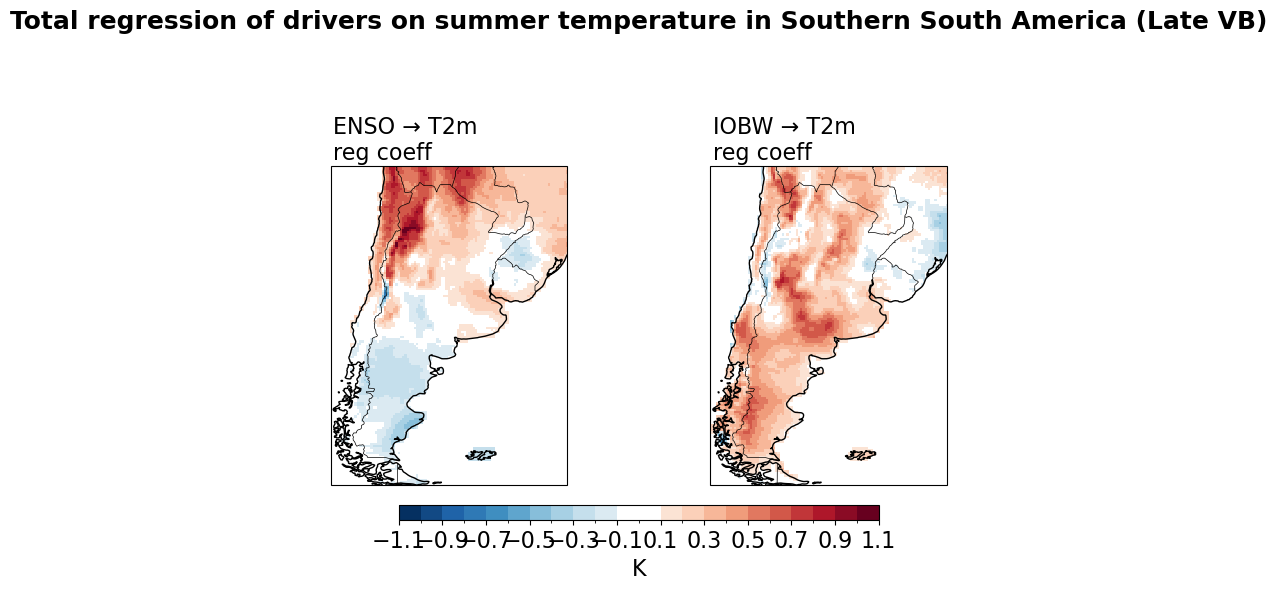

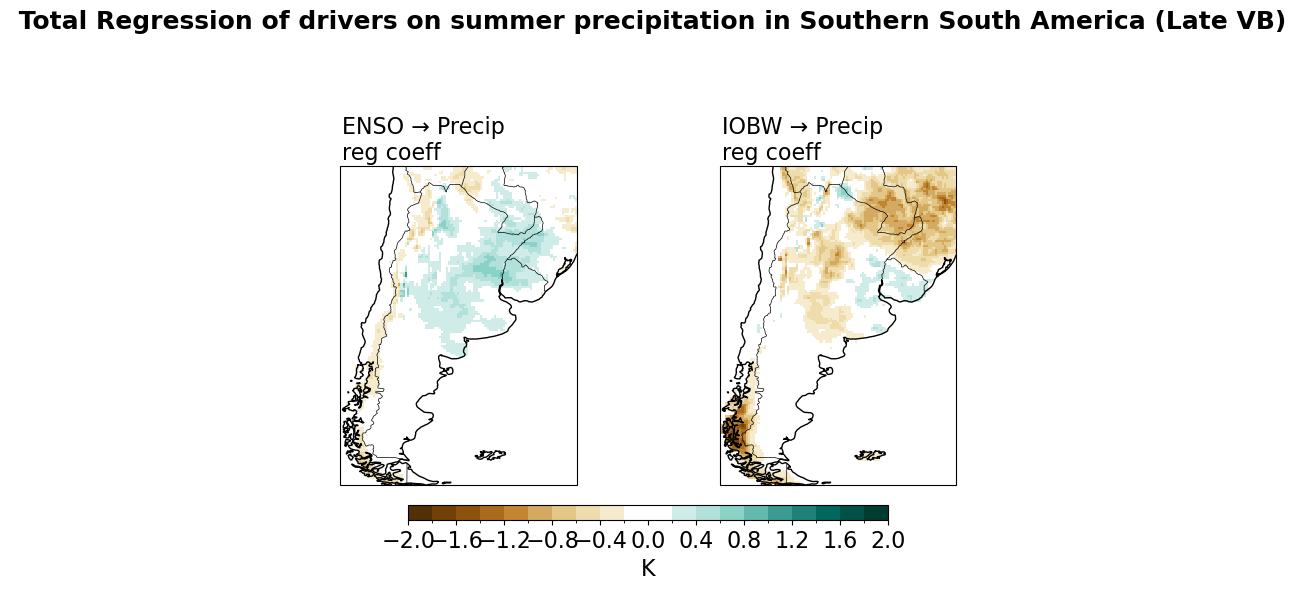

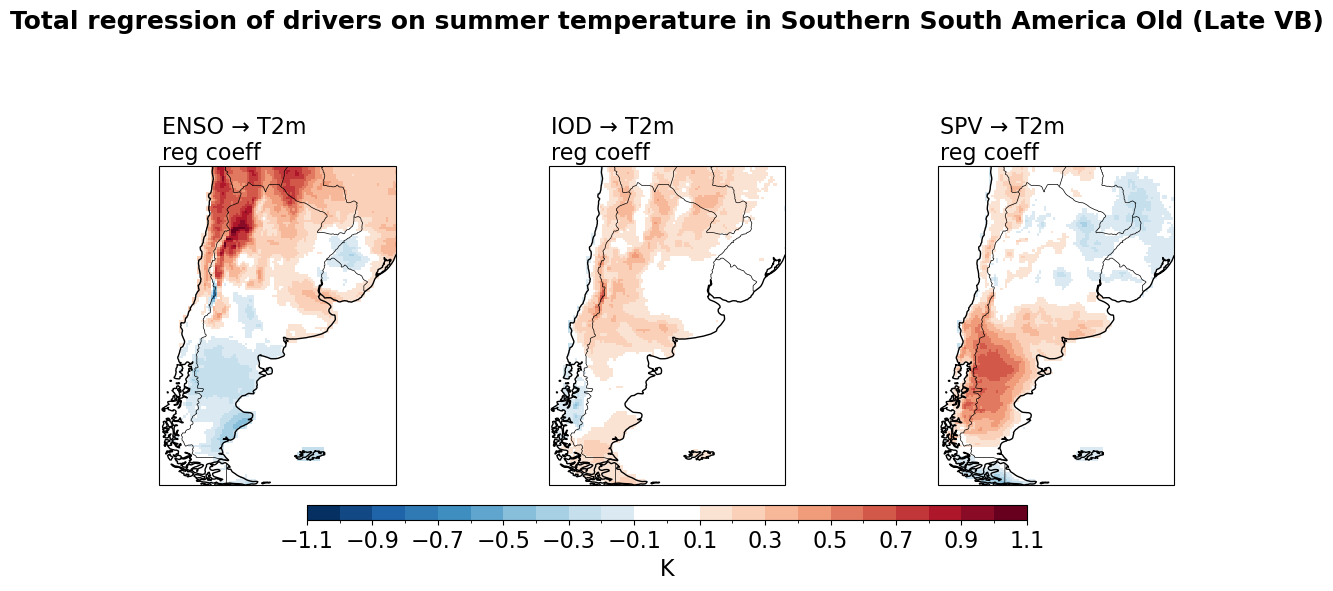

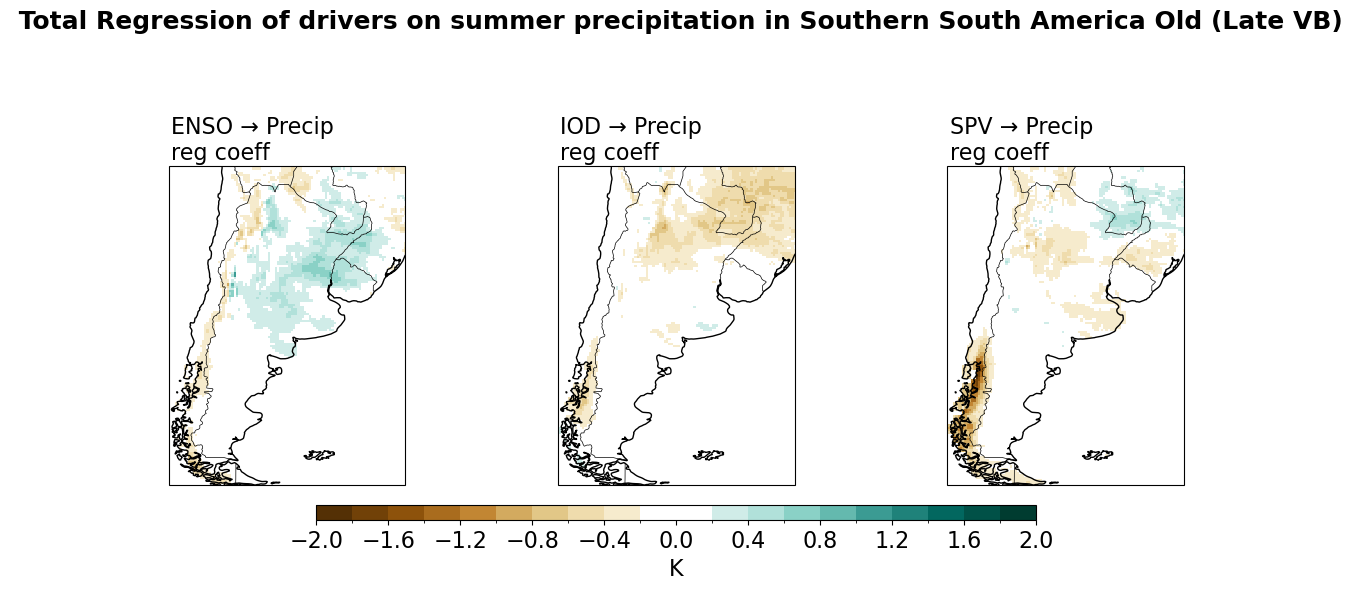

In [80]:
subplots_map(t_reg_LP_DJF_late_tot, [f"ENSO → T2m \nreg coeff", f"IOBW → T2m \nreg coeff" \
                      ], steps=.1,\
            heading='Total regression of drivers on summer temperature in Southern South America (Late VB)')
subplots_map(pr_reg_LP_DJF_late_tot, [f"ENSO → Precip \nreg coeff", f"IOBW → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG, steps=.2 ,heading=' Total Regression of drivers on summer precipitation in Southern South America (Late VB)')
subplots_map(t_reg_LP_DJF_late_tot_old, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", f"SPV → T2m \nreg coeff", \
                      ], steps=.1,\
            heading='Total regression of drivers on summer temperature in Southern South America Old (Late VB)')
subplots_map(pr_reg_LP_DJF_late_tot_old, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", f"SPV → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG, steps=.2 ,heading=' Total Regression of drivers on summer precipitation in Southern South America Old (Late VB)')

Investigate links between drivers for two time periods

In [82]:
ENSO_IOD_early=lin_model_fast(ds_early_SON['IOD'], ds_early_SON['ENSO'])
print(ENSO_IOD_early)
ENSO_IOD_late=lin_model_fast(ds_late_SON['IOD'], ds_late_SON['ENSO'])
print(ENSO_IOD_late)
ENSO_IOD=lin_model_fast(ds_SON['IOD'], ds_SON['ENSO'])
print(ENSO_IOD)
print('\n')
print('A-SAM link:')
A_SAM_link_early=conditioning_everything_fast(ds_early_SON_sep, ['ENSO', 'IOD'], 'A_SAM')
print(A_SAM_link_early)
A_SAM_link_late=conditioning_everything_fast(ds_late_SON_sep, ['ENSO', 'IOD'], 'A_SAM')
print(A_SAM_link_late)
A_SAM_link=conditioning_everything_fast(ds_SON, ['ENSO', 'IOD'], 'A_SAM')
print(A_SAM_link)
print('\n' )
print('S-SAM link:')
S_SAM_link_early=conditioning_everything_fast(ds_early_SON_sep, ['ENSO', 'IOD', 'SPV'], 'S_SAM')
print(S_SAM_link_early)
S_SAM_link_late=conditioning_everything_fast(ds_late_SON_sep, ['ENSO', 'IOD', 'SPV'], 'S_SAM')
print(S_SAM_link_late)
S_SAM_link=conditioning_everything_fast(ds_SON, ['ENSO', 'IOD', 'SPV'], 'S_SAM')
print(S_SAM_link)
print('\n')
print('SPV link:')
SPV_link_early=conditioning_everything_fast(ds_early_SON_sep, ['ENSO', 'IOD'], 'SPV')
print(SPV_link_early)
SPV_link_late=conditioning_everything_fast(ds_late_SON_sep, ['ENSO', 'IOD'], 'SPV')
print(SPV_link_late)
SPV_link=conditioning_everything_fast(ds_SON, ['ENSO', 'IOD'],  'SPV')
print(SPV_link)

<xarray.DataArray 'IOD' ()> Size: 8B
array(0.61577725)
Coordinates:
    year     int64 8B 1951
<xarray.DataArray 'IOD' ()> Size: 8B
array(0.49795054)
Coordinates:
    year     int64 8B 1953
<xarray.DataArray 'IOD' ()> Size: 8B
array(0.55065439)
Coordinates:
    year     int64 8B 1951


A-SAM link:
ENSO done
IOD done
[<xarray.DataArray ()> Size: 8B
array(-0.43807504), <xarray.DataArray ()> Size: 8B
array(-0.15353973)]
ENSO done
IOD done
[<xarray.DataArray ()> Size: 8B
array(-0.56360692), <xarray.DataArray ()> Size: 8B
array(-0.2486469)]
ENSO done
IOD done
[<xarray.DataArray ()> Size: 8B
array(-0.5711812), <xarray.DataArray ()> Size: 8B
array(-0.25404293)]


S-SAM link:
ENSO done
IOD done
SPV done
[<xarray.DataArray ()> Size: 8B
array(-0.0815575), <xarray.DataArray ()> Size: 8B
array(-0.02685283), <xarray.DataArray ()> Size: 8B
array(0.78689097)]
ENSO done
IOD done
SPV done
[<xarray.DataArray ()> Size: 8B
array(-0.04947697), <xarray.DataArray ()> Size: 8B
array(-0.07643526), <xarray.Data

In [83]:
##DJF
ENSO_IOD_early=lin_model_fast(ds_DJF_early['IOD'], ds_DJF_early['ENSO'])
print(ENSO_IOD_early)
ENSO_IOD_late=lin_model_fast(ds_DJF_late['IOD'], ds_DJF_late['ENSO'])
print(ENSO_IOD_late)
ENSO_IOD=lin_model_fast(ds_DJF['IOD'], ds_DJF['ENSO'])
print(ENSO_IOD)
print('\n')
print('A-SAM link:')
A_SAM_link_early=conditioning_everything_fast(ds_DJF_early, ['ENSO', 'IOD'], 'A_SAM')
print(A_SAM_link_early)
A_SAM_link_late=conditioning_everything_fast(ds_DJF_late, ['ENSO', 'IOD'], 'A_SAM')
print(A_SAM_link_late)
A_SAM_link=conditioning_everything_fast(ds_DJF , ['ENSO', 'IOD'], 'A_SAM')
print(A_SAM_link)
print('\n' )
print('S-SAM link:')
S_SAM_link_early=conditioning_everything_fast(ds_DJF_early, ['ENSO', 'IOD', 'SPV'], 'S_SAM')
print(S_SAM_link_early)
S_SAM_link_late=conditioning_everything_fast(ds_DJF_late, ['ENSO', 'IOD', 'SPV'], 'S_SAM')
print(S_SAM_link_late)
S_SAM_link=conditioning_everything_fast(ds_DJF, ['ENSO', 'IOD', 'SPV'], 'S_SAM')
print(S_SAM_link)
print('\n')
print('SPV link:')
SPV_link_early=conditioning_everything_fast(ds_DJF_early, ['ENSO', 'IOD'], 'SPV')
print(SPV_link_early)
SPV_link_late=conditioning_everything_fast(ds_DJF_late, ['ENSO', 'IOD'], 'SPV')
print(SPV_link_late)
SPV_link=conditioning_everything_fast(ds_DJF, ['ENSO', 'IOD'],  'SPV')
print(SPV_link)

<xarray.DataArray 'IOD' ()> Size: 8B
array(0.04719169)
Coordinates:
    year     int64 8B 1951
<xarray.DataArray 'IOD' ()> Size: 8B
array(0.30564245)
Coordinates:
    year     int64 8B 1953
<xarray.DataArray 'IOD' ()> Size: 8B
array(0.1333889)
Coordinates:
    year     int64 8B 1951


A-SAM link:
ENSO done
IOD done
[<xarray.DataArray ()> Size: 8B
array(-0.39978523), <xarray.DataArray ()> Size: 8B
array(0.19115556)]
ENSO done
IOD done
[<xarray.DataArray ()> Size: 8B
array(-0.49292687), <xarray.DataArray ()> Size: 8B
array(-0.0869936)]
ENSO done
IOD done
[<xarray.DataArray ()> Size: 8B
array(-0.443208), <xarray.DataArray ()> Size: 8B
array(0.04121158)]


S-SAM link:
ENSO done
IOD done
SPV done
[<xarray.DataArray ()> Size: 8B
array(-0.16040352), <xarray.DataArray ()> Size: 8B
array(0.05907811), <xarray.DataArray ()> Size: 8B
array(0.71089365)]
ENSO done
IOD done
SPV done
[<xarray.DataArray ()> Size: 8B
array(-0.10562277), <xarray.DataArray ()> Size: 8B
array(0.03700237), <xarray.DataArray

In [84]:
ENSO_IOBW_early=lin_model_fast(ds_early_DJF_sep['IOBW'], ds_early_DJF_sep['ENSO'])
print(ENSO_IOBW_early)
ENSO_IOBW_late=lin_model_fast(ds_late_DJF_sep['IOBW'], ds_late_DJF_sep['ENSO'])
print(ENSO_IOBW_late)
ENSO_IOBW=lin_model_fast(ds_DJF['IOBW'], ds_DJF['ENSO'])
print(ENSO_IOBW)    

print('\n A-SAM')
A_SAM_link_early=conditioning_everything_fast(ds_early_DJF_sep, ['ENSO', 'IOBW'], 'A_SAM')
print(A_SAM_link_early)
A_SAM_link_late=conditioning_everything_fast(ds_late_DJF_sep, ['ENSO', 'IOBW'], 'A_SAM')
print(A_SAM_link_late)
A_SAM_link=conditioning_everything_fast(ds_DJF , ['ENSO', 'IOBW'], 'A_SAM')
print(A_SAM_link)   

print('\n S-SAM')
S_SAM_link_early=conditioning_everything_fast(ds_early_DJF_sep, ['ENSO', 'IOBW'], 'S_SAM')
print(S_SAM_link_early)
S_SAM_link_late=conditioning_everything_fast(ds_late_DJF_sep, ['ENSO', 'IOBW'], 'S_SAM')
print(S_SAM_link_late)
S_SAM_link=conditioning_everything_fast(ds_DJF, ['ENSO', 'IOBW'], 'S_SAM')
print(S_SAM_link)


<xarray.DataArray 'IOBW' ()> Size: 8B
array(0.75481003)
Coordinates:
    year     int64 8B 1951
<xarray.DataArray 'IOBW' ()> Size: 8B
array(0.92037201)
Coordinates:
    year     int64 8B 1953
<xarray.DataArray 'IOBW' ()> Size: 8B
array(0.80834705)
Coordinates:
    year     int64 8B 1951

 A-SAM
ENSO done
IOBW done
[<xarray.DataArray ()> Size: 8B
array(-0.43316433), <xarray.DataArray ()> Size: 8B
array(-0.03601035)]
ENSO done
IOBW done
[<xarray.DataArray ()> Size: 8B
array(-0.53093138), <xarray.DataArray ()> Size: 8B
array(0.154646)]
ENSO done
IOBW done
[<xarray.DataArray ()> Size: 8B
array(-0.3738396), <xarray.DataArray ()> Size: 8B
array(-0.07901461)]

 S-SAM
ENSO done
IOBW done
[<xarray.DataArray ()> Size: 8B
array(-0.52348363), <xarray.DataArray ()> Size: 8B
array(0.31238986)]
ENSO done
IOBW done
[<xarray.DataArray ()> Size: 8B
array(-0.6495932), <xarray.DataArray ()> Size: 8B
array(0.57235064)]
ENSO done
IOBW done
[<xarray.DataArray ()> Size: 8B
array(-0.50297447), <xarray.DataArra

Plot everything with the global maximum colorbar

In [85]:
t_reg_list=[result_early,result_late, t_reg_LP_SON_early_tot, t_reg_LP_SON_late_tot, \
            t_reg_LP_DJF_early_tot, t_reg_LP_DJF_late_tot, t_reg_LP_DJF_late_tot_old, t_reg_LP_DJF_early_tot_old,\
                LP_summer_t_reg_early, LP_summer_t_reg_late, LP_summer_t_reg_old_early, LP_summer_t_reg_old_late]
pr_reg_list=[pr_reg_LP_SON_early, pr_reg_LP_SON_late,\
              pr_reg_LP_SON_early_tot, pr_reg_LP_SON_late_tot,\
             pr_reg_LP_DJF_early_tot, pr_reg_LP_DJF_early_tot_old,pr_reg_LP_DJF_late_tot, pr_reg_LP_DJF_late_tot_old,\
                  LP_summer_pr_reg_early, LP_summer_pr_reg_late, LP_summer_pr_reg_old_early, LP_summer_pr_reg_old_late]
global_max_t=np.max([np.nanmax(np.abs(m)) for m in t_reg_list ])
global_max_pr=np.max([np.nanmax(np.abs(m)) for m in pr_reg_list ])
print(global_max_t, global_max_pr)

1.6577180969907355 2.6179258453941086


Direct effects spring

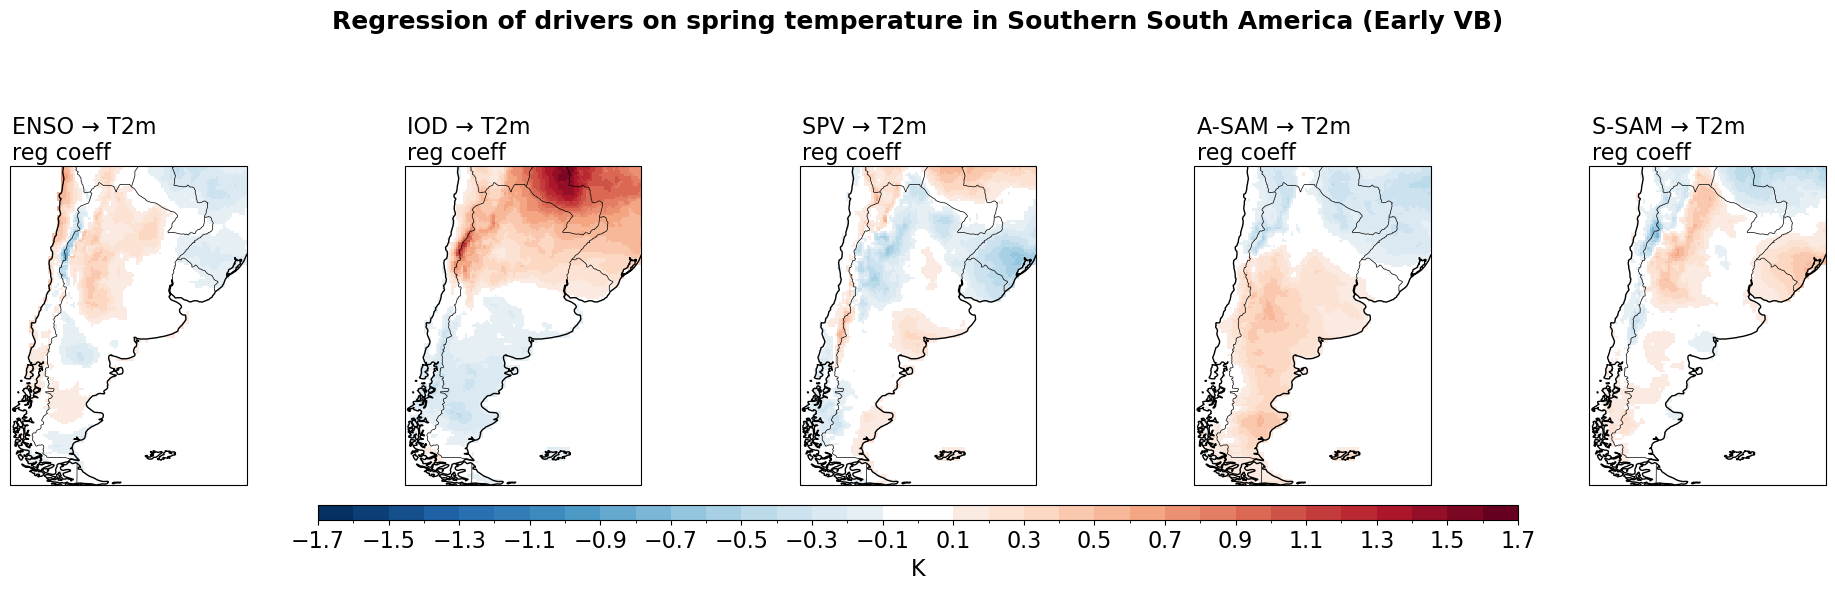

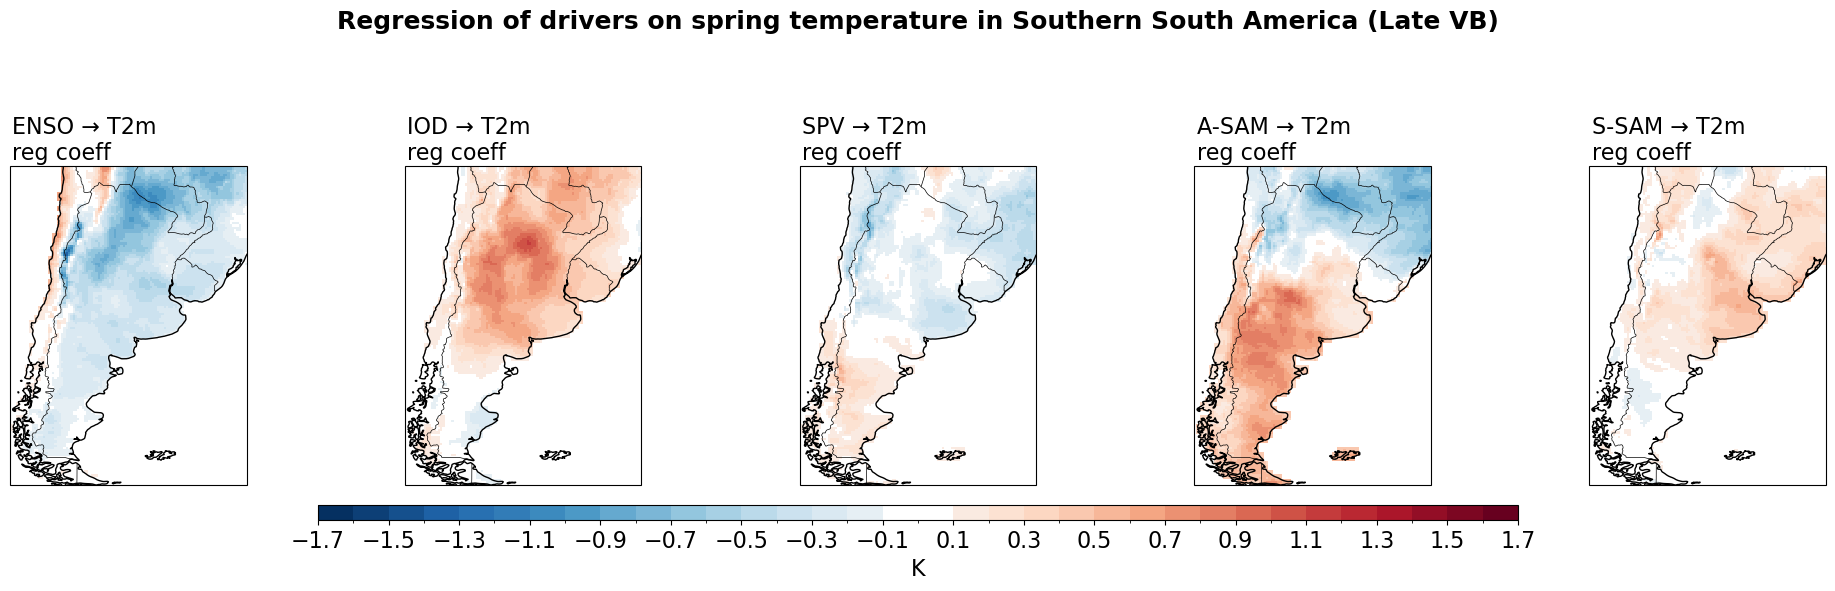

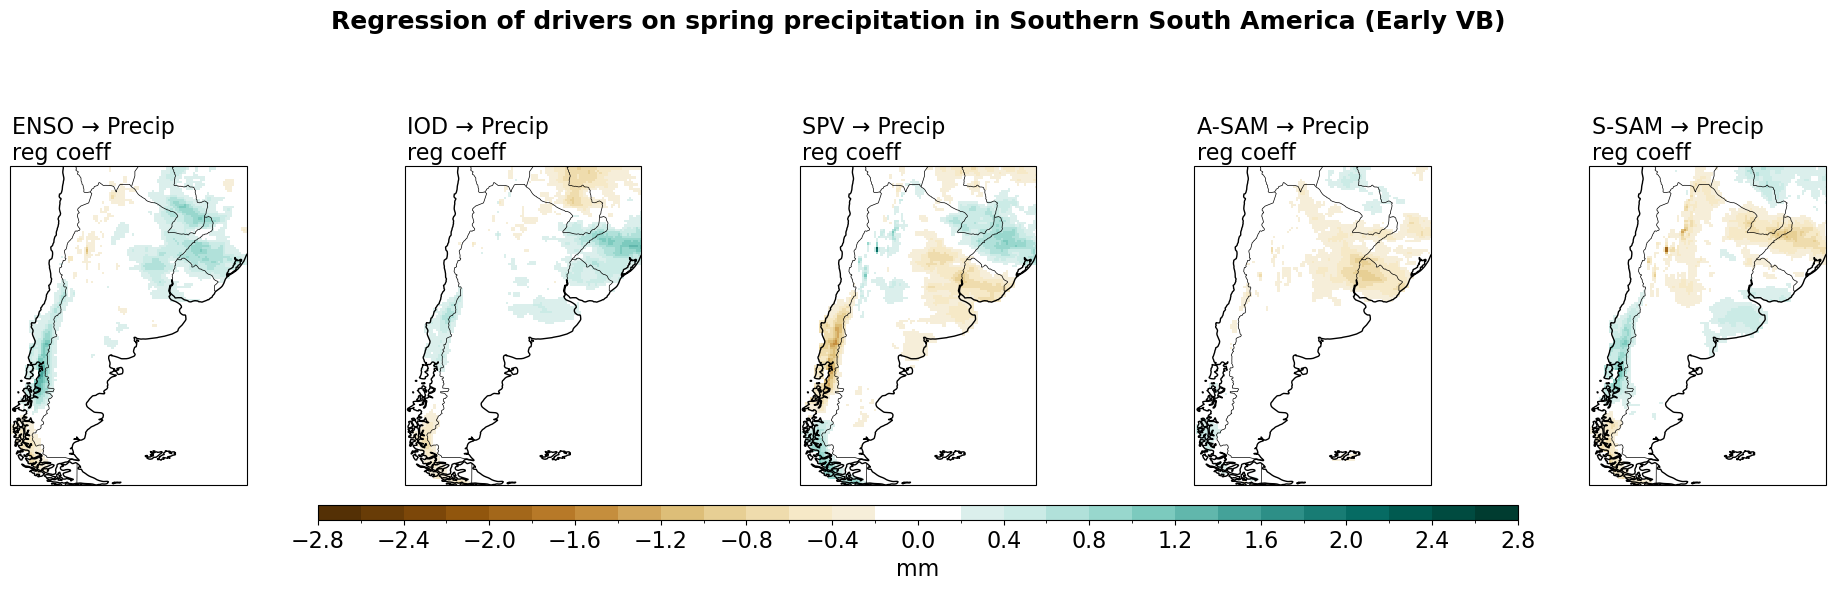

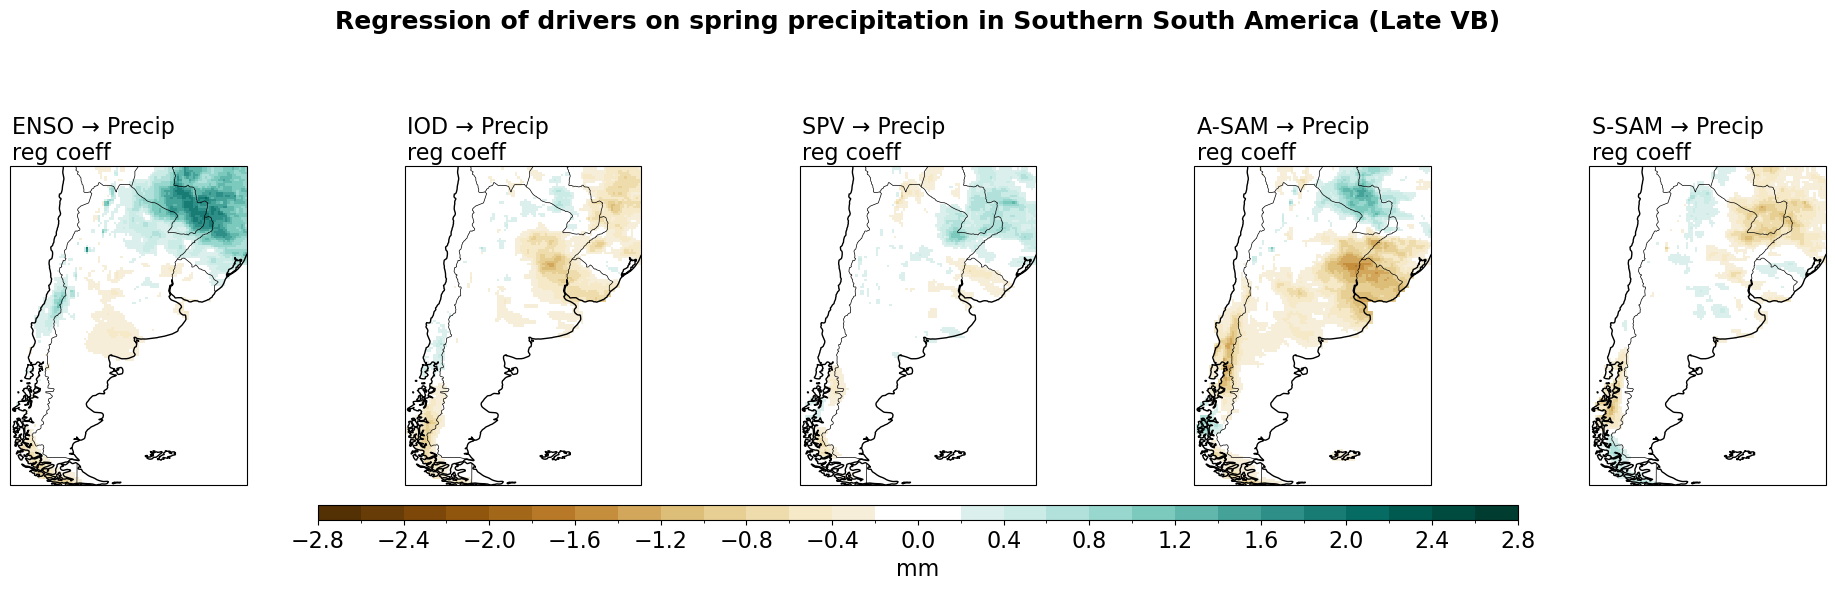

In [93]:
subplots_map(result_early, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", f"SPV → T2m \nreg coeff", \
                      f"A-SAM → T2m \nreg coeff", f"S-SAM → T2m \nreg coeff"],steps=.1,\
                          heading='Regression of drivers on spring temperature in Southern South America (Early VB)', global_max_val=global_max_t)
subplots_map(result_late, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", f"SPV → T2m \nreg coeff", \
                      f"A-SAM → T2m \nreg coeff", f"S-SAM → T2m \nreg coeff"],steps=.1,\
                          heading='Regression of drivers on spring temperature in Southern South America (Late VB)', global_max_val=global_max_t)
subplots_map(pr_reg_LP_SON_early, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", f"SPV → Precip \nreg coeff", \
                      f"A-SAM → Precip \nreg coeff", f"S-SAM → Precip \nreg coeff"], steps=.2,\
             cmap=plt.cm.BrBG ,heading='Regression of drivers on spring precipitation in Southern South America (Early VB)', global_max_val=global_max_pr, unit='mm')
subplots_map(pr_reg_LP_SON_late, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", f"SPV → Precip \nreg coeff", \
                      f"A-SAM → Precip \nreg coeff", f"S-SAM → Precip \nreg coeff"], steps=.2,\
             cmap=plt.cm.BrBG ,heading='Regression of drivers on spring precipitation in Southern South America (Late VB)', global_max_val=global_max_pr, unit='mm') 


Total effects spring

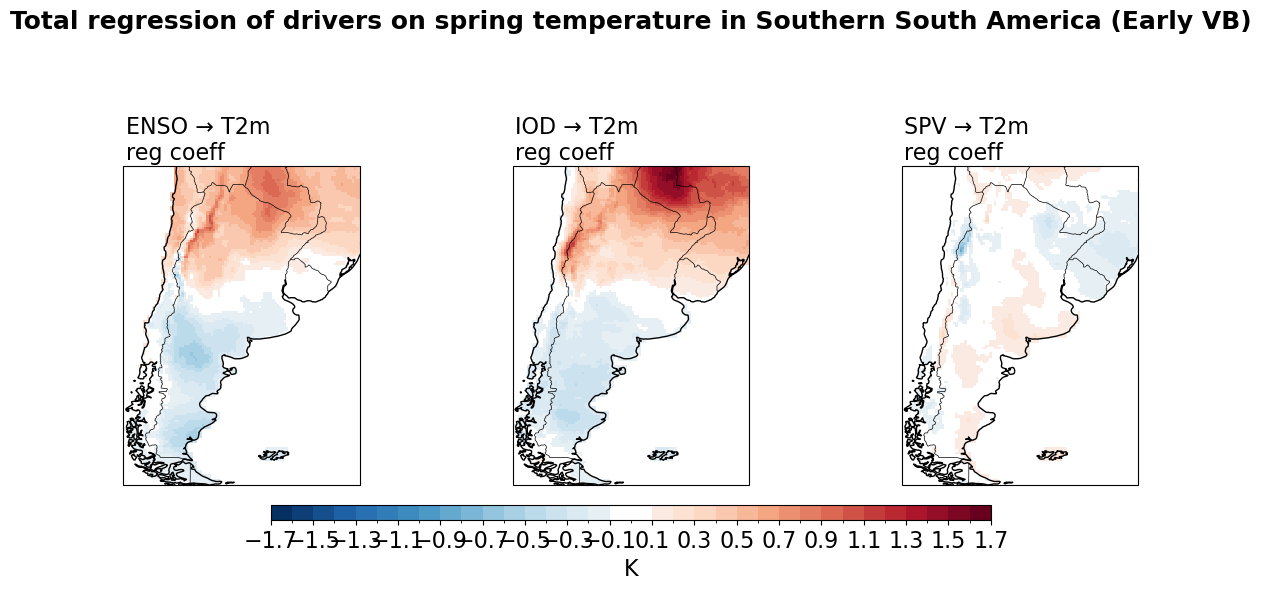

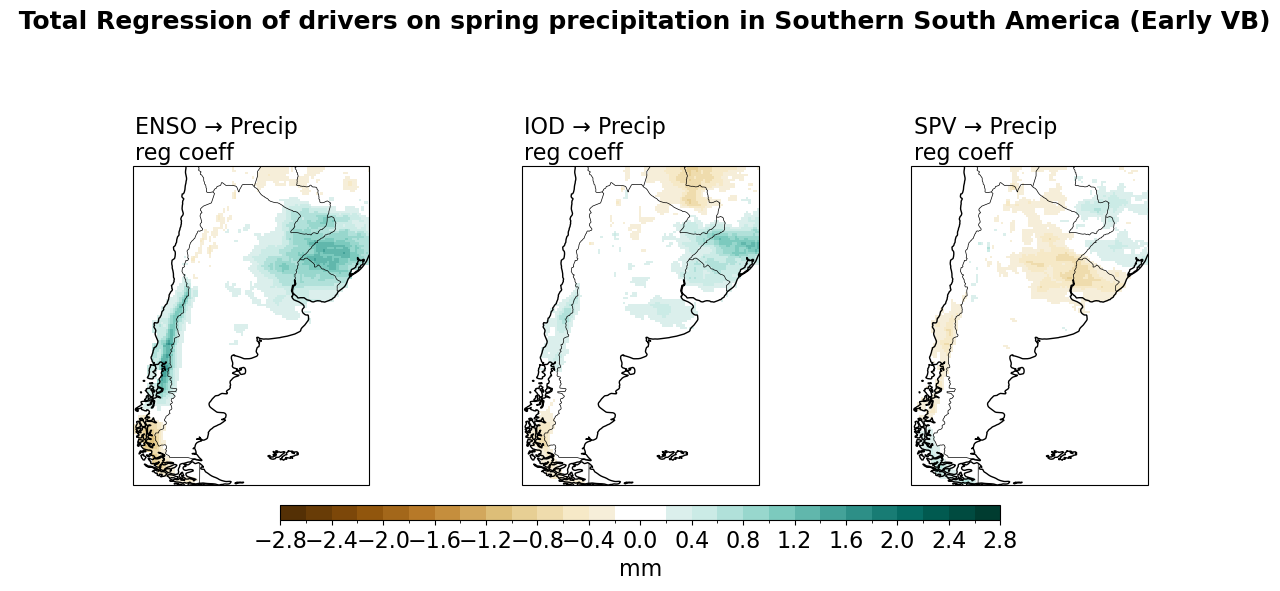

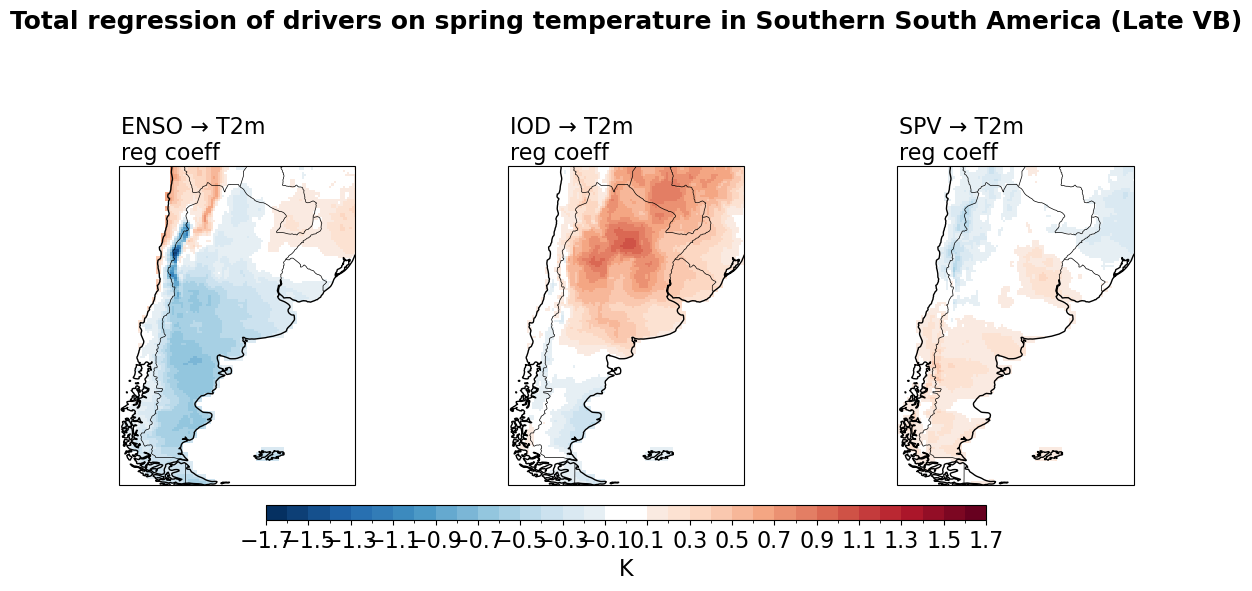

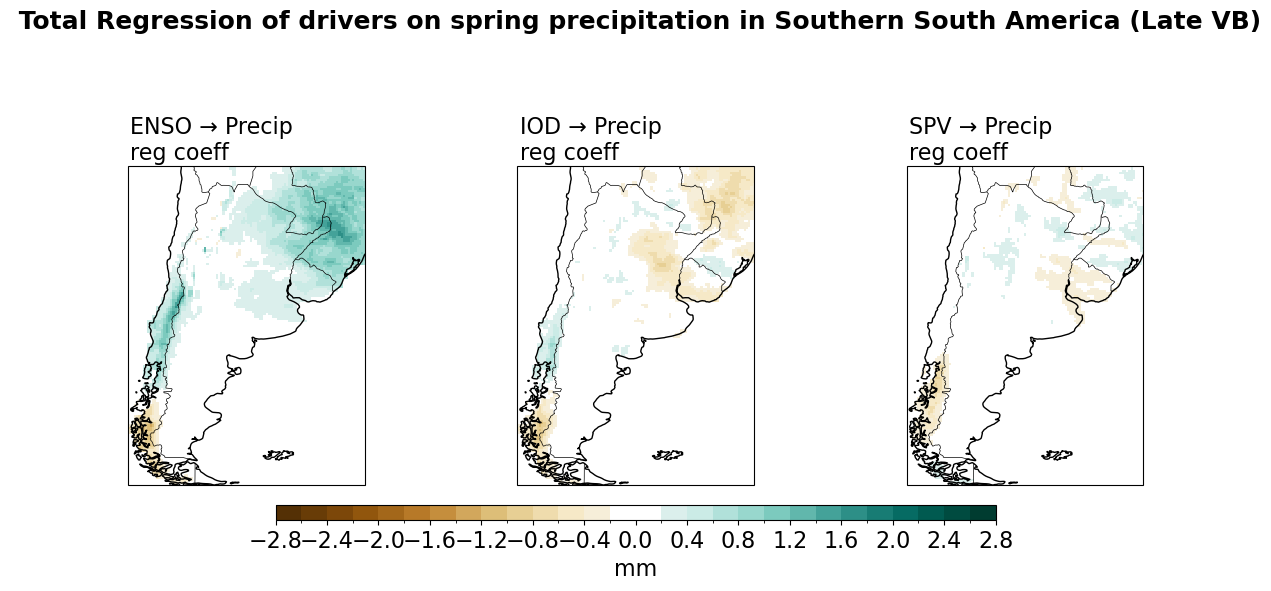

In [92]:
subplots_map(t_reg_LP_SON_early_tot, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", f"SPV → T2m \nreg coeff", \
                      ], steps=.1, heading='Total regression of drivers on spring temperature in Southern South America (Early VB)', global_max_val=global_max_t)
subplots_map(pr_reg_LP_SON_early_tot, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", f"SPV → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG, steps=.2 ,heading=' Total Regression of drivers on spring precipitation in Southern South America (Early VB)', global_max_val=global_max_pr, unit='mm')
subplots_map(t_reg_LP_SON_late_tot, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", f"SPV → T2m \nreg coeff", \
                      ], steps=.1, heading='Total regression of drivers on spring temperature in Southern South America (Late VB)', global_max_val=global_max_t)
subplots_map(pr_reg_LP_SON_late_tot, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", f"SPV → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG, steps=.2 ,heading=' Total Regression of drivers on spring precipitation in Southern South America (Late VB)', global_max_val=global_max_pr, unit='mm')

Direct effects summer

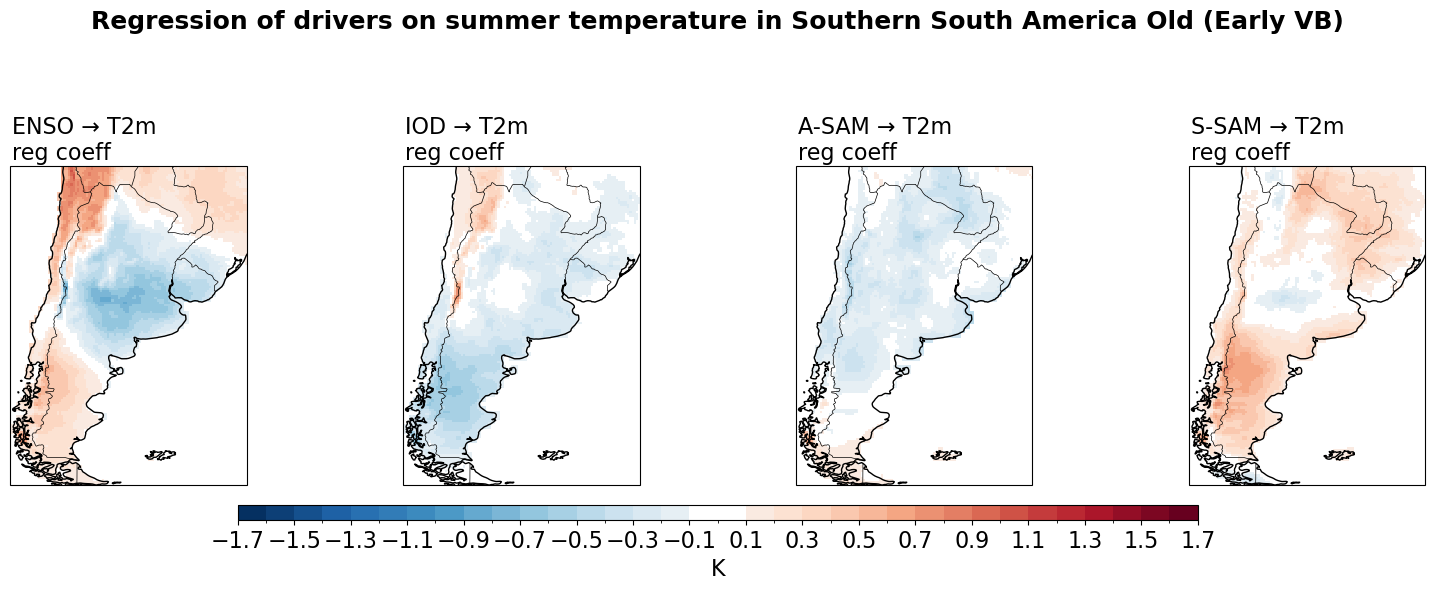

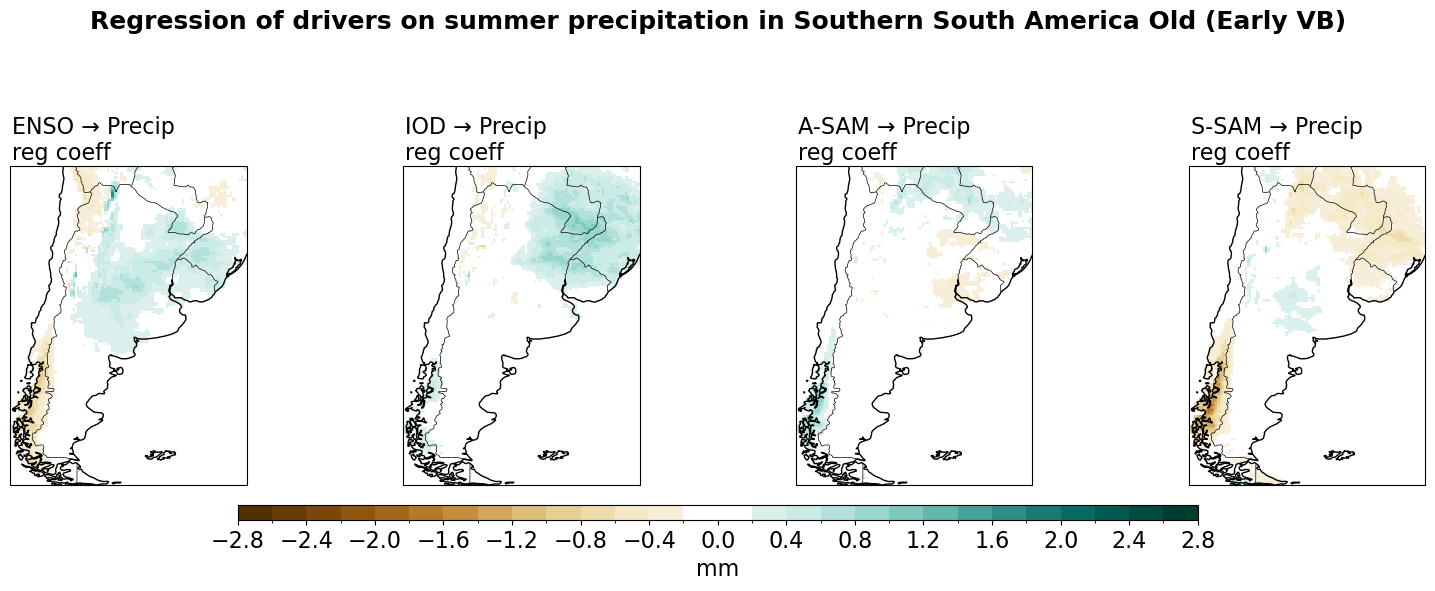

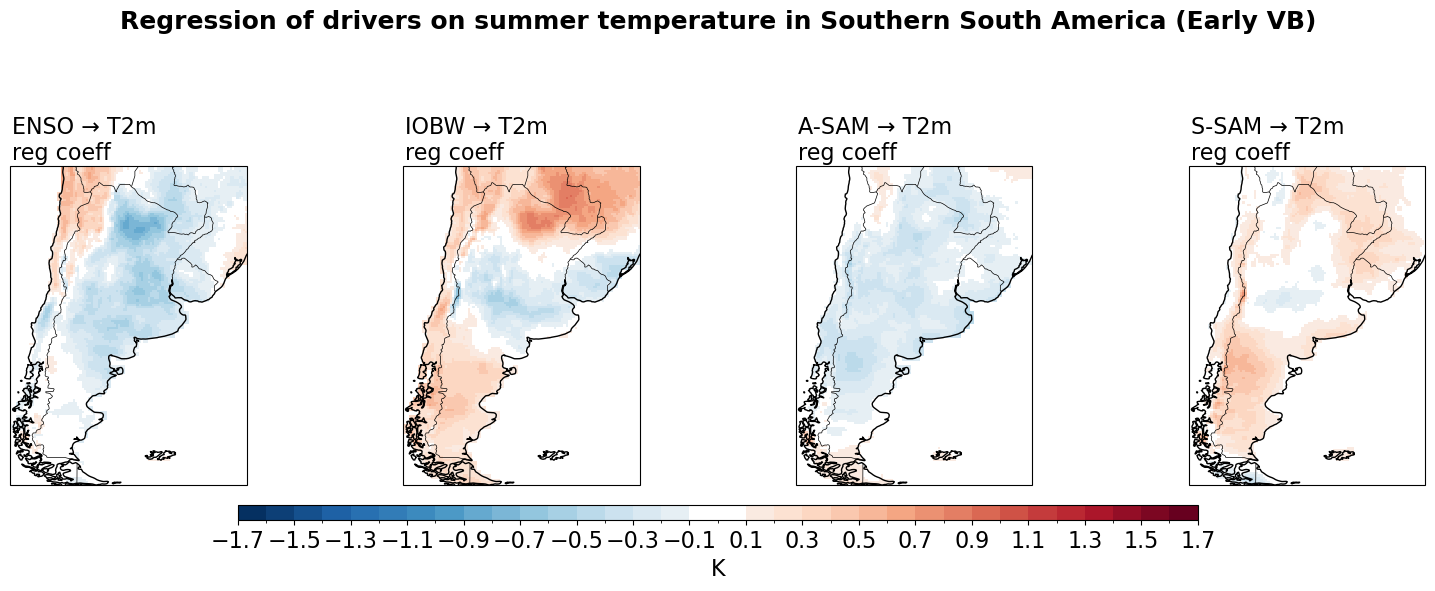

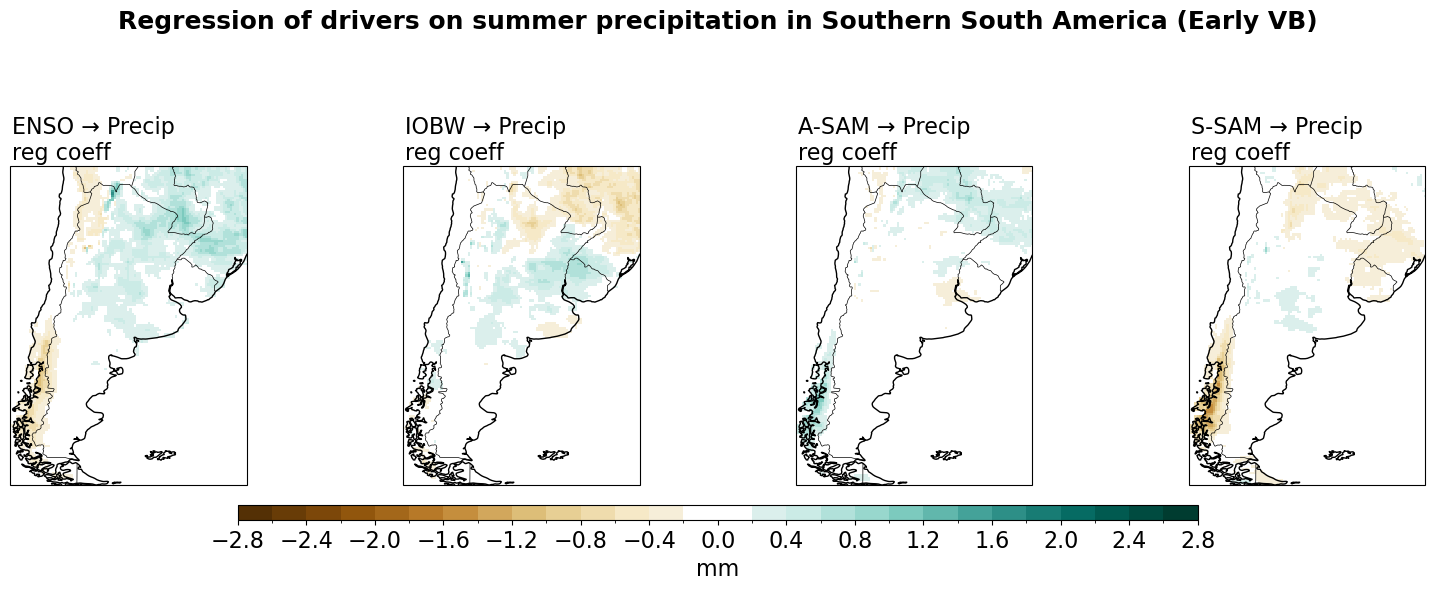

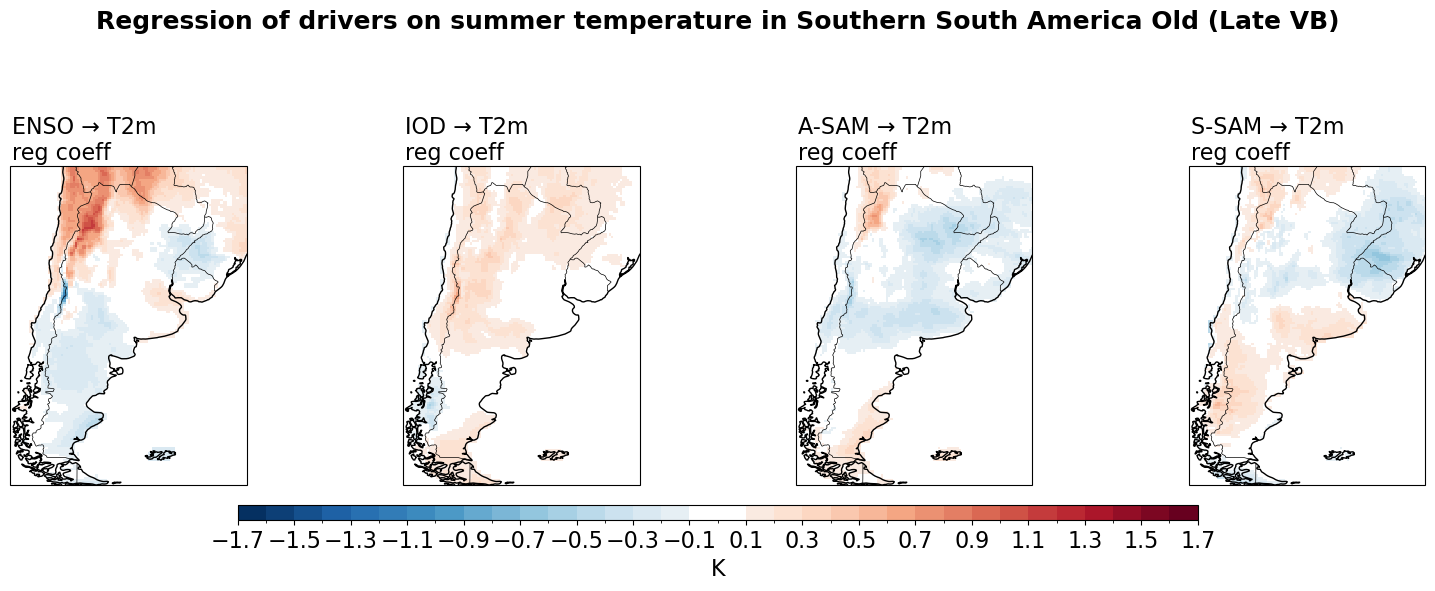

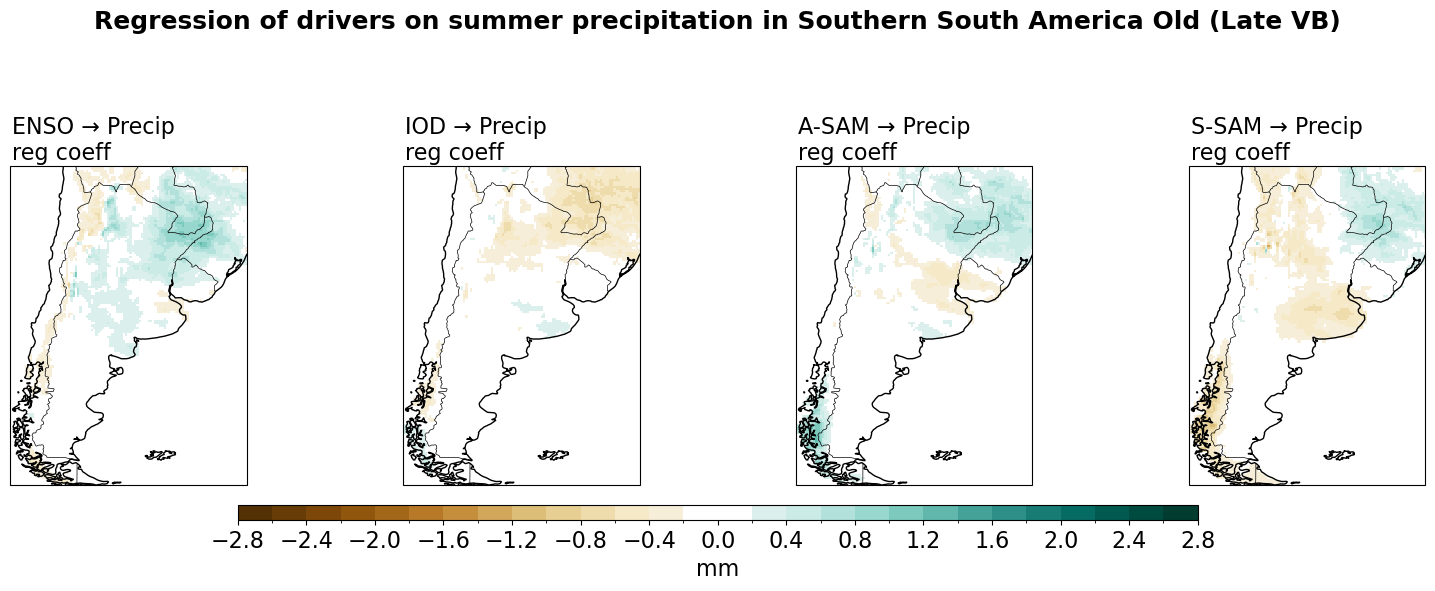

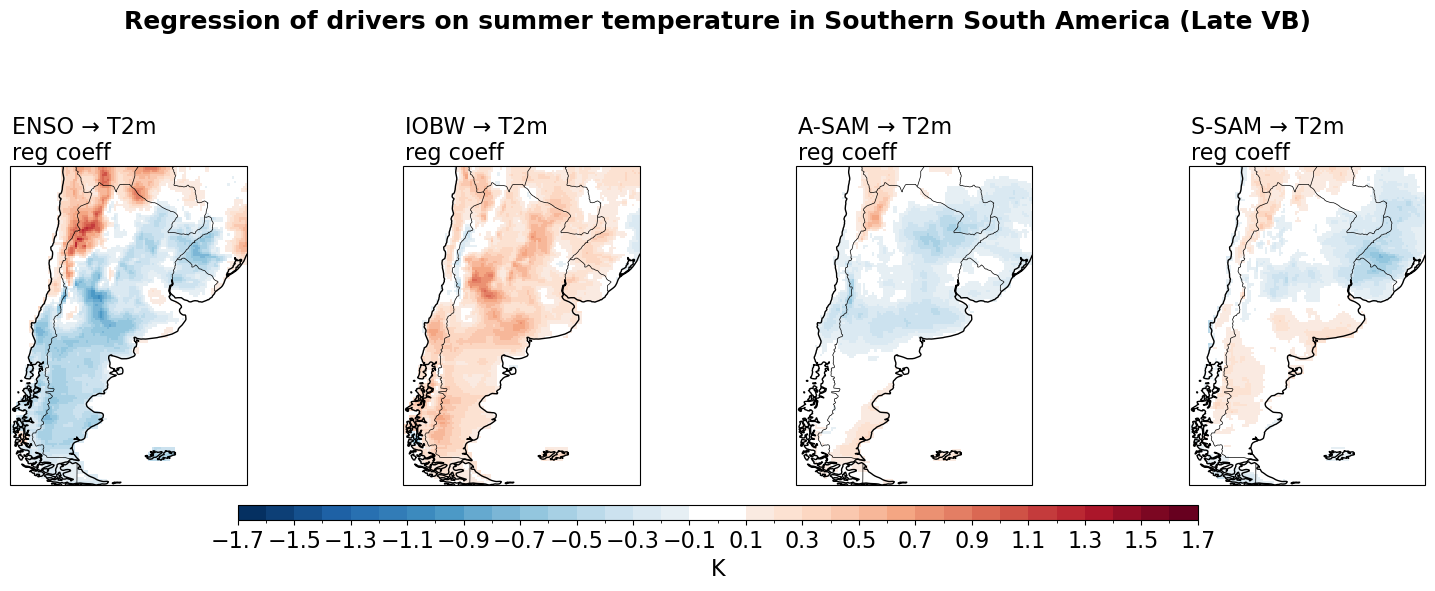

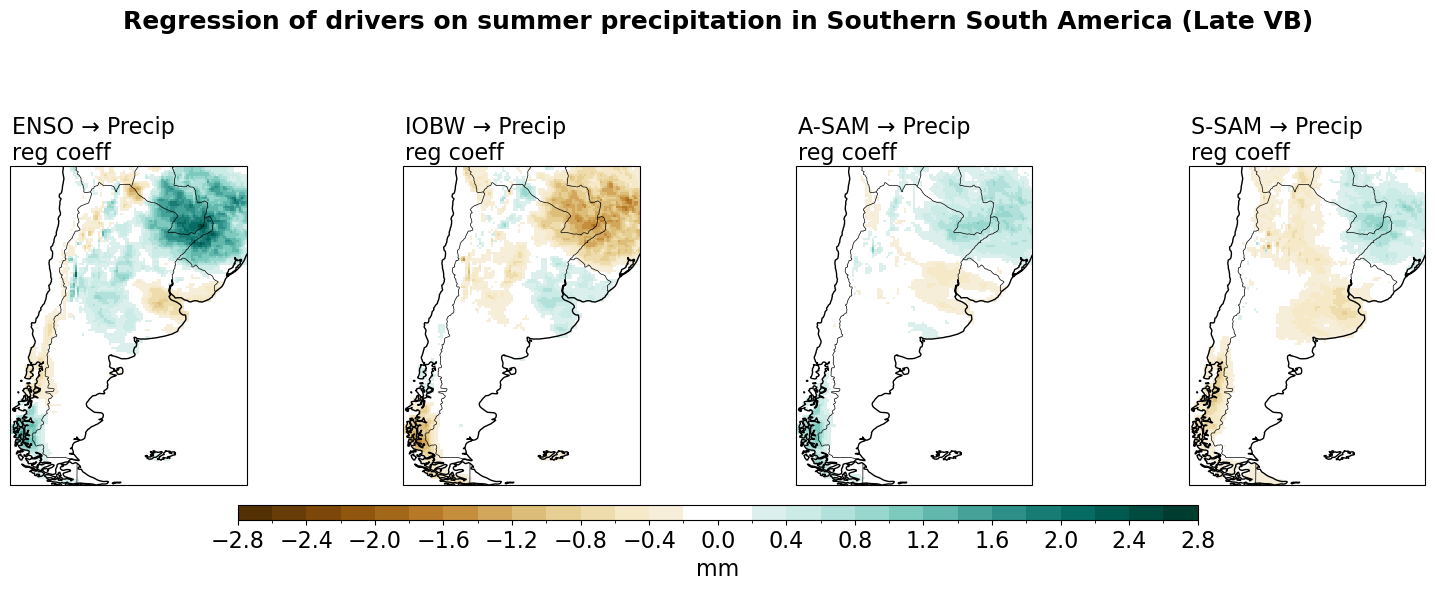

In [91]:
#print(result)
subplots_map(LP_summer_t_reg_old_early, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", \
                      f"A-SAM → T2m \nreg coeff", f"S-SAM → T2m \nreg coeff"], steps=.1,\
             heading='Regression of drivers on summer temperature in Southern South America Old (Early VB)', global_max_val=global_max_t)

subplots_map(LP_summer_pr_reg_old_early, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", \
                      f"A-SAM → Precip \nreg coeff", f"S-SAM → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG, steps=.2 ,heading='Regression of drivers on summer precipitation in Southern South America Old (Early VB)', global_max_val=global_max_pr, unit='mm')
subplots_map(LP_summer_t_reg_early , [f"ENSO → T2m \nreg coeff", f"IOBW → T2m \nreg coeff", \
                      f"A-SAM → T2m \nreg coeff", f"S-SAM → T2m \nreg coeff"], steps=.1,\
             heading='Regression of drivers on summer temperature in Southern South America (Early VB)', global_max_val=global_max_t)

subplots_map(LP_summer_pr_reg_early, [f"ENSO → Precip \nreg coeff", f"IOBW → Precip \nreg coeff",  
                      f"A-SAM → Precip \nreg coeff", f"S-SAM → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG, steps=.2 ,heading='Regression of drivers on summer precipitation in Southern South America (Early VB)', global_max_val=global_max_pr, unit='mm')
subplots_map(LP_summer_t_reg_old_late, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", \
                      f"A-SAM → T2m \nreg coeff", f"S-SAM → T2m \nreg coeff"], steps=.1,\
             heading='Regression of drivers on summer temperature in Southern South America Old (Late VB)', global_max_val=global_max_t)

subplots_map(LP_summer_pr_reg_old_late, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", \
                      f"A-SAM → Precip \nreg coeff", f"S-SAM → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG, steps=.2 ,heading='Regression of drivers on summer precipitation in Southern South America Old (Late VB)', global_max_val=global_max_pr, unit='mm')
subplots_map(LP_summer_t_reg_late , [f"ENSO → T2m \nreg coeff", f"IOBW → T2m \nreg coeff", \
                      f"A-SAM → T2m \nreg coeff", f"S-SAM → T2m \nreg coeff"], steps=.1,\
             heading='Regression of drivers on summer temperature in Southern South America (Late VB)', global_max_val=global_max_t)

subplots_map(LP_summer_pr_reg_late, [f"ENSO → Precip \nreg coeff", f"IOBW → Precip \nreg coeff",  
                      f"A-SAM → Precip \nreg coeff", f"S-SAM → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG, steps=.2 ,heading='Regression of drivers on summer precipitation in Southern South America (Late VB)', global_max_val=global_max_pr, unit='mm')

Total effects summer

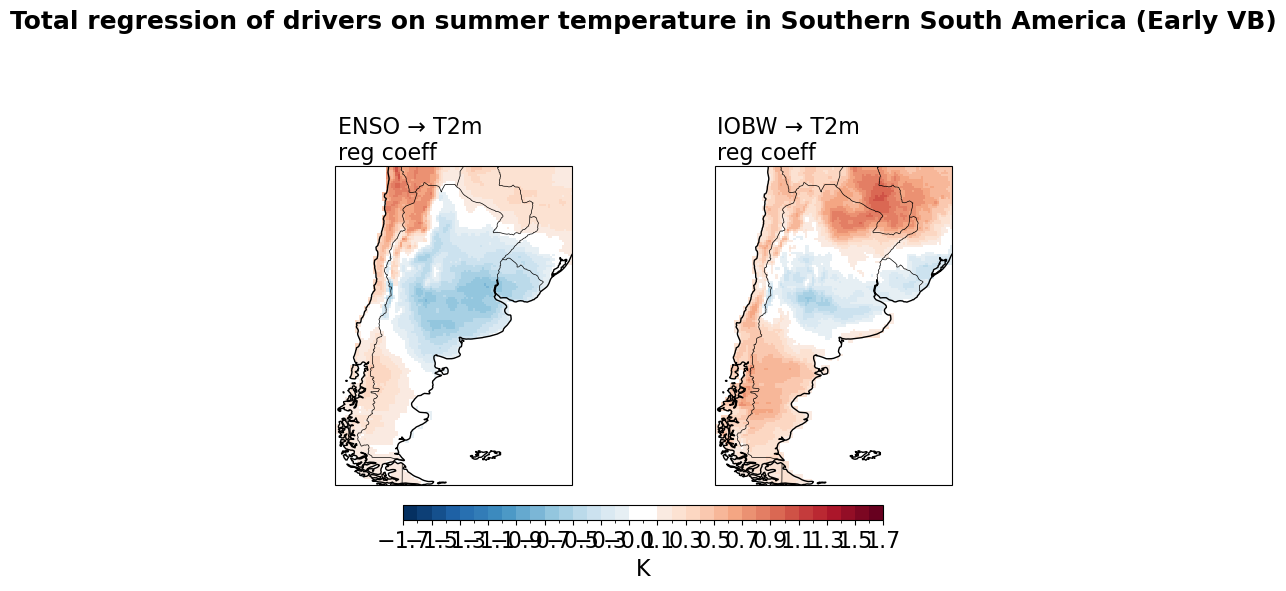

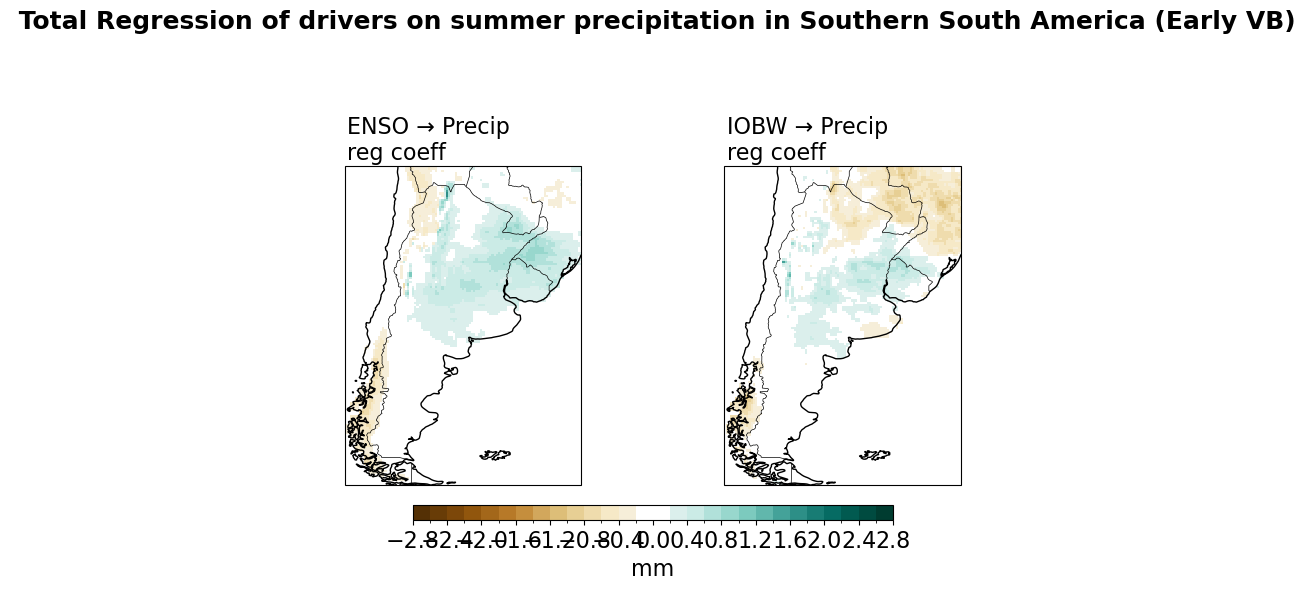

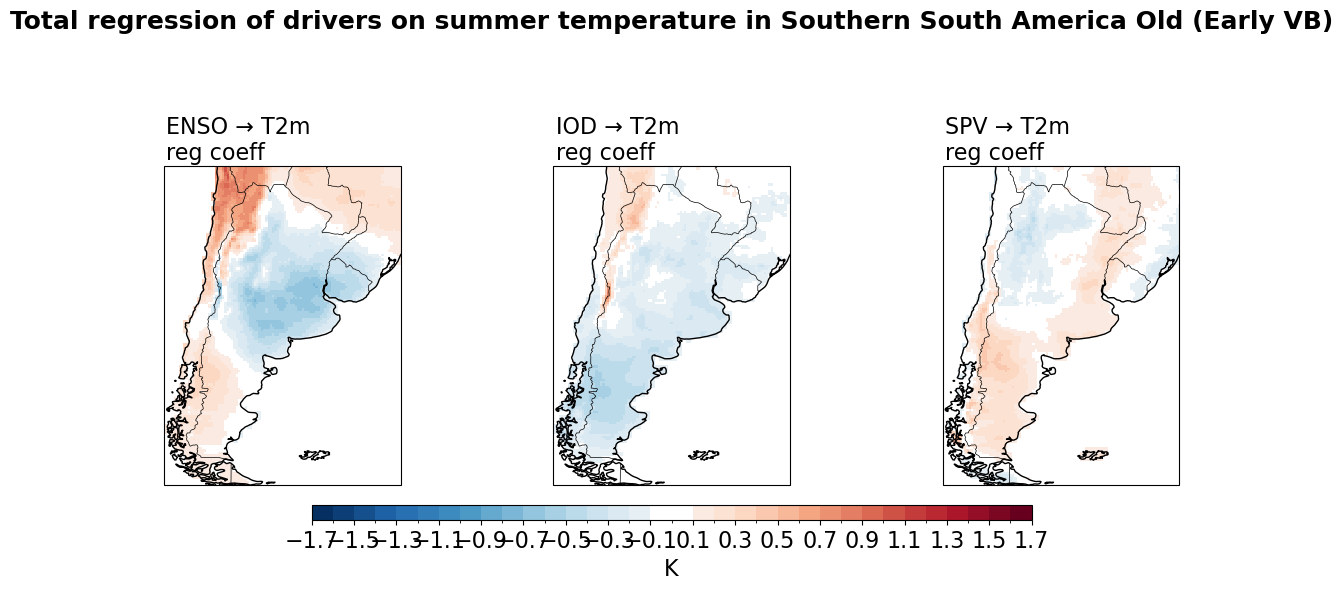

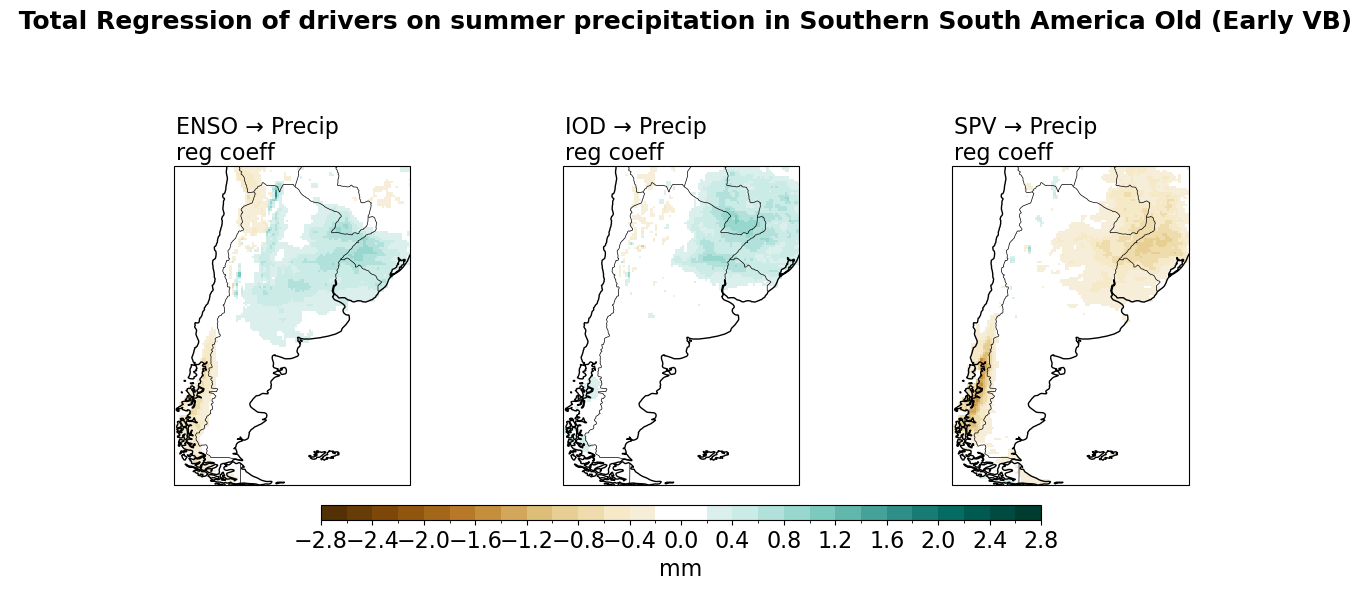

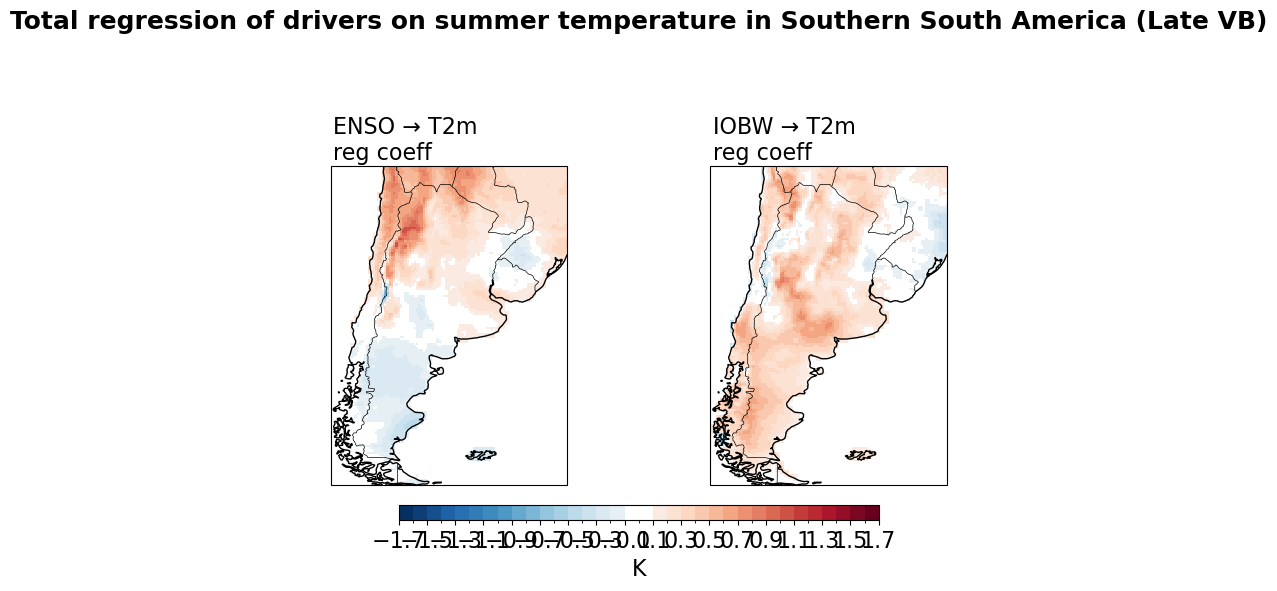

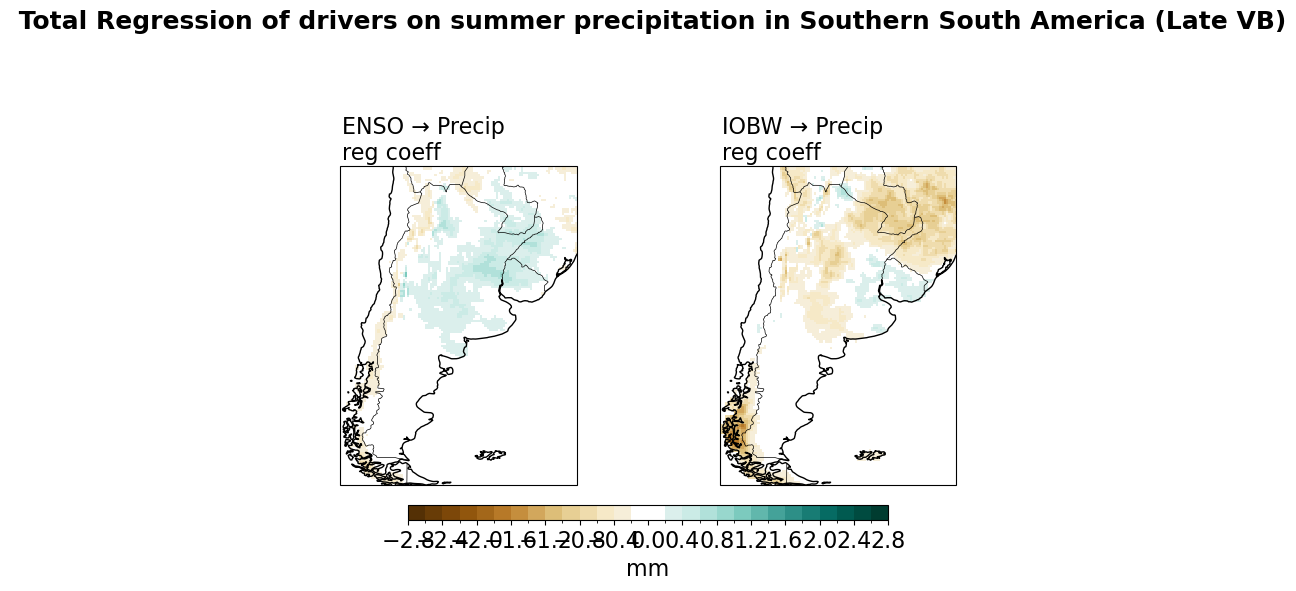

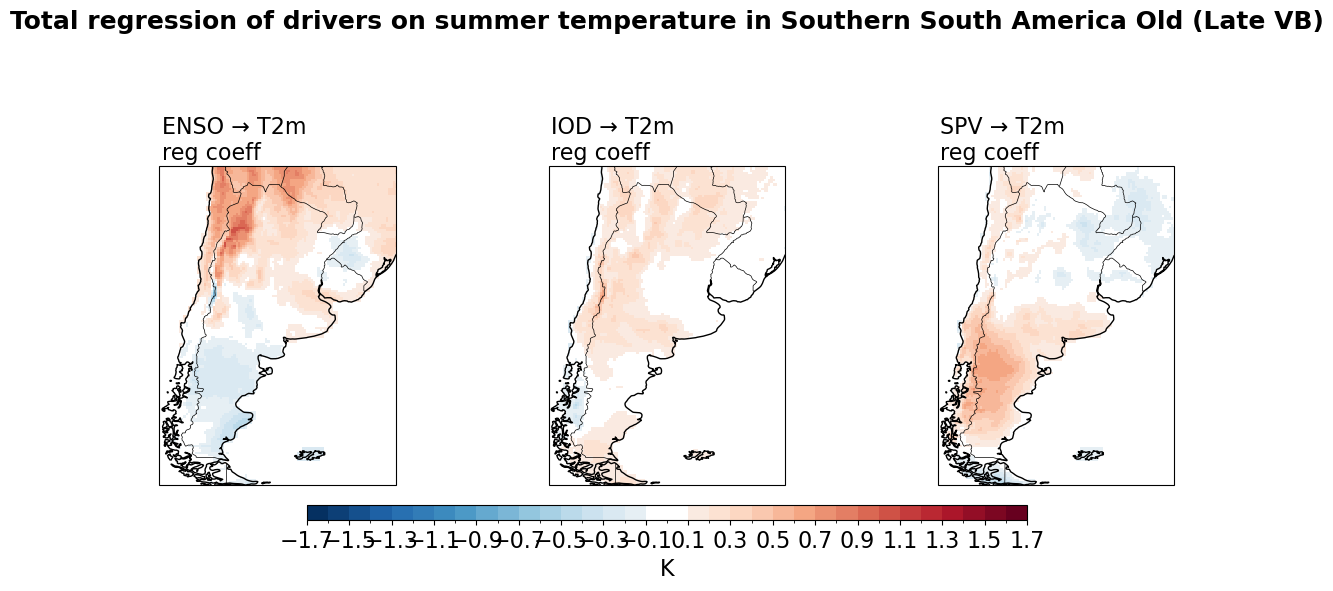

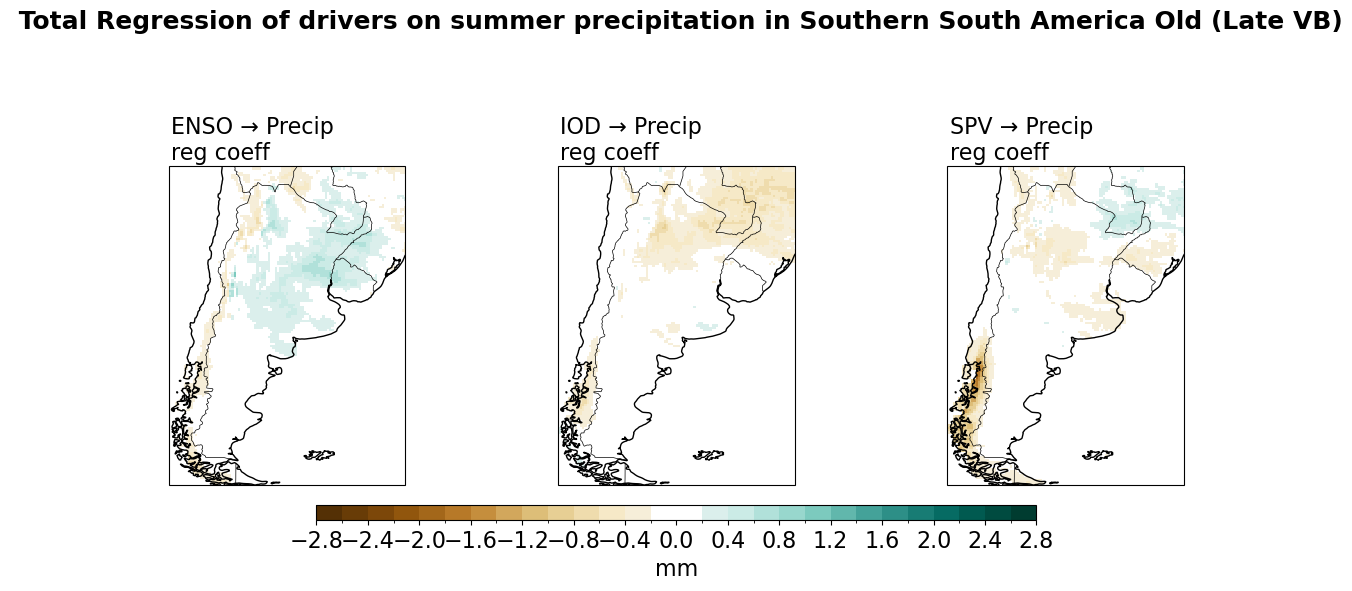

In [90]:
subplots_map(t_reg_LP_DJF_early_tot, [f"ENSO → T2m \nreg coeff", f"IOBW → T2m \nreg coeff" \
                      ], steps=.1,\
            heading='Total regression of drivers on summer temperature in Southern South America (Early VB)', global_max_val=global_max_t)
subplots_map(pr_reg_LP_DJF_early_tot, [f"ENSO → Precip \nreg coeff", f"IOBW → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG, steps=.2 ,heading=' Total Regression of drivers on summer precipitation in Southern South America (Early VB)', global_max_val=global_max_pr, unit='mm')
subplots_map(t_reg_LP_DJF_early_tot_old, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", f"SPV → T2m \nreg coeff", \
                      ], steps=.1,\
            heading='Total regression of drivers on summer temperature in Southern South America Old (Early VB)', global_max_val=global_max_t)
subplots_map(pr_reg_LP_DJF_early_tot_old, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", f"SPV → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG, steps=.2 ,heading=' Total Regression of drivers on summer precipitation in Southern South America Old (Early VB)', global_max_val=global_max_pr, unit='mm')

subplots_map(t_reg_LP_DJF_late_tot, [f"ENSO → T2m \nreg coeff", f"IOBW → T2m \nreg coeff" \
                      ], steps=.1,\
            heading='Total regression of drivers on summer temperature in Southern South America (Late VB)', global_max_val=global_max_t)
subplots_map(pr_reg_LP_DJF_late_tot, [f"ENSO → Precip \nreg coeff", f"IOBW → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG, steps=.2 ,heading=' Total Regression of drivers on summer precipitation in Southern South America (Late VB)', global_max_val=global_max_pr, unit='mm')
subplots_map(t_reg_LP_DJF_late_tot_old, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", f"SPV → T2m \nreg coeff", \
                      ], steps=.1,\
            heading='Total regression of drivers on summer temperature in Southern South America Old (Late VB)', global_max_val=global_max_t)
subplots_map(pr_reg_LP_DJF_late_tot_old, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", f"SPV → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG, steps=.2 ,heading=' Total Regression of drivers on summer precipitation in Southern South America Old (Late VB)', global_max_val=global_max_pr, unit='mm')